In [4]:
!git clone -b exp/original-project-20260305-143639 --single-branch https://github.com/codist-posist/econml.git
%cd /content/econml

Cloning into 'econml'...
remote: Enumerating objects: 1317, done.
remote: Counting objects: 100% (173/173), done.
remote: Compressing objects: 100% (46/46), done.
remote: Total 1317 (delta 153), reused 137 (delta 127), pack-reused 1144 (from 1)
Receiving objects: 100% (1317/1317), 774.68 KiB | 25.82 MiB/s, done.
Resolving deltas: 100% (1013/1013), done.
/content/econml


In [5]:
!pip -q install numpy pandas matplotlib tqdm nbformat nbclient jupyter

In [6]:
import torch
print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))

torch: 2.10.0+cu128
cuda available: True
gpu: NVIDIA L4


**TAYLOR**

In [7]:
# %% [code]
import os, sys, json
import numpy as np
import torch
import pathlib

def _find_project_root():
    here = pathlib.Path.cwd().resolve()
    for p in [here, *here.parents]:
        if (p / "src").is_dir():
            return p
    # Common Google Colab clone location
    cand = pathlib.Path("/content/econml")
    if (cand / "src").is_dir():
        return cand
    raise RuntimeError("Could not find project root containing src/. If on Colab, clone repo to /content/econml.")

PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import ModelParams, TrainConfig
from src.deqn import PolicyNetwork, Trainer, simulate_paths
from src.io_utils import make_run_dir, save_run_metadata, save_selected_run, pack_config, save_torch, save_csv, save_json, save_npz
from src.metrics import residual_quality

# ---------- config ----------
ARTIFACTS_ROOT = str(PROJECT_ROOT / "artifacts")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)
params = ModelParams(
    device=DEVICE,
    dtype=torch.float32,
)

cfg_seed = 151082
cfg_probe = TrainConfig.author_like_balanced_3reg(policy="taylor", seed=cfg_seed)
run_dir = make_run_dir(ARTIFACTS_ROOT, "taylor", tag=cfg_probe.mode, seed=cfg_probe.seed)
cfg = TrainConfig.author_like_balanced_3reg(policy="taylor", seed=cfg_seed, run_dir=run_dir, artifacts_root=ARTIFACTS_ROOT)

save_run_metadata(run_dir, pack_config(params, cfg, extra={"policy":"taylor"}))
print("Run dir:", run_dir)


Using device: cuda
Run dir: /content/econml/artifacts/runs/taylor/20260309_131741_author_seed151082_799c922b08


In [8]:
# %% [code]

from src.steady_states import solve_flexprice_sss, solve_taylor_sss
flex = solve_flexprice_sss(params)
taylor_sss = solve_taylor_sss(params, flex)
save_json(os.path.join(run_dir, "sss.json"), {"policy":"taylor","by_regime": taylor_sss.by_regime})

print("=== FLEX SSS (by regime) ===")
for _s in sorted(flex.by_regime.keys()):
    print(f"Regime {_s}:")
    for _k,_v in flex.by_regime[_s].items():
        print(f"{_k:>20}: {_v}")

print("=== TAYLOR SSS (by regime) ===")
for _s in sorted(taylor_sss.by_regime.keys()):
    print(f"Regime {_s}:")
    for _k,_v in taylor_sss.by_regime[_s].items():
        print(f"{_k:>20}: {_v}")


=== FLEX SSS (by regime) ===
Regime 0:
                   c: 0.9375810569817107
                   h: 1.1375810569817106
                   w: 0.9999999999999998
                 lam: 1.1375810569817109
                  pi: 0.0
               Delta: 1.0
               pstar: 1.0
              r_star: 9.93618116780226e-05
Regime 1:
                   c: 0.8877084501078355
                   h: 1.0877084501078356
                   w: 0.8571428571428571
                 lam: 1.2689931917924753
                  pi: 0.0
               Delta: 1.0
               pstar: 1.0
              r_star: 0.005802509011043622
Regime 2:
                   c: 0.8465472611349583
                   h: 1.0465472611349582
                   w: 0.75
                 lam: 1.395396348179944
                  pi: 0.0
               Delta: 1.0
               pstar: 1.0
              r_star: 0.004401757250452443
=== TAYLOR SSS (by regime) ===
Regime 0:
                  pi: -0.0024069038524823227
               

In [9]:
# %% [code]

# ---------- model ----------
d_in, d_out = 5, 4
net = PolicyNetwork(d_in, d_out, hidden=cfg.hidden_layers, activation=cfg.activation, init_mode=cfg.init_mode, init_scale=cfg.init_scale, seed=cfg.seed)

trainer = Trainer(
    params=params,
    cfg=cfg,
    policy="taylor",
    net=net,
    rbar_by_regime=None,
)


In [10]:
# %% [code]

# ---------- train ----------
losses = trainer.train(
    commitment_sss=None,
    n_path=cfg.n_path,
    n_paths_per_step=cfg.n_paths_per_step,
)

# save weights and log
save_torch(os.path.join(run_dir, "weights.pt"), trainer.net.state_dict())
import pandas as pd
df = pd.DataFrame({"iter": np.arange(len(losses)), "loss": losses})
save_csv(os.path.join(run_dir, "train_log.csv"), df)

# quality on a fresh validation batch sampled from the model's simulated state distribution
# Discretion residuals require autograd through Delta-derivative terms.
ctx = torch.enable_grad() if trainer.policy == "discretion" else torch.inference_mode()
with ctx:
    x_val = trainer.simulate_initial_state(int(cfg.val_size), commitment_sss=None)
    # optional short burn-in for validation states (kept small; training itself is path-based)
    val_burn = int(getattr(cfg, "val_burn_in", 200))
    for _ in range(val_burn):
        x_val = trainer._step_state(x_val)
    resid = trainer._residuals(x_val).detach().cpu().numpy()
q = residual_quality(resid, tol=getattr(cfg, "report_tol", 1e-3))
save_json(os.path.join(run_dir, "train_quality.json"), q)
print("Train quality:", q)

# ---------- simulate ergodic paths ----------
x0 = trainer.simulate_initial_state(512, commitment_sss=None)
sim = simulate_paths(
    params=params,
    policy=trainer.policy,
    net=trainer.net,
    T=20000,
    burn_in=2000,
    x0=x0,
    rbar_by_regime=None,
    compute_implied_i=False,
    gh_n=3,
    thin=1,
    store_states=True,
    show_progress=True,
)
save_npz(os.path.join(run_dir, "sim_paths.npz"), **sim)
print("Saved sim_paths to:", os.path.join(run_dir, "sim_paths.npz"))


taylor | train | phase1(gh=3,B=512) | torch.float32:   0%|          | 0/400000000 [00:00<?, ?it/s]

[taylor | phase1(gh=3,B=512)] step=     1 loss=4.282e+02  loss_resid=2.110e-01  loss_bounds=4.280e+02  rms=6.502e-01  max=1.132e+00  share(|res|<1e-4)=0.000
[taylor | phase1(gh=3,B=512)] step=   101 loss=1.273e+02  loss_resid=2.081e-01  loss_bounds=1.271e+02  rms=6.460e-01  max=1.284e+00  share(|res|<1e-4)=0.000
[taylor | phase1(gh=3,B=512)] step=   201 loss=1.263e+02  loss_resid=2.054e-01  loss_bounds=1.261e+02  rms=6.431e-01  max=1.755e+00  share(|res|<1e-4)=0.000
[taylor | phase1(gh=3,B=512)] step=   301 loss=1.250e+02  loss_resid=1.944e-01  loss_bounds=1.248e+02  rms=6.242e-01  max=1.315e+00  share(|res|<1e-4)=0.000
[taylor | phase1(gh=3,B=512)] step=   401 loss=1.231e+02  loss_resid=1.895e-01  loss_bounds=1.229e+02  rms=6.163e-01  max=1.283e+00  share(|res|<1e-4)=0.000
[taylor | phase1(gh=3,B=512)] step=   501 loss=1.207e+02  loss_resid=1.824e-01  loss_bounds=1.205e+02  rms=6.042e-01  max=1.215e+00  share(|res|<1e-4)=0.000
[taylor | phase1(gh=3,B=512)] step=   601 loss=1.173e+02  

simulate[taylor]:   0%|          | 0/20000 [00:00<?, ?it/s]

Saved sim_paths to: /content/econml/artifacts/runs/taylor/20260309_131741_author_seed151082_799c922b08/sim_paths.npz


In [11]:
# %% [code]
# ---------- Long-sim moments (our diagnostic object) ----------
from src.moment_reports import print_sim_paths_moments_report
sim_report = print_sim_paths_moments_report(
    run_dir=run_dir,
    device=DEVICE,
    dtype=params.dtype,
)


[sim_paths conditional by regime] (our long-sim diagnostic object)


,regime,n,pi_mean_pct,x_mean_author_pct,x_mean_paper_pct,i_mean_pct,r_mean_same_pct,r_mean_next_pct
0,normal,5262332,-0.598807,-6.556864,-0.108214,-0.195108,0.403699,NaN
1,bad,2615441,0.282920,-11.658587,-5.209680,1.568347,1.285426,NaN
2,severe,1338227,1.138940,-16.844792,-10.393541,3.280387,2.141447,NaN


In [12]:
# %% [code]
# ---------- Author NT/SS moments (table-comparison object) ----------
from src.moment_reports import build_and_print_author_nt_ss_report
author_report = build_and_print_author_nt_ss_report(
    run_dir=run_dir,
    policy=trainer.policy,
    artifacts_root=ARTIFACTS_ROOT,
    device=DEVICE,
    dtype=params.dtype,
    cons_mode="paper",
    rebuild_author_postprocess=False,
)


[author_postprocess by regime] (table-comparison object)


,regime,n,pi_mean_pct,x_mean_pct,i_mean_pct,r_mean_pct
0,normal,10000,-0.516869,-0.072960,-0.031232,0.485637
1,bad,10000,0.346446,-5.184146,1.695397,1.348952
2,severe,10000,1.069177,-10.362892,3.140860,2.071683


In [13]:
# %% [code]
# ---------- Sanity checks (fixed point + residuals) ----------
from src.sss_from_policy import switching_policy_sss_by_regime_from_policy
from src.sanity_checks import fixed_point_check, residuals_check_switching_consistent

SANITY_SSS_MAX_ITER = 2000
SANITY_SSS_TOL = 1e-8
SANITY_SSS_DAMPING = 0.7
SANITY_PROGRESS_EVERY = 100

tay_sss_pol = switching_policy_sss_by_regime_from_policy(
    params,
    trainer.net,
    policy='taylor',
    max_iter=SANITY_SSS_MAX_ITER,
    tol=SANITY_SSS_TOL,
    damping=SANITY_SSS_DAMPING,
    show_progress=True,
    progress_every=SANITY_PROGRESS_EVERY,
)
fp = fixed_point_check(
    params,
    trainer.net,
    policy='taylor',
    sss_by_regime=tay_sss_pol.by_regime,
    show_progress=True,
)
rc = residuals_check_switching_consistent(
    params,
    trainer.net,
    policy='taylor',
    sss_by_regime=tay_sss_pol.by_regime,
    show_progress=True,
)
print('Fixed point max |x_next-x| by regime:', {k:v.max_abs_state_diff for k,v in fp.items()})
print('Switching-consistent residual check max |res| by regime:', {k:v.max_abs_residual for k,v in rc.items()})



[sss:taylor] iter=1/2000 max_diff=8.607e-05 best=8.607e-05 elapsed=0.1s
[sss:taylor] iter=100/2000 max_diff=1.192e-07 best=1.192e-07 elapsed=6.7s
[sss:taylor] iter=200/2000 max_diff=1.192e-07 best=1.192e-07 elapsed=13.5s
[sss:taylor] iter=300/2000 max_diff=1.192e-07 best=1.192e-07 elapsed=20.2s
[sss:taylor] iter=400/2000 max_diff=1.192e-07 best=1.192e-07 elapsed=26.9s
[sss:taylor] iter=500/2000 max_diff=1.192e-07 best=1.192e-07 elapsed=33.6s
[sss:taylor] iter=600/2000 max_diff=1.192e-07 best=1.192e-07 elapsed=40.4s
[sss:taylor] iter=700/2000 max_diff=1.192e-07 best=1.192e-07 elapsed=47.1s
[sss:taylor] iter=800/2000 max_diff=1.192e-07 best=1.192e-07 elapsed=53.8s
[sss:taylor] iter=900/2000 max_diff=1.192e-07 best=1.192e-07 elapsed=60.5s
[sss:taylor] iter=1000/2000 max_diff=1.192e-07 best=1.192e-07 elapsed=67.2s
[sss:taylor] iter=1100/2000 max_diff=1.192e-07 best=1.192e-07 elapsed=73.9s
[sss:taylor] iter=1200/2000 max_diff=1.192e-07 best=1.192e-07 elapsed=80.5s
[sss:taylor] iter=1300/200

In [14]:
# %% [code]
# ---------- Save SSS from trained policy (paper-faithful) ----------
save_json(os.path.join(run_dir, 'sss_policy_fixed_point.json'), {
    'policy': 'taylor',
    'by_regime': tay_sss_pol.by_regime
})

In [15]:
# %% [code]
# ---------- Save sanity checks ----------
save_json(os.path.join(run_dir, 'sanity_checks.json'), {
    'policy': 'taylor',
    'fixed_point_max_abs_state_diff': {int(k): float(v.max_abs_state_diff) for k,v in fp.items()},
    'residual_max_abs': {int(k): float(v.max_abs_residual) for k,v in rc.items()},
    'residuals_by_regime': {int(k): {kk: float(vv) for kk,vv in v.residuals.items()} for k,v in rc.items()},
})

# Mark run as selected only after all core artifacts are saved.
save_selected_run(ARTIFACTS_ROOT, trainer.policy, run_dir)


'/content/econml/artifacts/selected_runs.json'

In [16]:
# %% [code]
# ---------- Compare two SSS objects for Taylor ----------
# 1) Table-like SSS: regime-conditional means from simulated paths
# 2) Policy fixed-point SSS (switching-consistent): tay_sss_pol.by_regime
import pandas as pd
from src.metrics import output_gap_from_consumption, efficient_c_hat_series_from_A_g
from src.steady_states import solve_efficient_sss
from src.policy_rules import i_taylor

sim_local = sim
s = np.asarray(sim_local['s']).reshape(-1).astype(np.int64)
pi = np.asarray(sim_local['pi']).reshape(-1)
i_nom = np.asarray(sim_local['i']).reshape(-1)
x_gap = np.asarray(output_gap_from_consumption(sim_local, solve_efficient_sss(params), params=params, time_varying=True)).reshape(-1)

# Real rate (author/table convention): r_t = i_t - pi_t
# Old ex-post alternative (not used): r = (1.0 + i_nom[:-1]) / (1.0 + pi[1:]) - 1.0
r = i_nom - pi
s_r = s

table_like = {}
reg_ids_sim = sorted(int(v) for v in np.unique(s))
for reg in reg_ids_sim:
    table_like[reg] = {
        'pi': float(np.mean(pi[s == reg])),
        'x': float(np.mean(x_gap[s == reg])),
        'i': float(np.mean(i_nom[s == reg])),
        'r': float(np.mean(r[s_r == reg])),
    }

fixed_point = {}
reg_ids_fp = sorted(int(k) for k in tay_sss_pol.by_regime.keys())
for reg in reg_ids_fp:
    b = tay_sss_pol.by_regime[int(reg)]
    A_ss = np.array([np.exp(float(b['logA']))], dtype=np.float64)
    g_ss = np.array([float(params.g_bar) * np.exp(float(b['loggtilde']))], dtype=np.float64)
    c_hat_ss = float(efficient_c_hat_series_from_A_g(params, A=A_ss, g=g_ss).reshape(-1)[0])
    pi_ss = float(b['pi'])
    x_ss = float(np.log(max(float(b['c']), 1e-12)) - np.log(max(c_hat_ss, 1e-12)))
    i_ss = float(i_taylor(params, torch.tensor(pi_ss, device=params.device, dtype=params.dtype)).detach().cpu())
    r_ss = (1.0 + i_ss) / (1.0 + pi_ss) - 1.0
    fixed_point[reg] = {'pi': pi_ss, 'x': x_ss, 'i': i_ss, 'r': r_ss}

reg_ids = sorted(set(reg_ids_sim) & set(reg_ids_fp))
rows = []
for reg in reg_ids:
    for obj_name, obj in [('table_like_from_sim', table_like), ('policy_fixed_point_switching', fixed_point)]:
        rows.append({
            'regime': reg,
            'object': obj_name,
            'pi_ann_pct': 400.0 * obj[reg]['pi'],
            'x_pct': 100.0 * obj[reg]['x'],
            'i_ann_pct': 400.0 * obj[reg]['i'],
            'r_ann_pct': 400.0 * obj[reg]['r'],
        })

cmp_df = pd.DataFrame(rows).sort_values(['regime', 'object']).reset_index(drop=True)
display(cmp_df)

# Absolute differences (table-like minus fixed-point), annualized units
diff_rows = []
for reg in reg_ids:
    diff_rows.append({
        'regime': reg,
        'd_pi_ann_pct': 400.0 * (table_like[reg]['pi'] - fixed_point[reg]['pi']),
        'd_x_pct': 100.0 * (table_like[reg]['x'] - fixed_point[reg]['x']),
        'd_i_ann_pct': 400.0 * (table_like[reg]['i'] - fixed_point[reg]['i']),
        'd_r_ann_pct': 400.0 * (table_like[reg]['r'] - fixed_point[reg]['r']),
    })
display(pd.DataFrame(diff_rows))

print('Fixed point max |x_next-x| by regime:', {k:v.max_abs_state_diff for k,v in fp.items()})
print('Switching-consistent residual check max |res| by regime:', {k:v.max_abs_residual for k,v in rc.items()})


,regime,object,pi_ann_pct,x_pct,i_ann_pct,r_ann_pct
0,0,policy_fixed_point_switching,-0.574565,-0.125168,-0.146624,0.428557
1,0,table_like_from_sim,-0.598807,-0.108214,-0.195108,0.403699
2,1,policy_fixed_point_switching,0.299788,-5.205085,1.602081,1.301318
3,1,table_like_from_sim,0.282920,-5.209680,1.568347,1.285426
4,2,policy_fixed_point_switching,1.142359,-10.324881,3.287224,2.138757
5,2,table_like_from_sim,1.138940,-10.393541,3.280387,2.141447


,regime,d_pi_ann_pct,d_x_pct,d_i_ann_pct,d_r_ann_pct
0,0,-0.024242,0.016954,-0.048484,-0.024858
1,1,-0.016867,-0.004595,-0.033734,-0.015892
2,2,-0.003418,-0.068660,-0.006837,0.002690


Fixed point max |x_next-x| by regime: {0: 8.344650268554688e-07, 1: 4.887580871582031e-06, 2: 6.4373016357421875e-06}
Switching-consistent residual check max |res| by regime: {0: 0.0007187128067016602, 1: 0.0020025968551635742, 2: 0.0012753563933074474}


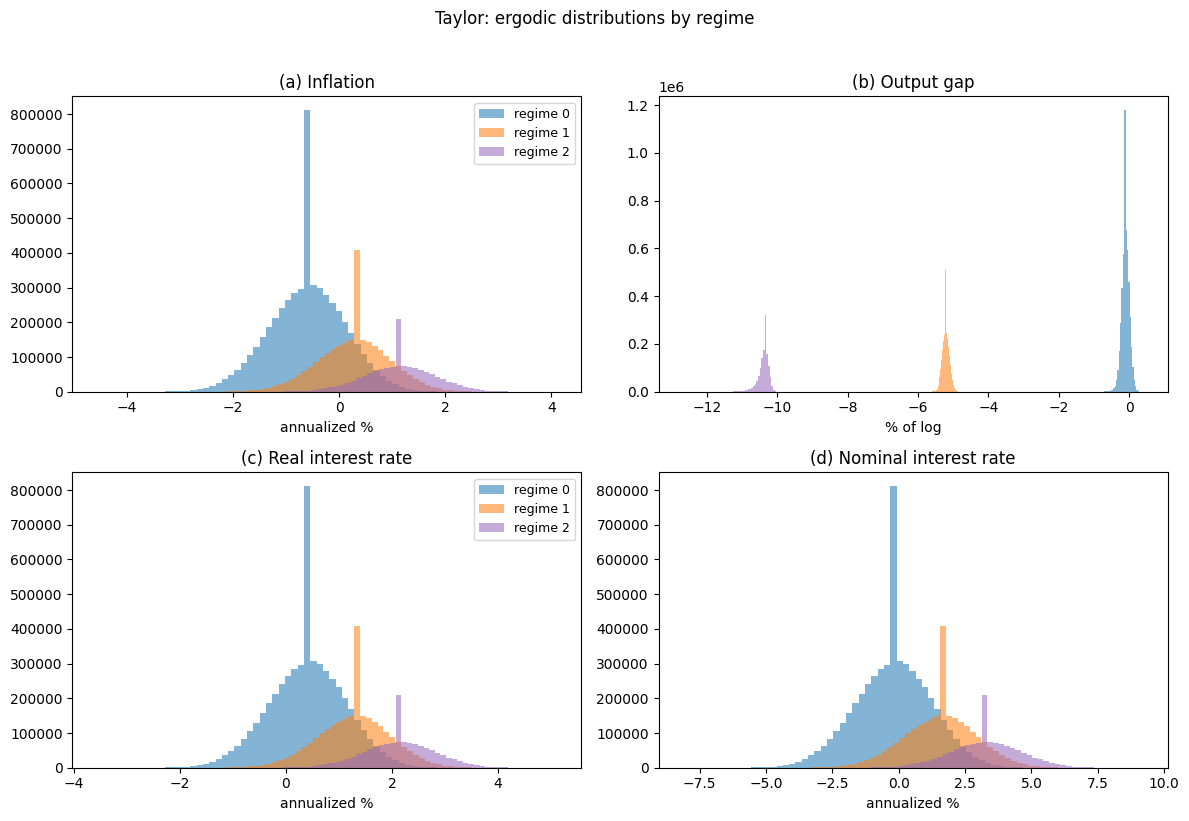

Saved: /content/econml/artifacts/runs/taylor/20260309_131741_author_seed151082_799c922b08/figure_taylor_ergodic_by_regime.png


In [17]:
# %% [code]
# ---------- One Taylor figure (regime-split ergodic distributions) ----------
import matplotlib.pyplot as plt

def _ann(x):
    return 400.0 * np.asarray(x)

fig, ax = plt.subplots(2, 2, figsize=(12, 8))
reg_ids_s = sorted(int(v) for v in np.unique(s))
reg_ids_r = sorted(int(v) for v in np.unique(s_r))
cols = ['tab:blue', 'tab:orange', 'tab:purple', 'tab:brown', 'tab:gray']

for j, reg in enumerate(reg_ids_s):
    m = s == int(reg)
    if not np.any(m):
        continue
    lbl = f'regime {reg}'
    ax[0, 0].hist(_ann(pi)[m], bins=60, alpha=0.55, label=lbl, color=cols[j % len(cols)])
    ax[0, 1].hist(100.0 * x_gap[m], bins=60, alpha=0.55, color=cols[j % len(cols)])
    ax[1, 1].hist(_ann(i_nom)[m], bins=60, alpha=0.55, color=cols[j % len(cols)])

for j, reg in enumerate(reg_ids_r):
    m = s_r == int(reg)
    if not np.any(m):
        continue
    ax[1, 0].hist(_ann(r)[m], bins=60, alpha=0.55, color=cols[j % len(cols)], label=f'regime {reg}')

ax[0, 0].set_title('(a) Inflation')
ax[0, 0].set_xlabel('annualized %')
ax[0, 0].legend(fontsize=9)
ax[0, 1].set_title('(b) Output gap')
ax[0, 1].set_xlabel('% of log')
ax[1, 0].set_title('(c) Real interest rate')
ax[1, 0].set_xlabel('annualized %')
ax[1, 0].legend(fontsize=9)
ax[1, 1].set_title('(d) Nominal interest rate')
ax[1, 1].set_xlabel('annualized %')

fig.suptitle('Taylor: ergodic distributions by regime', y=1.02)
plt.tight_layout()
out_fig = os.path.join(run_dir, 'figure_taylor_ergodic_by_regime.png')
plt.savefig(out_fig, dpi=160, bbox_inches='tight')
plt.show()
print('Saved:', out_fig)


**MOD TAYLOR**

In [18]:
# %% [code]
import os, sys, json
import numpy as np
import torch
import pathlib

def _find_project_root():
    here = pathlib.Path.cwd().resolve()
    for p in [here, *here.parents]:
        if (p / "src").is_dir():
            return p
    cand = pathlib.Path("/content/econml")
    if (cand / "src").is_dir():
        return cand
    raise RuntimeError("Could not find project root containing src/. If on Colab, clone repo to /content/econml.")

PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import ModelParams, TrainConfig
from src.deqn import PolicyNetwork, Trainer, simulate_paths
from src.io_utils import make_run_dir, save_run_metadata, save_selected_run, pack_config, save_torch, save_csv, save_json, save_npz
from src.metrics import residual_quality
from src.steady_states import solve_flexprice_sss, export_rbar_tensor

ARTIFACTS_ROOT = str(PROJECT_ROOT / "artifacts")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)
params = ModelParams(
    device=DEVICE,
    dtype=torch.float32,
)

cfg_seed = 151082
cfg_probe = TrainConfig.author_like_balanced_3reg(policy="mod_taylor", seed=cfg_seed)
run_dir = make_run_dir(ARTIFACTS_ROOT, "mod_taylor", tag=cfg_probe.mode, seed=cfg_probe.seed)
cfg = TrainConfig.author_like_balanced_3reg(policy="mod_taylor", seed=cfg_seed, run_dir=run_dir, artifacts_root=ARTIFACTS_ROOT)

flex = solve_flexprice_sss(params)
rbar_by_regime = export_rbar_tensor(params, flex)

save_run_metadata(run_dir, pack_config(params, cfg, extra={"policy":"mod_taylor"}))
print("Run dir:", run_dir)

Using device: cuda
Run dir: /content/econml/artifacts/runs/mod_taylor/20260309_135611_author_seed151082_899ff83b78


In [19]:
# %% [code]
# ---------- model ----------
d_in, d_out = 5, 4
net = PolicyNetwork(d_in, d_out, hidden=cfg.hidden_layers, activation=cfg.activation, init_mode=cfg.init_mode, init_scale=cfg.init_scale, seed=cfg.seed)

trainer = Trainer(
    params=params,
    cfg=cfg,
    policy="mod_taylor",
    net=net,
    rbar_by_regime=rbar_by_regime,
)


In [20]:
# %% [code]
# ---------- train ----------
losses = trainer.train(
    commitment_sss=None,
    n_path=cfg.n_path,
    n_paths_per_step=cfg.n_paths_per_step,
)

save_torch(os.path.join(run_dir, "weights.pt"), trainer.net.state_dict())
import pandas as pd
df = pd.DataFrame({"iter": np.arange(len(losses)), "loss": losses})
save_csv(os.path.join(run_dir, "train_log.csv"), df)

ctx = torch.enable_grad() if trainer.policy in ("discretion", "discretion_zlb") else torch.inference_mode()
with ctx:
    x_val = trainer.simulate_initial_state(int(cfg.val_size), commitment_sss=None)
    val_burn = int(getattr(cfg, "val_burn_in", 200))
    for _ in range(val_burn):
        x_val = trainer._step_state(x_val)
    resid = trainer._residuals(x_val).detach().cpu().numpy()
q = residual_quality(resid, tol=getattr(cfg, "report_tol", 1e-3))
save_json(os.path.join(run_dir, "train_quality.json"), q)
print("Train quality:", q)

x0 = trainer.simulate_initial_state(512, commitment_sss=None)
sim = simulate_paths(
    params=params,
    policy=trainer.policy,
    net=trainer.net,
    T=20000,
    burn_in=2000,
    x0=x0,
    rbar_by_regime=rbar_by_regime,
    compute_implied_i=False,
    gh_n=3,
    thin=1,
    store_states=True,
    show_progress=True,
)
save_npz(os.path.join(run_dir, "sim_paths.npz"), **sim)
print("Saved sim_paths to:", os.path.join(run_dir, "sim_paths.npz"))



mod_taylor | train | phase1(gh=3,B=512) | torch.float32:   0%|          | 0/400000000 [00:00<?, ?it/s]

[mod_taylor | phase1(gh=3,B=512)] step=     1 loss=4.282e+02  loss_resid=2.110e-01  loss_bounds=4.280e+02  rms=6.502e-01  max=1.132e+00  share(|res|<1e-4)=0.000
[mod_taylor | phase1(gh=3,B=512)] step=   101 loss=1.273e+02  loss_resid=2.081e-01  loss_bounds=1.271e+02  rms=6.460e-01  max=1.284e+00  share(|res|<1e-4)=0.000
[mod_taylor | phase1(gh=3,B=512)] step=   201 loss=1.263e+02  loss_resid=2.054e-01  loss_bounds=1.261e+02  rms=6.431e-01  max=1.755e+00  share(|res|<1e-4)=0.000
[mod_taylor | phase1(gh=3,B=512)] step=   301 loss=1.250e+02  loss_resid=1.944e-01  loss_bounds=1.248e+02  rms=6.242e-01  max=1.315e+00  share(|res|<1e-4)=0.000
[mod_taylor | phase1(gh=3,B=512)] step=   401 loss=1.231e+02  loss_resid=1.895e-01  loss_bounds=1.229e+02  rms=6.163e-01  max=1.283e+00  share(|res|<1e-4)=0.000
[mod_taylor | phase1(gh=3,B=512)] step=   501 loss=1.207e+02  loss_resid=1.824e-01  loss_bounds=1.205e+02  rms=6.042e-01  max=1.215e+00  share(|res|<1e-4)=0.000
[mod_taylor | phase1(gh=3,B=512)] 

simulate[mod_taylor]:   0%|          | 0/20000 [00:00<?, ?it/s]

Saved sim_paths to: /content/econml/artifacts/runs/mod_taylor/20260309_135611_author_seed151082_899ff83b78/sim_paths.npz


In [21]:
# %% [code]
# ---------- Long-sim moments (our diagnostic object) ----------
from src.moment_reports import print_sim_paths_moments_report
sim_report = print_sim_paths_moments_report(
    run_dir=run_dir,
    device=DEVICE,
    dtype=params.dtype,
)


[sim_paths conditional by regime] (our long-sim diagnostic object)


,regime,n,pi_mean_pct,x_mean_author_pct,x_mean_paper_pct,i_mean_pct,r_mean_same_pct,r_mean_next_pct
0,normal,5262332,-0.045470,-6.449226,-0.000576,-0.051196,-0.005725,NaN
1,bad,2615441,0.003460,-11.911140,-5.462233,2.327924,2.324464,NaN
2,severe,1338227,-0.076112,-16.673787,-10.222536,1.608479,1.684591,NaN


In [22]:
# %% [code]
# ---------- Author NT/SS moments (table-comparison object) ----------
from src.moment_reports import build_and_print_author_nt_ss_report
author_report = build_and_print_author_nt_ss_report(
    run_dir=run_dir,
    policy=trainer.policy,
    artifacts_root=ARTIFACTS_ROOT,
    device=DEVICE,
    dtype=params.dtype,
    cons_mode="paper",
    rebuild_author_postprocess=False,
)


[author_postprocess by regime] (table-comparison object)


,regime,n,pi_mean_pct,x_mean_pct,i_mean_pct,r_mean_pct
0,normal,10000,0.019966,-0.012764,0.079848,0.059882
1,bad,10000,0.062441,-5.469594,2.445830,2.383389
2,severe,10000,-0.100014,-10.239106,1.560676,1.660689


In [23]:
# %% [code]
# ---------- Sanity checks ----------
from src.sss_from_policy import switching_policy_sss_by_regime_from_policy
from src.sanity_checks import fixed_point_check, residuals_check_switching_consistent

SANITY_SSS_MAX_ITER = 2000
SANITY_SSS_TOL = 1e-8
SANITY_SSS_DAMPING = 0.7
SANITY_PROGRESS_EVERY = 100

sss_pol = switching_policy_sss_by_regime_from_policy(
    params,
    trainer.net,
    policy="mod_taylor",
    rbar_by_regime=rbar_by_regime,
    max_iter=SANITY_SSS_MAX_ITER,
    tol=SANITY_SSS_TOL,
    damping=SANITY_SSS_DAMPING,
    show_progress=True,
    progress_every=SANITY_PROGRESS_EVERY,
)
fp = fixed_point_check(
    params,
    trainer.net,
    policy="mod_taylor",
    sss_by_regime=sss_pol.by_regime,
    rbar_by_regime=rbar_by_regime,
    show_progress=True,
)
rc = residuals_check_switching_consistent(
    params,
    trainer.net,
    policy="mod_taylor",
    sss_by_regime=sss_pol.by_regime,
    rbar_by_regime=rbar_by_regime,
    show_progress=True,
)
print('Fixed point max |x_next-x| by regime:', {k:v.max_abs_state_diff for k,v in fp.items()})
print('Switching-consistent residual check max |res| by regime:', {k:v.max_abs_residual for k,v in rc.items()})

save_json(os.path.join(run_dir, 'sss_policy_fixed_point.json'), {'policy':'mod_taylor','by_regime': sss_pol.by_regime})
save_json(os.path.join(run_dir, 'sanity_checks.json'), {
    'policy': 'mod_taylor',
    'fixed_point_max_abs_state_diff': {int(k): float(v.max_abs_state_diff) for k,v in fp.items()},
    'residual_max_abs': {int(k): float(v.max_abs_residual) for k,v in rc.items()},
    'residuals_by_regime': {int(k): {kk: float(vv) for kk,vv in v.residuals.items()} for k,v in rc.items()},
})

save_selected_run(ARTIFACTS_ROOT, trainer.policy, run_dir)
print('Selected run saved for mod_taylor:', run_dir)


[sss:mod_taylor] iter=1/2000 max_diff=3.576e-07 best=3.576e-07 elapsed=0.1s
[sss:mod_taylor] iter=100/2000 max_diff=1.192e-07 best=1.192e-07 elapsed=6.7s
[sss:mod_taylor] iter=200/2000 max_diff=1.192e-07 best=1.192e-07 elapsed=13.4s
[sss:mod_taylor] iter=300/2000 max_diff=1.192e-07 best=1.192e-07 elapsed=20.1s
[sss:mod_taylor] iter=400/2000 max_diff=1.192e-07 best=1.192e-07 elapsed=26.7s
[sss:mod_taylor] iter=500/2000 max_diff=1.192e-07 best=1.192e-07 elapsed=33.5s
[sss:mod_taylor] iter=600/2000 max_diff=1.192e-07 best=1.192e-07 elapsed=40.2s
[sss:mod_taylor] iter=700/2000 max_diff=1.192e-07 best=1.192e-07 elapsed=46.9s
[sss:mod_taylor] iter=800/2000 max_diff=1.192e-07 best=1.192e-07 elapsed=53.6s
[sss:mod_taylor] iter=900/2000 max_diff=1.192e-07 best=1.192e-07 elapsed=60.3s
[sss:mod_taylor] iter=1000/2000 max_diff=1.192e-07 best=1.192e-07 elapsed=67.0s
[sss:mod_taylor] iter=1100/2000 max_diff=1.192e-07 best=1.192e-07 elapsed=73.7s
[sss:mod_taylor] iter=1200/2000 max_diff=1.192e-07 bes

**DISCTRETION**

In [24]:
# %% [code]
import os, sys, json
import numpy as np
import torch
import pathlib

def _find_project_root():
    here = pathlib.Path.cwd().resolve()
    for p in [here, *here.parents]:
        if (p / "src").is_dir():
            return p
    # Common Google Colab clone location
    cand = pathlib.Path("/content/econml")
    if (cand / "src").is_dir():
        return cand
    raise RuntimeError("Could not find project root containing src/. If on Colab, clone repo to /content/econml.")

PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import ModelParams, TrainConfig
from src.deqn import PolicyNetwork, Trainer, simulate_paths
from src.io_utils import make_run_dir, save_run_metadata, save_selected_run, pack_config, save_torch, save_csv, save_json, save_npz
from src.metrics import residual_quality

# ---------- config ----------
ARTIFACTS_ROOT = str(PROJECT_ROOT / "artifacts")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)
params = ModelParams(
    device=DEVICE,
    dtype=torch.float32,
)

cfg_seed = 151082
cfg_probe = TrainConfig.author_like_balanced_3reg(policy="discretion", seed=cfg_seed)
run_dir = make_run_dir(ARTIFACTS_ROOT, "discretion", tag=cfg_probe.mode, seed=cfg_probe.seed)
cfg = TrainConfig.author_like_balanced_3reg(policy="discretion", seed=cfg_seed, run_dir=run_dir, artifacts_root=ARTIFACTS_ROOT)

save_run_metadata(run_dir, pack_config(params, cfg, extra={"policy":"discretion"}))
print("Run dir:", run_dir)



Using device: cuda
Run dir: /content/econml/artifacts/runs/discretion/20260309_145419_author_seed151082_3af7f65cd9


In [25]:
# %% [code]

# ---------- model ----------
d_in, d_out = 5, 5
net = PolicyNetwork(d_in, d_out, hidden=cfg.hidden_layers, activation=cfg.activation, init_mode=cfg.init_mode, init_scale=cfg.init_scale, seed=cfg.seed)

trainer = Trainer(
    params=params,
    cfg=cfg,
    policy="discretion",
    net=net,
    rbar_by_regime=None,
)

In [26]:
# %% [code]

# ---------- train ----------
losses = trainer.train(
    commitment_sss=None,
    n_path=cfg.n_path,
    n_paths_per_step=cfg.n_paths_per_step,
)

# save weights and log
save_torch(os.path.join(run_dir, "weights.pt"), trainer.net.state_dict())
import pandas as pd
df = pd.DataFrame({"iter": np.arange(len(losses)), "loss": losses})
save_csv(os.path.join(run_dir, "train_log.csv"), df)

# quality on a fresh validation batch sampled from the model's simulated state distribution
# Discretion residuals require autograd through Delta-derivative terms.
ctx = torch.enable_grad() if trainer.policy == "discretion" else torch.inference_mode()
with ctx:
    x_val = trainer.simulate_initial_state(int(cfg.val_size), commitment_sss=None)
    # optional short burn-in for validation states (kept small; training itself is path-based)
    val_burn = int(getattr(cfg, "val_burn_in", 200))
    for _ in range(val_burn):
        x_val = trainer._step_state(x_val)
    resid = trainer._residuals(x_val).detach().cpu().numpy()
q = residual_quality(resid, tol=getattr(cfg, "report_tol", 1e-3))
save_json(os.path.join(run_dir, "train_quality.json"), q)
print("Train quality:", q)

# ---------- simulate ergodic paths ----------
x0 = trainer.simulate_initial_state(512, commitment_sss=None)
sim = simulate_paths(
    params=params,
    policy=trainer.policy,
    net=trainer.net,
    T=20000,
    burn_in=2000,
    x0=x0,
    rbar_by_regime=None,
    compute_implied_i=True,
    gh_n=3,
    thin=1,
    store_states=True,
    show_progress=True,
)
save_npz(os.path.join(run_dir, "sim_paths.npz"), **sim)
print("Saved sim_paths to:", os.path.join(run_dir, "sim_paths.npz"))


discretion | train | phase1(gh=3,B=1024) | torch.float32:   0%|          | 0/800000000 [00:00<?, ?it/s]

[discretion | phase1(gh=3,B=1024)] step=     1 loss=8.702e-01  loss_resid=5.844e-01  loss_bounds=2.858e-01  rms=1.165e+00  max=2.161e+00  share(|res|<1e-4)=0.000
[discretion | phase1(gh=3,B=1024)] step=   101 loss=5.951e-01  loss_resid=5.509e-01  loss_bounds=4.419e-02  rms=1.116e+00  max=2.134e+00  share(|res|<1e-4)=0.000
[discretion | phase1(gh=3,B=1024)] step=   201 loss=4.563e-01  loss_resid=4.562e-01  loss_bounds=1.172e-04  rms=9.815e-01  max=1.657e+00  share(|res|<1e-4)=0.000
[discretion | phase1(gh=3,B=1024)] step=   301 loss=3.386e-01  loss_resid=3.386e-01  loss_bounds=0.000e+00  rms=8.271e-01  max=1.250e+00  share(|res|<1e-4)=0.000
[discretion | phase1(gh=3,B=1024)] step=   401 loss=2.898e-01  loss_resid=2.898e-01  loss_bounds=0.000e+00  rms=7.630e-01  max=1.445e+00  share(|res|<1e-4)=0.000
[discretion | phase1(gh=3,B=1024)] step=   501 loss=2.702e-01  loss_resid=2.702e-01  loss_bounds=0.000e+00  rms=7.357e-01  max=1.391e+00  share(|res|<1e-4)=0.000
[discretion | phase1(gh=3,B=

simulate[discretion]:   0%|          | 0/20000 [00:00<?, ?it/s]

Saved sim_paths to: /content/econml/artifacts/runs/discretion/20260309_145419_author_seed151082_3af7f65cd9/sim_paths.npz


In [27]:
# %% [code]
# ---------- Long-sim moments (our diagnostic object) ----------
from src.moment_reports import print_sim_paths_moments_report
sim_report = print_sim_paths_moments_report(
    run_dir=run_dir,
    device=DEVICE,
    dtype=params.dtype,
)


[sim_paths conditional by regime] (our long-sim diagnostic object)


,regime,n,pi_mean_pct,x_mean_author_pct,x_mean_paper_pct,i_mean_pct,r_mean_same_pct,r_mean_next_pct
0,normal,5262332,0.646997,-7.697579,-1.247928,1.180053,0.533056,NaN
1,bad,2615441,1.897407,-10.525541,-4.075353,3.526346,1.628939,NaN
2,severe,1338227,2.982625,-13.403879,-6.951411,4.422988,1.440363,NaN


In [28]:
# %% [code]
# ---------- Author NT/SS moments (table-comparison object) ----------
from src.moment_reports import build_and_print_author_nt_ss_report
author_report = build_and_print_author_nt_ss_report(
    run_dir=run_dir,
    policy=trainer.policy,
    artifacts_root=ARTIFACTS_ROOT,
    device=DEVICE,
    dtype=params.dtype,
    cons_mode="paper",
    rebuild_author_postprocess=False,
)



[author_postprocess by regime] (table-comparison object)


,regime,n,pi_mean_pct,x_mean_pct,i_mean_pct,r_mean_pct
0,normal,10000,0.292791,-0.616998,0.720035,0.427244
1,bad,10000,2.017165,-4.356886,3.901013,1.883848
2,severe,10000,3.460728,-8.016406,4.969310,1.508582


In [29]:
# %% [code]
# ---------- SSS from trained policy (paper-faithful) ----------
from src.steady_states import solve_discretion_sss_from_policy_switching

SANITY_SSS_MAX_ITER = 2000
SANITY_SSS_TOL = 1e-8
SANITY_SSS_DAMPING = 0.7
SANITY_PROGRESS_EVERY = 100

disc_sss = solve_discretion_sss_from_policy_switching(
    params,
    trainer.net,
    max_iter=SANITY_SSS_MAX_ITER,
    tol=SANITY_SSS_TOL,
    damping=SANITY_SSS_DAMPING,
    show_progress=True,
    progress_every=SANITY_PROGRESS_EVERY,
)
save_json(os.path.join(run_dir, 'sss_policy_fixed_point.json'), {'policy':'discretion','by_regime': disc_sss.by_regime})
print('=== DISCRETION SSS (policy fixed point (switching-consistent), by regime) ===')
for _s in sorted(disc_sss.by_regime.keys()):
    print(f'Regime {_s}:')
    for _k,_v in disc_sss.by_regime[_s].items():
        print(f'{_k:>20}: {_v}')


[sss:discretion] iter=1/2000 max_diff=6.181e-04 best=6.181e-04 elapsed=0.1s
[sss:discretion] iter=100/2000 max_diff=1.192e-07 best=1.192e-07 elapsed=6.9s
[sss:discretion] iter=200/2000 max_diff=1.192e-07 best=1.192e-07 elapsed=13.7s
[sss:discretion] iter=300/2000 max_diff=1.192e-07 best=1.192e-07 elapsed=20.6s
[sss:discretion] iter=400/2000 max_diff=1.192e-07 best=1.192e-07 elapsed=27.4s
[sss:discretion] iter=500/2000 max_diff=1.192e-07 best=1.192e-07 elapsed=34.3s
[sss:discretion] iter=600/2000 max_diff=1.192e-07 best=1.192e-07 elapsed=41.1s
[sss:discretion] iter=700/2000 max_diff=1.192e-07 best=1.192e-07 elapsed=48.0s
[sss:discretion] iter=800/2000 max_diff=1.192e-07 best=1.192e-07 elapsed=54.8s
[sss:discretion] iter=900/2000 max_diff=1.192e-07 best=1.192e-07 elapsed=61.6s
[sss:discretion] iter=1000/2000 max_diff=1.192e-07 best=1.192e-07 elapsed=68.5s
[sss:discretion] iter=1100/2000 max_diff=1.192e-07 best=1.192e-07 elapsed=75.2s
[sss:discretion] iter=1200/2000 max_diff=1.192e-07 bes

In [30]:
# %% [code]
# ---------- Sanity checks (fixed-regime mapping + switching-consistent residuals) ----------
from src.sanity_checks import fixed_point_check, residuals_check_switching_consistent
fp = fixed_point_check(
    params,
    trainer.net,
    policy='discretion',
    sss_by_regime=disc_sss.by_regime,
    show_progress=True,
)
rc = residuals_check_switching_consistent(
    params,
    trainer.net,
    policy='discretion',
    sss_by_regime=disc_sss.by_regime,
    show_progress=True,
)
print('Fixed-regime one-step check max |x_next-x| by regime (NOT Table-2 SSS):', {k:v.max_abs_state_diff for k,v in fp.items()})
print('Switching-consistent residual check max |res| by regime:', {k:v.max_abs_residual for k,v in rc.items()})
print('Residual keys:', list(next(iter(rc.values())).residuals.keys()))


[sanity:discretion] fixed_point regime=0 (1/3)
[sanity:discretion] fixed_point regime=1 (2/3)
[sanity:discretion] fixed_point regime=2 (3/3)
[sanity:discretion] residuals regime=0 (1/3)
[sanity:discretion] residuals regime=1 (2/3)
[sanity:discretion] residuals regime=2 (3/3)
Fixed-regime one-step check max |x_next-x| by regime (NOT Table-2 SSS): {0: 1.823902130126953e-05, 1: 1.7762184143066406e-05, 2: 3.743171691894531e-05}
Switching-consistent residual check max |res| by regime: {0: 0.004968464840203524, 1: 0.006211031693965197, 2: 0.010919936001300812}
Residual keys: ['res_c_foc', 'res_Delta_foc', 'res_XiN_rec', 'res_XiD_rec', 'res_pstar_def']


In [31]:
# %% [code]
# ---------- Save sanity checks ----------
save_json(os.path.join(run_dir, 'sanity_checks.json'), {
    'policy': 'discretion',
    'fixed_regime_one_step_max_abs_state_diff': {int(k): float(v.max_abs_state_diff) for k,v in fp.items()},
    'residual_max_abs': {int(k): float(v.max_abs_residual) for k,v in rc.items()},
    'residuals_by_regime': {int(k): {kk: float(vv) for kk,vv in v.residuals.items()} for k,v in rc.items()},
})

# Mark run as selected only after all core artifacts are saved.
save_selected_run(ARTIFACTS_ROOT, trainer.policy, run_dir)



'/content/econml/artifacts/selected_runs.json'

**COMMITMENT**

In [32]:
# %% [code]
import os, sys, json
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
import numpy as np
import torch
import pathlib

def _find_project_root():
    here = pathlib.Path.cwd().resolve()
    for p in [here, *here.parents]:
        if (p / "src").is_dir():
            return p
    # Common Google Colab clone location
    cand = pathlib.Path("/content/econml")
    if (cand / "src").is_dir():
        return cand
    raise RuntimeError("Could not find project root containing src/. If on Colab, clone repo to /content/econml.")

PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import ModelParams, TrainConfig
from src.deqn import PolicyNetwork, Trainer, simulate_paths
from src.io_utils import make_run_dir, save_run_metadata, save_selected_run, pack_config, save_torch, save_csv, save_json, save_npz
from src.metrics import residual_quality

# ---------- config ----------
ARTIFACTS_ROOT = str(PROJECT_ROOT / "artifacts")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)
params = ModelParams(
    device=DEVICE,
    dtype=torch.float32,
)

cfg_seed = 151082
cfg_probe = TrainConfig.author_like_balanced_3reg(policy="commitment", seed=cfg_seed)
run_dir = make_run_dir(ARTIFACTS_ROOT, "commitment", tag=cfg_probe.mode, seed=cfg_probe.seed)
cfg = TrainConfig.author_like_balanced_3reg(policy="commitment", seed=cfg_seed, run_dir=run_dir, artifacts_root=ARTIFACTS_ROOT)

save_run_metadata(run_dir, pack_config(params, cfg, extra={"policy":"commitment"}))
print("Run dir:", run_dir)



Using device: cuda
Run dir: /content/econml/artifacts/runs/commitment/20260309_154131_author_seed151082_4b5d037844


In [33]:
# %% [code]

# ---------- model ----------
d_in, d_out = 8, 5
net = PolicyNetwork(d_in, d_out, hidden=cfg.hidden_layers, activation=cfg.activation, init_mode=cfg.init_mode, init_scale=cfg.init_scale, seed=cfg.seed)

trainer = Trainer(
    params=params,
    cfg=cfg,
    policy="commitment",
    net=net,
    rbar_by_regime=None,
)


In [34]:
# %% [code]
# ---------- train ----------
losses = trainer.train(
    commitment_sss=None,
    n_path=cfg.n_path,
    n_paths_per_step=cfg.n_paths_per_step,
)

# save weights and log
save_torch(os.path.join(run_dir, "weights.pt"), trainer.net.state_dict())
import pandas as pd
df = pd.DataFrame({"iter": np.arange(len(losses)), "loss": losses})
save_csv(os.path.join(run_dir, "train_log.csv"), df)

# quality on a fresh validation batch sampled from the model's simulated state distribution
with torch.inference_mode():
    x_val = trainer.simulate_initial_state(int(cfg.val_size), commitment_sss=None)
    val_burn = int(getattr(cfg, "val_burn_in", 200))
    for _ in range(val_burn):
        x_val = trainer._step_state(x_val)
    resid = trainer._residuals(x_val).detach().cpu().numpy()
q = residual_quality(resid, tol=getattr(cfg, "report_tol", 1e-3))
save_json(os.path.join(run_dir, "train_quality.json"), q)
print("Train quality:", q)


commitment | train | phase1(gh=3,B=1024) | torch.float32:   0%|          | 0/800000000 [00:00<?, ?it/s]

[commitment | phase1(gh=3,B=1024)] step=     1 loss=8.574e-01  loss_resid=5.727e-01  loss_bounds=2.846e-01  rms=1.152e+00  max=2.167e+00  share(|res|<1e-4)=0.000
[commitment | phase1(gh=3,B=1024)] step=   101 loss=5.774e-01  loss_resid=5.542e-01  loss_bounds=2.317e-02  rms=1.116e+00  max=2.177e+00  share(|res|<1e-4)=0.000
[commitment | phase1(gh=3,B=1024)] step=   201 loss=4.646e-01  loss_resid=4.646e-01  loss_bounds=3.451e-05  rms=9.911e-01  max=2.590e+00  share(|res|<1e-4)=0.000
[commitment | phase1(gh=3,B=1024)] step=   301 loss=3.300e-01  loss_resid=3.300e-01  loss_bounds=0.000e+00  rms=8.199e-01  max=2.354e+00  share(|res|<1e-4)=0.000
[commitment | phase1(gh=3,B=1024)] step=   401 loss=2.806e-01  loss_resid=2.806e-01  loss_bounds=0.000e+00  rms=7.527e-01  max=1.660e+00  share(|res|<1e-4)=0.000
[commitment | phase1(gh=3,B=1024)] step=   501 loss=2.797e-01  loss_resid=2.797e-01  loss_bounds=0.000e+00  rms=7.539e-01  max=2.096e+00  share(|res|<1e-4)=0.000
[commitment | phase1(gh=3,B=

In [35]:
# %% [code]
# ---------- Commitment SSS and diagnostics (post-training) ----------
from src.steady_states import solve_commitment_sss_from_policy
from src.sanity_checks import fixed_point_check, residuals_check_switching_consistent

SANITY_SSS_MAX_ITER = 2000
SANITY_SSS_TOL = 1e-8
SANITY_SSS_DAMPING = 0.7
SANITY_PROGRESS_EVERY = 100

comm_sss_final = solve_commitment_sss_from_policy(
    params,
    trainer.net,
    max_iter=SANITY_SSS_MAX_ITER,
    tol=SANITY_SSS_TOL,
    damping=SANITY_SSS_DAMPING,
    show_progress=True,
    progress_every=SANITY_PROGRESS_EVERY,
)
save_json(os.path.join(run_dir, "sss_policy_fixed_point.json"), {"policy": "commitment", "by_regime": comm_sss_final.by_regime})

print("=== COMMITMENT SSS (switching-consistent, includes lagged multipliers) ===")
for _s in sorted(comm_sss_final.by_regime.keys()):
    print(f"Regime {_s}:")
    for _k, _v in comm_sss_final.by_regime[_s].items():
        print(f"{_k:>20}: {_v}")

fp = fixed_point_check(
    params,
    trainer.net,
    policy="commitment",
    sss_by_regime=comm_sss_final.by_regime,
    show_progress=True,
)
rc = residuals_check_switching_consistent(
    params,
    trainer.net,
    policy="commitment",
    sss_by_regime=comm_sss_final.by_regime,
    show_progress=True,
)
print("Fixed-regime one-step check max |x_next-x| by regime (NOT Table-2 SSS):", {k: v.max_abs_state_diff for k, v in fp.items()})
print("Switching-consistent residual check max |res| by regime:", {k: v.max_abs_residual for k, v in rc.items()})
print("Residual keys:", list(next(iter(rc.values())).residuals.keys()))


[sss:commitment] iter=1/2000 max_diff=1.234e-01 best=1.234e-01 elapsed=0.1s
[sss:commitment] iter=100/2000 max_diff=5.215e-07 best=7.823e-08 elapsed=7.1s
[sss:commitment] iter=200/2000 max_diff=2.831e-07 best=7.451e-08 elapsed=14.1s
[sss:commitment] iter=300/2000 max_diff=3.299e-07 best=7.288e-08 elapsed=21.2s
[sss:commitment] iter=400/2000 max_diff=1.192e-07 best=7.288e-08 elapsed=28.2s
[sss:commitment] iter=500/2000 max_diff=2.906e-07 best=6.356e-08 elapsed=35.3s
[sss:commitment] iter=600/2000 max_diff=4.511e-07 best=6.310e-08 elapsed=42.3s
[sss:commitment] iter=700/2000 max_diff=4.456e-07 best=6.310e-08 elapsed=49.3s
[sss:commitment] iter=800/2000 max_diff=2.533e-07 best=6.310e-08 elapsed=56.3s
[sss:commitment] iter=900/2000 max_diff=5.588e-07 best=6.310e-08 elapsed=63.5s
[sss:commitment] iter=1000/2000 max_diff=1.192e-07 best=6.310e-08 elapsed=70.4s
[sss:commitment] iter=1100/2000 max_diff=2.719e-07 best=6.310e-08 elapsed=77.4s
[sss:commitment] iter=1200/2000 max_diff=5.402e-07 bes

In [36]:
# %% [code]
# ---------- Save sanity checks ----------
save_json(os.path.join(run_dir, 'sanity_checks.json'), {
    'policy': 'commitment',
    'fixed_regime_one_step_max_abs_state_diff': {int(k): float(v.max_abs_state_diff) for k,v in fp.items()},
    'residual_max_abs': {int(k): float(v.max_abs_residual) for k,v in rc.items()},
    'residuals_by_regime': {int(k): {kk: float(vv) for kk,vv in v.residuals.items()} for k,v in rc.items()},
})

In [37]:
# %% [code]
# ---------- Simulate ergodic paths ----------
# Author-style simulation starts from Hooks-like initial states.
B_sim = 512
T_sim = 20000
burn_in_sim = 2000

x0_sim = trainer.simulate_initial_state(B_sim, commitment_sss=None)
sim = simulate_paths(
    params=params,
    policy="commitment",
    net=trainer.net,
    T=T_sim,
    burn_in=burn_in_sim,
    x0=x0_sim,
    compute_implied_i=True,
    gh_n=3,
    thin=1,
    show_progress=True,
    store_states=True,
)

save_npz(os.path.join(run_dir, "sim_paths.npz"), **sim)
print("Saved sim_paths:", os.path.join(run_dir, "sim_paths.npz"))

# Mark run as selected only after all core artifacts are saved.
save_selected_run(ARTIFACTS_ROOT, trainer.policy, run_dir)



simulate[commitment]:   0%|          | 0/20000 [00:00<?, ?it/s]

Saved sim_paths: /content/econml/artifacts/runs/commitment/20260309_154131_author_seed151082_4b5d037844/sim_paths.npz


'/content/econml/artifacts/selected_runs.json'

In [38]:
# %% [code]
# ---------- Long-sim moments (our diagnostic object) ----------
from src.moment_reports import print_sim_paths_moments_report
sim_report = print_sim_paths_moments_report(
    run_dir=run_dir,
    device=DEVICE,
    dtype=params.dtype,
)



[sim_paths conditional by regime] (our long-sim diagnostic object)


,regime,n,pi_mean_pct,x_mean_author_pct,x_mean_paper_pct,i_mean_pct,r_mean_same_pct,r_mean_next_pct
0,normal,5262332,-0.042296,-6.509646,-0.059995,0.653285,0.695581,NaN
1,bad,2615441,0.086461,-11.610544,-5.160356,1.364219,1.277759,NaN
2,severe,1338227,0.049214,-16.752087,-10.299619,1.314473,1.265259,NaN


In [39]:
# %% [code]
# ---------- Author NT/SS moments (table-comparison object) ----------
from src.moment_reports import build_and_print_author_nt_ss_report
author_report = build_and_print_author_nt_ss_report(
    run_dir=run_dir,
    policy=trainer.policy,
    artifacts_root=ARTIFACTS_ROOT,
    device=DEVICE,
    dtype=params.dtype,
    cons_mode="paper",
    rebuild_author_postprocess=False,
)



[author_postprocess by regime] (table-comparison object)


,regime,n,pi_mean_pct,x_mean_pct,i_mean_pct,r_mean_pct
0,normal,10000,-0.001645,-0.112565,0.504407,0.506052
1,bad,10000,-0.001613,-5.253204,1.820577,1.822189
2,severe,10000,-0.001167,-10.297723,1.498158,1.499325


**ANALYSIS AFTER LEARNING**

00_MAIN_PIPELINE

In [41]:
# %% [code]
import os, sys, json
import numpy as np
import torch
import pathlib

def _find_project_root():
    here = pathlib.Path.cwd().resolve()
    for p in [here, *here.parents]:
        if (p / "src").is_dir():
            return p
    # Common Google Colab clone location
    cand = pathlib.Path("/content/econml")
    if (cand / "src").is_dir():
        return cand
    raise RuntimeError("Could not find project root containing src/. If on Colab, clone repo to /content/econml.")

PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import ModelParams
from src.steady_states import solve_flexprice_sss, export_rbar_tensor
from src.io_utils import ensure_dir, save_json

ARTIFACTS_ROOT = str(PROJECT_ROOT / "artifacts")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)
params = ModelParams(device=DEVICE, dtype=torch.float32)

flex = solve_flexprice_sss(params)
rbar = export_rbar_tensor(params, flex)

print("=== FLEX SSS (by regime) ===")
for s in sorted(int(k) for k in flex.by_regime.keys()):
    print(f"Regime {s}:")
    for k,v in flex.by_regime[s].items():
        print(f"  {k:>18s}: {v}")

print("\n=== rbar_by_regime ===")
print(rbar)

out_dir = os.path.join(ARTIFACTS_ROOT, "flex")
ensure_dir(out_dir)
save_json(os.path.join(out_dir, "sss.json"), {
    "policy": "flex",
    "by_regime": flex.by_regime,
    "rbar_by_regime": rbar.detach().cpu().tolist(),
})
print(f"Saved flex SSS to: {os.path.join(out_dir, 'sss.json')}")


Using device: cuda
=== FLEX SSS (by regime) ===
Regime 0:
                   c: 0.9375810569817107
                   h: 1.1375810569817106
                   w: 0.9999999999999998
                 lam: 1.1375810569817109
                  pi: 0.0
               Delta: 1.0
               pstar: 1.0
              r_star: 9.93618116780226e-05
Regime 1:
                   c: 0.8877084501078355
                   h: 1.0877084501078356
                   w: 0.8571428571428571
                 lam: 1.2689931917924753
                  pi: 0.0
               Delta: 1.0
               pstar: 1.0
              r_star: 0.005802509011043622
Regime 2:
                   c: 0.8465472611349583
                   h: 1.0465472611349582
                   w: 0.75
                 lam: 1.395396348179944
                  pi: 0.0
               Delta: 1.0
               pstar: 1.0
              r_star: 0.004401757250452443

=== rbar_by_regime ===
tensor([9.9362e-05, 5.8025e-03, 4.4018e-03], device='cuda:

90_RESULT_ANALYSIS

In [42]:
# %% [code]
import os, sys, json, numpy as np, pandas as pd
import torch

import pathlib

def _find_project_root():
    here = pathlib.Path.cwd().resolve()
    for p in [here, *here.parents]:
        if (p / "src").is_dir():
            return p
    # Common Google Colab clone location
    cand = pathlib.Path("/content/econml")
    if (cand / "src").is_dir():
        return cand
    raise RuntimeError("Could not find project root containing src/. If on Colab, clone repo to /content/econml.")

PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.io_utils import resolve_analysis_run_dir, load_json
from src.table2_builder import build_table0, save_table0_csv
from src.notebook_checklist import build_notebook_run_checklist, save_notebook_run_checklist

ARTIFACTS_ROOT = str(PROJECT_ROOT / "artifacts")
POLICIES = [
    'taylor', 'mod_taylor', 'discretion', 'commitment',
    'taylor_zlb', 'mod_taylor_zlb', 'discretion_zlb', 'commitment_zlb'
]
COMPUTE_DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Compute device for Table 2:', COMPUTE_DEVICE)

def get_run(policy: str) -> str | None:
    return resolve_analysis_run_dir(ARTIFACTS_ROOT, policy, prefer_selected=True)

RUNS = {p: get_run(p) for p in POLICIES}
RUNS

Compute device for Table 2: cuda


{'taylor': '/content/econml/artifacts/runs/taylor/20260309_131741_author_seed151082_799c922b08',
 'mod_taylor': '/content/econml/artifacts/runs/mod_taylor/20260309_135611_author_seed151082_899ff83b78',
 'discretion': '/content/econml/artifacts/runs/discretion/20260309_145419_author_seed151082_3af7f65cd9',
 'commitment': '/content/econml/artifacts/runs/commitment/20260309_154131_author_seed151082_4b5d037844',
 'taylor_zlb': None,
 'mod_taylor_zlb': None,
 'discretion_zlb': None,
 'commitment_zlb': None}

In [43]:
# %% [code]
def load_artifacts(run_dir: str | None):
    if run_dir is None:
        return {'run_dir': None, 'sss': None, 'sss_path': None, 'train_quality': None, 'sim_paths_path': None}
    out = {'run_dir': run_dir}

    # Prefer policy fixed-point SSS (used by train notebooks), fall back to legacy sss.json.
    sss_candidates = ['sss_policy_fixed_point.json', 'sss.json']
    sss_path = None
    for name in sss_candidates:
        cand = os.path.join(run_dir, name)
        if os.path.exists(cand):
            sss_path = cand
            break
    out['sss'] = load_json(sss_path) if sss_path is not None else None
    out['sss_path'] = sss_path

    tq_path = os.path.join(run_dir, 'train_quality.json')
    out['train_quality'] = load_json(tq_path) if os.path.exists(tq_path) else None
    sp_path = os.path.join(run_dir, 'sim_paths.npz')
    out['sim_paths_path'] = sp_path if os.path.exists(sp_path) else None
    return out

ARTS = {k: load_artifacts(v) for k, v in RUNS.items()}
ARTS


{'taylor': {'run_dir': '/content/econml/artifacts/runs/taylor/20260309_131741_author_seed151082_799c922b08',
  'sss': {'by_regime': {'0': {'Delta': 1.0000805854797363,
     'Delta_prev': 1.0000797510147095,
     'XiD': 4.421510219573975,
     'XiN': 3.773808240890503,
     'c': 0.9363821744918823,
     'lam': 1.1404958963394165,
     'logA': -4.0499999158782884e-05,
     'loggtilde': -1.3520000720745884e-05,
     'mu': 0.0,
     'nu': 0.0,
     'pi': -0.0014364123344421387,
     'pstar': 0.9957630038261414,
     'w': 0.9965112805366516,
     'xi': -9.799999816095806e-07,
     'zeta': 0.0},
    '1': {'Delta': 1.0000394582748413,
     'Delta_prev': 1.000044345855713,
     'XiD': 4.374049663543701,
     'XiN': 3.7580718994140625,
     'c': 0.8900027275085449,
     'lam': 1.2624591588974,
     'logA': -4.0499999158782884e-05,
     'loggtilde': -1.3520000720745884e-05,
     'mu': 0.0,
     'nu': 0.0,
     'pi': 0.0007494688034057617,
     'pstar': 1.0023702383041382,
     'w': 0.86346334218

In [44]:
# %% [code]
rows = []
for p in POLICIES:
    tq = ARTS[p]['train_quality'] or {}
    rows.append({
        'policy': p,
        'run_dir': ARTS[p]['run_dir'],
        'rms': tq.get('rms'),
        'max_abs': tq.get('max_abs'),
        'share_all_lt_tol': tq.get('share_all_lt_tol'),
        'tol': tq.get('tol'),
        'val_size': tq.get('val_size'),
    })
pd.DataFrame(rows)


,policy,run_dir,rms,max_abs,share_all_lt_tol,tol,val_size
0,taylor,/content/econml/artifacts/runs/taylor/20260309...,0.000961,0.005154,0.320801,0.001,None
1,mod_taylor,/content/econml/artifacts/runs/mod_taylor/2026...,0.000147,0.002281,0.998047,0.001,None
2,discretion,/content/econml/artifacts/runs/discretion/2026...,0.007963,0.055332,0.000000,0.001,None
3,commitment,/content/econml/artifacts/runs/commitment/2026...,0.001282,0.020054,0.086914,0.001,None
4,taylor_zlb,None,NaN,NaN,NaN,NaN,None
5,mod_taylor_zlb,None,NaN,NaN,NaN,NaN,None
6,discretion_zlb,None,NaN,NaN,NaN,NaN,None
7,commitment_zlb,None,NaN,NaN,NaN,NaN,None


In [45]:
# %% [code]
from src.io_utils import load_json

def _load_sanity(run_dir: str | None):
    if run_dir is None:
        return None
    p = os.path.join(run_dir, 'sanity_checks.json')
    return load_json(p) if os.path.exists(p) else None

rows = []
for p in POLICIES:
    run_dir = ARTS[p]['run_dir']
    sc = _load_sanity(run_dir)
    tq = ARTS[p]['train_quality'] or {}
    tol = tq.get('tol', None)
    # Residual tolerance: use training tol if available, else a conservative default
    tol_res = float(tol) if tol is not None else 1e-4
    # Fixed-point tolerance: typically tighter; scale with residual tol
    tol_fp = max(1e-8, tol_res * 1e-2)
    if sc is None:
        rows.append({'policy': p, 'run_dir': run_dir, 'sanity_file': False,
                     'fp_max_abs': None, 'res_max_abs': None,
                     'pass_fp': None, 'pass_res': None, 'tol_fp': tol_fp, 'tol_res': tol_res})
        continue
    # expected schema from training notebooks
    fp = sc.get('fixed_point_max_abs_state_diff', sc.get('fixed_regime_one_step_max_abs_state_diff', sc.get('fixed_point', {})))
    rm = sc.get('residual_max_abs', sc.get('residual_max', {}))
    # take worst over regimes if present
    def worst(d):
        if isinstance(d, dict) and len(d):
            try:
                return float(max(d.values()))
            except Exception:
                pass
        return None
    fp_max = worst(fp)
    res_max = worst(rm)
    rows.append({
        'policy': p,
        'run_dir': run_dir,
        'sanity_file': True,
        'fp_max_abs': fp_max,
        'res_max_abs': res_max,
        'tol_fp': tol_fp,
        'tol_res': tol_res,
        'pass_fp': (fp_max is not None and fp_max <= tol_fp),
        'pass_res': (res_max is not None and res_max <= tol_res),
    })

df_sanity = pd.DataFrame(rows)
display(df_sanity)
if df_sanity['sanity_file'].all():
    bad = df_sanity[(df_sanity['pass_fp'] == False) | (df_sanity['pass_res'] == False)]
    if len(bad):
        print('\nSanity-check FAIL for:')
        display(bad[['policy','fp_max_abs','tol_fp','res_max_abs','tol_res','run_dir']])
    else:
        print('All sanity-checks PASS (fixed point + residuals).')
else:
    print('Some runs are missing sanity_checks.json (see table above).')



,policy,run_dir,sanity_file,fp_max_abs,res_max_abs,tol_fp,tol_res,pass_fp,pass_res
0,taylor,/content/econml/artifacts/runs/taylor/20260309...,True,6.437302e-06,0.002003,0.000010,0.0010,True,False
1,mod_taylor,/content/econml/artifacts/runs/mod_taylor/2026...,True,1.192093e-07,0.000082,0.000010,0.0010,True,True
2,discretion,/content/econml/artifacts/runs/discretion/2026...,True,3.743172e-05,0.010920,0.000010,0.0010,False,False
3,commitment,/content/econml/artifacts/runs/commitment/2026...,True,1.744058e-03,0.001908,0.000010,0.0010,False,False
4,taylor_zlb,None,False,NaN,NaN,0.000001,0.0001,None,None
5,mod_taylor_zlb,None,False,NaN,NaN,0.000001,0.0001,None,None
6,discretion_zlb,None,False,NaN,NaN,0.000001,0.0001,None,None
7,commitment_zlb,None,False,NaN,NaN,0.000001,0.0001,None,None


Some runs are missing sanity_checks.json (see table above).


In [46]:
# %% [code]

for p in POLICIES:
    print("\n==============================")
    print("POLICY:", p)
    sss = ARTS[p]["sss"]
    if sss is None:
        print("Missing sss_policy_fixed_point.json / sss.json")
        continue
    # Print compactly
    if "by_regime" in sss:
        reg_keys = sorted(sss["by_regime"].keys(), key=lambda k: int(k) if str(k).lstrip('-').isdigit() else str(k))
        for s in reg_keys:
            reg = sss["by_regime"][s]
            print(f"Regime {s}: keys={list(reg.keys())[:10]} ...")
        print("by_regime:", sss["by_regime"])
    else:
        print(sss)




POLICY: taylor
Regime 0: keys=['Delta', 'Delta_prev', 'XiD', 'XiN', 'c', 'lam', 'logA', 'loggtilde', 'mu', 'nu'] ...
Regime 1: keys=['Delta', 'Delta_prev', 'XiD', 'XiN', 'c', 'lam', 'logA', 'loggtilde', 'mu', 'nu'] ...
Regime 2: keys=['Delta', 'Delta_prev', 'XiD', 'XiN', 'c', 'lam', 'logA', 'loggtilde', 'mu', 'nu'] ...
by_regime: {'0': {'Delta': 1.0000805854797363, 'Delta_prev': 1.0000797510147095, 'XiD': 4.421510219573975, 'XiN': 3.773808240890503, 'c': 0.9363821744918823, 'lam': 1.1404958963394165, 'logA': -4.0499999158782884e-05, 'loggtilde': -1.3520000720745884e-05, 'mu': 0.0, 'nu': 0.0, 'pi': -0.0014364123344421387, 'pstar': 0.9957630038261414, 'w': 0.9965112805366516, 'xi': -9.799999816095806e-07, 'zeta': 0.0}, '1': {'Delta': 1.0000394582748413, 'Delta_prev': 1.000044345855713, 'XiD': 4.374049663543701, 'XiN': 3.7580718994140625, 'c': 0.8900027275085449, 'lam': 1.2624591588974, 'logA': -4.0499999158782884e-05, 'loggtilde': -1.3520000720745884e-05, 'mu': 0.0, 'nu': 0.0, 'pi': 0.0

101_PAPER_TABLES_1_4

In [49]:
# %% [code]
import os, sys, pathlib
import torch
import pandas as pd


def _find_project_root():
    here = pathlib.Path.cwd().resolve()
    for p in [here, *here.parents]:
        if (p / "src").is_dir():
            return p
    cand = pathlib.Path("/content/econml")
    if (cand / "src").is_dir():
        return cand
    raise RuntimeError("Could not find project root containing src/.")

PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import ModelParams
from src.paper_tables import build_table1_calibration, build_paper_tables_2_4, _paper_moments_wide_table
from src.table2_builder import build_table0

ARTIFACTS_ROOT = str(PROJECT_ROOT / "artifacts")
COMPUTE_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Compute device:", COMPUTE_DEVICE)
print("Artifacts root:", ARTIFACTS_ROOT)


Compute device: cuda
Artifacts root: /content/econml/artifacts


In [50]:
# %% [code]
# ---- Table 1 (calibration) ----
params = ModelParams(device=COMPUTE_DEVICE, dtype=torch.float64).to_torch()
df_t1 = build_table1_calibration(params)
display(df_t1)

p1 = os.path.join(ARTIFACTS_ROOT, "table1_calibration.csv")
df_t1.to_csv(p1, index=False)
print("Saved:", p1)


,Description,Symbol,Value
0,Discount factor,beta,0.997500
1,Risk aversion,gamma,2.000000
2,Inverse Frisch,omega,1.000000
3,Calvo parameter,theta,0.750000
4,Elasticity of substitution,eps,7.000000
5,Tax wedge level,tau_bar,0.142857
6,Government purchases level,g_bar,0.200000
7,Persistent supply-shock level (legacy),eta_bar,0.142857
8,Supply-shock level: normal,eta0,0.000000
9,Supply-shock level: bad,eta1,0.142857


Saved: /content/econml/artifacts/table1_calibration.csv


In [51]:
# %% [code]
# ---- Table 2/3/4 from runs ----
# Paper/author mode: use simulation-conditional SSS (long-run conditional means by regime).
tables = build_paper_tables_2_4(
    ARTIFACTS_ROOT,
    device=COMPUTE_DEVICE,
    dtype=torch.float64,
    use_selected=True,
    sss_source="sim_conditional",
)

for key in ["table2", "table3", "table4"]:
    print("\n===", key.upper(), "===")
    df = tables[key]
    display(df)
    out = os.path.join(ARTIFACTS_ROOT, f"{key}_sim_conditional.csv")
    df.to_csv(out, index=False)
    print("Saved:", out)



[build_table0] WARNING: policy='taylor_zlb' is unavailable; filling table rows with NaN. reason: No run directory found for policy='taylor_zlb' under /content/econml/artifacts
[build_table0] WARNING: policy='mod_taylor_zlb' is unavailable; filling table rows with NaN. reason: No run directory found for policy='mod_taylor_zlb' under /content/econml/artifacts
[build_table0] WARNING: policy='discretion_zlb' is unavailable; filling table rows with NaN. reason: No run directory found for policy='discretion_zlb' under /content/econml/artifacts
[build_table0] WARNING: policy='commitment_zlb' is unavailable; filling table rows with NaN. reason: No run directory found for policy='commitment_zlb' under /content/econml/artifacts


KeyboardInterrupt: 

In [ ]:
# %% [code]
# Optional diagnostic: fixed-point variant for comparison
# NOTE: build_paper_tables_2_4 always enforces sim_conditional, so for true fixed-point
# diagnostics we build table0 directly and reshape to paper layout.
try:
    df_diag = build_table0(
        ARTIFACTS_ROOT,
        device=COMPUTE_DEVICE,
        dtype=torch.float64,
        use_selected=True,
        include_rules=True,
        include_zlb=True,
        sss_source="fixed_point",
    )
except FileNotFoundError as e:
    if "zlb" not in str(e).lower():
        raise
    print("[diagnostic fixed_point] WARNING: missing ZLB runs; Table 4 will contain NaN placeholders.")
    df_diag = build_table0(
        ARTIFACTS_ROOT,
        device=COMPUTE_DEVICE,
        dtype=torch.float64,
        use_selected=True,
        include_rules=True,
        include_zlb=False,
        sss_source="fixed_point",
    )

tables_diag = {
    "table2": _paper_moments_wide_table(
        df_diag,
        policies=[
            ("flex", "Flex. prices"),
            ("taylor", "Taylor rule"),
            ("mod_taylor", "Mod. Taylor rule"),
        ],
    ),
    "table3": _paper_moments_wide_table(
        df_diag,
        policies=[
            ("discretion", "Discretion"),
            ("commitment", "Commitment"),
        ],
    ),
    "table4": _paper_moments_wide_table(
        df_diag,
        policies=[
            ("taylor_zlb", "Taylor rule"),
            ("mod_taylor_zlb", "Mod. Taylor rule"),
            ("discretion_zlb", "Discretion"),
            ("commitment_zlb", "Commitment"),
        ],
    ),
}

for key in ["table2", "table3", "table4"]:
    out = os.path.join(ARTIFACTS_ROOT, f"{key}_fixed_point.csv")
    tables_diag[key].to_csv(out, index=False)
    print("Saved:", out)



116_PAPER_FIGURES_AUTHOR_STRICT_COLAB

In [52]:
# %% [code]
import os
import sys
import shlex
import pathlib
import subprocess

import torch


def _find_project_root() -> pathlib.Path:
    here = pathlib.Path.cwd().resolve()
    for p in [here, *here.parents]:
        if (p / "src").is_dir() and (p / "scripts" / "build_author_postprocess_like.py").is_file() and (p / "scripts" / "build_author_ir_like.py").is_file():
            return p
    cand = pathlib.Path("/content/econml")
    if (cand / "src").is_dir() and (cand / "scripts" / "build_author_postprocess_like.py").is_file() and (cand / "scripts" / "build_author_ir_like.py").is_file():
        return cand
    raise RuntimeError(
        "Project root not found. On Colab, clone repo first, for example:\n"
        "!cd /content && git clone https://github.com/codist-posist/econml.git"
    )


PROJECT_ROOT = _find_project_root()
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT:", PROJECT_ROOT)
print("CUDA available:", torch.cuda.is_available())


PROJECT_ROOT: /content/econml
CUDA available: True


In [53]:
# %% [code]
# Run configuration
ARTIFACTS_ROOT = str(PROJECT_ROOT / "artifacts")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = "float64"
USE_SELECTED = True
CONS_MODE = "author"

# Post-process length (author default: 10000)
POSTPROCESS_T = 10000

# IR settings (author defaults)
IR_NO_STEPS = 1000
IR_NO_STEPS_DECAY = 400
IR_PRESTEPS = 5
IR_GH_N = 3

POLICIES = [
    "taylor",
    "mod_taylor",
    "discretion",
    "commitment",
    "taylor_zlb",
    "mod_taylor_zlb",
    "discretion_zlb",
    "commitment_zlb",
    "taylor_para",
]

print("DEVICE:", DEVICE)
print("DTYPE:", DTYPE)
print("CONS_MODE:", CONS_MODE)
print("POLICIES:", POLICIES)


# Strict-author figure build/display (Figure 2..14)
STRICT_FIG_DIR = str(PROJECT_ROOT / "artifacts" / "paper_figures_nb116_author_strict")
# If True, figure script will regenerate missing postprocess/IR inputs on its own.
STRICT_ENSURE_INPUTS = True

print("STRICT_FIG_DIR:", STRICT_FIG_DIR)
print("STRICT_ENSURE_INPUTS:", STRICT_ENSURE_INPUTS)


DEVICE: cuda
DTYPE: float64
CONS_MODE: author
POLICIES: ['taylor', 'mod_taylor', 'discretion', 'commitment', 'taylor_zlb', 'mod_taylor_zlb', 'discretion_zlb', 'commitment_zlb', 'taylor_para']
STRICT_FIG_DIR: /content/econml/artifacts/paper_figures_nb116_author_strict
STRICT_ENSURE_INPUTS: True


In [54]:
# %% [code]
# Build author-like postprocess files policy by policy.
ok_post, skip_post = [], []
for pol in POLICIES:
    cmd = [
        sys.executable,
        "scripts/build_author_postprocess_like.py",
        "--artifacts_root", ARTIFACTS_ROOT,
        "--device", DEVICE,
        "--dtype", DTYPE,
        "--T", str(POSTPROCESS_T),
        "--cons-mode", CONS_MODE,
        "--use_selected" if USE_SELECTED else "--no-use_selected",
        "--policies", pol,
    ]
    print("\nRunning:", " ".join(shlex.quote(x) for x in cmd))
    try:
        subprocess.run(cmd, cwd=str(PROJECT_ROOT), check=True)
        ok_post.append(pol)
    except subprocess.CalledProcessError:
        print(f"[skip] postprocess failed for {pol}")
        skip_post.append(pol)

print("\nPostprocess done.")
print("ok:", ok_post)
print("skip:", skip_post)


Running: /usr/bin/python3 scripts/build_author_postprocess_like.py --artifacts_root /content/econml/artifacts --device cuda --dtype float64 --T 10000 --cons-mode author --use_selected --policies taylor

Running: /usr/bin/python3 scripts/build_author_postprocess_like.py --artifacts_root /content/econml/artifacts --device cuda --dtype float64 --T 10000 --cons-mode author --use_selected --policies mod_taylor

Running: /usr/bin/python3 scripts/build_author_postprocess_like.py --artifacts_root /content/econml/artifacts --device cuda --dtype float64 --T 10000 --cons-mode author --use_selected --policies discretion

Running: /usr/bin/python3 scripts/build_author_postprocess_like.py --artifacts_root /content/econml/artifacts --device cuda --dtype float64 --T 10000 --cons-mode author --use_selected --policies commitment

Running: /usr/bin/python3 scripts/build_author_postprocess_like.py --artifacts_root /content/econml/artifacts --device cuda --dtype float64 --T 10000 --cons-mode author --use_

In [55]:
# %% [code]
# Build author-like IR files policy by policy.
ok_ir, skip_ir = [], []
for pol in POLICIES:
    cmd = [
        sys.executable,
        "scripts/build_author_ir_like.py",
        "--artifacts-root", str(pathlib.Path(ARTIFACTS_ROOT) / "runs"),
        "--policy", pol,
        "--device", DEVICE,
        "--dtype", DTYPE,
        "--use-selected", str(USE_SELECTED).lower(),
        "--cons-mode", CONS_MODE,
        "--no-steps", str(IR_NO_STEPS),
        "--no-steps-decay", str(IR_NO_STEPS_DECAY),
        "--presteps", str(IR_PRESTEPS),
        "--gh-n", str(IR_GH_N),
        "--clean-out-dir", "true",
    ]
    print("\nRunning:", " ".join(shlex.quote(x) for x in cmd))
    try:
        subprocess.run(cmd, cwd=str(PROJECT_ROOT), check=True)
        ok_ir.append(pol)
    except subprocess.CalledProcessError:
        print(f"[skip] IR export failed for {pol}")
        skip_ir.append(pol)

print("\nAll IR exports done.")
print("ok:", ok_ir)
print("skip:", skip_ir)



Running: /usr/bin/python3 scripts/build_author_ir_like.py --artifacts-root /content/econml/artifacts/runs --policy taylor --device cuda --dtype float64 --use-selected true --cons-mode author --no-steps 1000 --no-steps-decay 400 --presteps 5 --gh-n 3 --clean-out-dir true

Running: /usr/bin/python3 scripts/build_author_ir_like.py --artifacts-root /content/econml/artifacts/runs --policy mod_taylor --device cuda --dtype float64 --use-selected true --cons-mode author --no-steps 1000 --no-steps-decay 400 --presteps 5 --gh-n 3 --clean-out-dir true

Running: /usr/bin/python3 scripts/build_author_ir_like.py --artifacts-root /content/econml/artifacts/runs --policy discretion --device cuda --dtype float64 --use-selected true --cons-mode author --no-steps 1000 --no-steps-decay 400 --presteps 5 --gh-n 3 --clean-out-dir true
[skip] IR export failed for discretion

Running: /usr/bin/python3 scripts/build_author_ir_like.py --artifacts-root /content/econml/artifacts/runs --policy commitment --device c

In [56]:
# %% [code]
from src.table2_builder import _load_run_dir

print("\nArtifact check:")
for pol in POLICIES:
    try:
        run_dir = pathlib.Path(_load_run_dir(str(pathlib.Path(ARTIFACTS_ROOT) / "runs"), pol, use_selected=USE_SELECTED, required_files=()))
    except Exception:
        print(f"\n[{pol}] run not found")
        continue
    ppp = run_dir / "author_postprocess"
    irs = run_dir / "IRS"
    print(f"\n[{pol}] {run_dir}")
    print(" postprocess:", (ppp / "simulated_definitions.npz").exists(), (ppp / "simulated_definitions_NT.npz").exists(), (ppp / "simulated_definitions_SS.npz").exists(), (ppp / "simulated_definitions_SEV.npz").exists())
    print(" ir:", (irs / "IR_definitions.npz").exists(), (irs / "IR_states.npz").exists())



Artifact check:

[taylor] /content/econml/artifacts/runs/taylor/20260309_131741_author_seed151082_799c922b08
 postprocess: True True True True
 ir: True True

[mod_taylor] /content/econml/artifacts/runs/mod_taylor/20260309_135611_author_seed151082_899ff83b78
 postprocess: True True True True
 ir: True True

[discretion] /content/econml/artifacts/runs/discretion/20260309_145419_author_seed151082_3af7f65cd9
 postprocess: True True True True
 ir: False False

[commitment] /content/econml/artifacts/runs/commitment/20260309_154131_author_seed151082_4b5d037844
 postprocess: True True True True
 ir: False False

[taylor_zlb] run not found

[mod_taylor_zlb] run not found

[discretion_zlb] run not found

[commitment_zlb] run not found

[taylor_para] run not found


In [57]:
# %% [code]
# Helper: build strict-author figures once, then show by figure number.
from IPython.display import display, Image, Markdown

_strict_figures_built = False


def build_strict_author_figures(force_rebuild: bool = False):
    global _strict_figures_built
    if _strict_figures_built and not force_rebuild:
        print("Strict-author figures already built in this session.")
        return

    fig_cmd = [
        sys.executable,
        "scripts/build_paper_figures_author_strict.py",
        "--artifacts-root", ARTIFACTS_ROOT,
        "--fig-dir", STRICT_FIG_DIR,
        "--device", DEVICE,
        "--dtype", DTYPE,
        "--use-selected", str(USE_SELECTED).lower(),
        "--ensure-postprocess", str(bool(STRICT_ENSURE_INPUTS)).lower(),
        "--ensure-ir", str(bool(STRICT_ENSURE_INPUTS)).lower(),
        "--cons-mode", CONS_MODE,
    ]

    print("\nRunning:", " ".join(shlex.quote(x) for x in fig_cmd))
    subprocess.run(fig_cmd, cwd=str(PROJECT_ROOT), check=True)
    _strict_figures_built = True
    print("\nStrict-author figures saved to:", STRICT_FIG_DIR)


def show_strict_figure(fig_no: int, width: int = 980):
    fig_path = pathlib.Path(STRICT_FIG_DIR) / f"figure{int(fig_no)}.png"
    if not fig_path.exists():
        raise FileNotFoundError(f"Missing {fig_path}. Run build_strict_author_figures() first.")
    display(Markdown(f"### Figure {int(fig_no)}"))
    display(Image(filename=str(fig_path), width=width))



ЗДЕСЬ СМОТРЕТЬ ЕЩЕ РЕЗУЛЬТАТЫ ОБЯЗАТЕЛЬНО

In [60]:
# Cell 1: setup + поиск run_dir для 4 политик
import os, sys, pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

def _find_project_root() -> pathlib.Path:
    here = pathlib.Path.cwd().resolve()
    for p in [here, *here.parents]:
        if (p / "src").is_dir() and (p / "scripts").is_dir():
            return p
    cand = pathlib.Path("/content/econml")
    if (cand / "src").is_dir() and (cand / "scripts").is_dir():
        return cand
    raise RuntimeError("Project root not found")

PROJECT_ROOT = _find_project_root()
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.io_utils import resolve_analysis_run_dir, _normalize_artifacts_root

ARTIFACTS_ROOT = _normalize_artifacts_root(str(PROJECT_ROOT / "artifacts"))
POLICIES = ["taylor", "mod_taylor", "discretion", "commitment"]

CONS_MODE = "author"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = "float64"

run_dirs = {}
for p in POLICIES:
    rd = resolve_analysis_run_dir(ARTIFACTS_ROOT, p, prefer_selected=True)
    run_dirs[p] = rd
    print(f"{p:12s} -> {rd}")


taylor       -> /content/econml/artifacts/runs/taylor/20260309_131741_author_seed151082_799c922b08
mod_taylor   -> /content/econml/artifacts/runs/mod_taylor/20260309_135611_author_seed151082_899ff83b78
discretion   -> /content/econml/artifacts/runs/discretion/20260309_145419_author_seed151082_3af7f65cd9
commitment   -> /content/econml/artifacts/runs/commitment/20260309_154131_author_seed151082_4b5d037844


In [61]:
# Cell 2: гарантируем, что есть author_postprocess + IR (можно выключить)
from scripts.build_paper_figures_author_strict import (
    _ensure_author_postprocess,
    _ensure_author_ir,
    _resolve_cons_mode,
)

ENSURE_INPUTS = True   # если всё уже готово, можешь поставить False
mode = _resolve_cons_mode(CONS_MODE)
dtype_t = torch.float64 if DTYPE == "float64" else torch.float32

pp_dirs = {}
ir_npz_paths = {}

for p, rd in run_dirs.items():
    if rd is None:
        print(f"[skip] {p}: run_dir not found")
        continue

    try:
        pp = _ensure_author_postprocess(
            artifacts_root=ARTIFACTS_ROOT,
            policy=p,
            run_dir=rd,
            device=DEVICE,
            dtype=dtype_t,
            use_selected=False,
            enabled=ENSURE_INPUTS,
            force_rebuild=False,
            cons_mode=mode,
        )
        ir = _ensure_author_ir(
            artifacts_root=ARTIFACTS_ROOT,
            policy=p,
            run_dir=rd,
            device=DEVICE,
            dtype=dtype_t,
            use_selected=False,
            enabled=ENSURE_INPUTS,
            out_subdir="IRS",
            force_rebuild=False,
            cons_mode=mode,
        )
        pp_dirs[p] = pp
        ir_npz_paths[p] = os.path.join(ir, "IR_definitions.npz")
        print(f"[ok] {p}: postprocess + IR ready")
    except Exception as e:
        print(f"[fail] {p}: {e}")

[ok] taylor: postprocess + IR ready
[ok] mod_taylor: postprocess + IR ready
[ok] discretion: postprocess + IR ready
[ok] commitment: postprocess + IR ready


In [62]:
# Cell 3: загрузка данных + сводная таблица средних по режимам
REG_NAMES = {0: "NT", 1: "SS", 2: "SEV"}

def _vec(x):
    a = np.asarray(x, dtype=np.float64)
    if a.ndim == 2 and a.shape[1] >= 1:
        a = a[:, 0]
    return a.reshape(-1)

defs = {}
rows = []

for p, pp in pp_dirs.items():
    z = np.load(os.path.join(pp, "simulated_definitions.npz"), allow_pickle=True)
    s = _vec(z["regime_x"]).astype(int)
    pi = 400.0 * _vec(z["pi_tot_y"])
    x = 100.0 * _vec(z["out_gap_y"])
    i_nom = 400.0 * _vec(z["i_nom_y"])
    r = 400.0 * _vec(z["r_real_y"])
    disp = _vec(z["disp_y"])
    z.close()

    defs[p] = {"s": s, "pi": pi, "x": x, "i": i_nom, "r": r, "disp": disp}

    for reg in sorted(np.unique(s)):
        m = (s == reg)
        rows.append({
            "policy": p,
            "regime": REG_NAMES.get(int(reg), str(int(reg))),
            "share": float(np.mean(m)),
            "pi_mean_ann_pct": float(np.mean(pi[m])),
            "x_mean_pct": float(np.mean(x[m])),
            "i_mean_ann_pct": float(np.mean(i_nom[m])),
            "r_mean_ann_pct": float(np.mean(r[m])),
            "disp_mean": float(np.mean(disp[m])),
        })

summary_df = pd.DataFrame(rows)
display(summary_df.sort_values(["policy", "regime"]))

,policy,regime,share,pi_mean_ann_pct,x_mean_pct,i_mean_ann_pct,r_mean_ann_pct,disp_mean
9,commitment,NT,0.5866,-0.037795,-6.649838,0.727960,0.765755,1.000011
11,commitment,SEV,0.1238,0.056380,-16.828227,1.354546,1.298166,1.000016
10,commitment,SS,0.2896,0.069622,-11.628691,1.381621,1.311999,1.000034
6,discretion,NT,0.5866,0.296905,-7.128703,0.716530,0.419625,1.000097
8,discretion,SEV,0.1238,3.379620,-14.442328,5.035169,1.655549,1.003722
7,discretion,SS,0.2896,2.048932,-10.871763,3.893517,1.844585,1.001242
3,mod_taylor,NT,0.5835,0.015509,-6.514453,0.070771,0.055262,1.000032
5,mod_taylor,SEV,0.1273,0.049779,-16.816405,1.860270,1.810490,1.000031
4,mod_taylor,SS,0.2892,0.012345,-11.935446,2.345702,2.333357,1.000033
0,taylor,NT,0.5901,-0.528825,-6.579522,-0.055143,0.473682,1.000139


In [64]:
# Cell 4: backend fix + общие helper-функции (запусти 1 раз)
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

# Вернуть inline backend после Agg-скриптов
plt.switch_backend("module://matplotlib_inline.backend_inline")
print("matplotlib backend:", matplotlib.get_backend())

def _ann(x):
    return 400.0 * np.asarray(x, dtype=np.float64)

def _vec(x):
    a = np.asarray(x, dtype=np.float64)
    if a.ndim == 2 and a.shape[1] >= 1:
        a = a[:, 0]
    return a.reshape(-1)

def _load_ir_label(npz_path, label):
    z = np.load(npz_path, allow_pickle=True)
    if label not in z.files:
        z.close()
        return None
    raw = z[label]
    z.close()
    if isinstance(raw, dict):
        d = raw
    elif isinstance(raw, np.ndarray) and raw.dtype == object:
        d = raw.item()
    else:
        d = raw.item()
    return {k: _vec(v) for k, v in d.items()}

def _x_dev_pre(x, pre=5):
    x = _vec(x)
    if x.size == 0:
        return x
    idx = max(0, min(x.size - 1, pre - 1))
    return x - x[idx]

REG_ORDER = [0, 1, 2]
REG_TAGS = ["NT", "SS", "SEV"]
REG_NAMES = {0: "NT", 1: "SS", 2: "SEV"}


matplotlib backend: module://matplotlib_inline.backend_inline


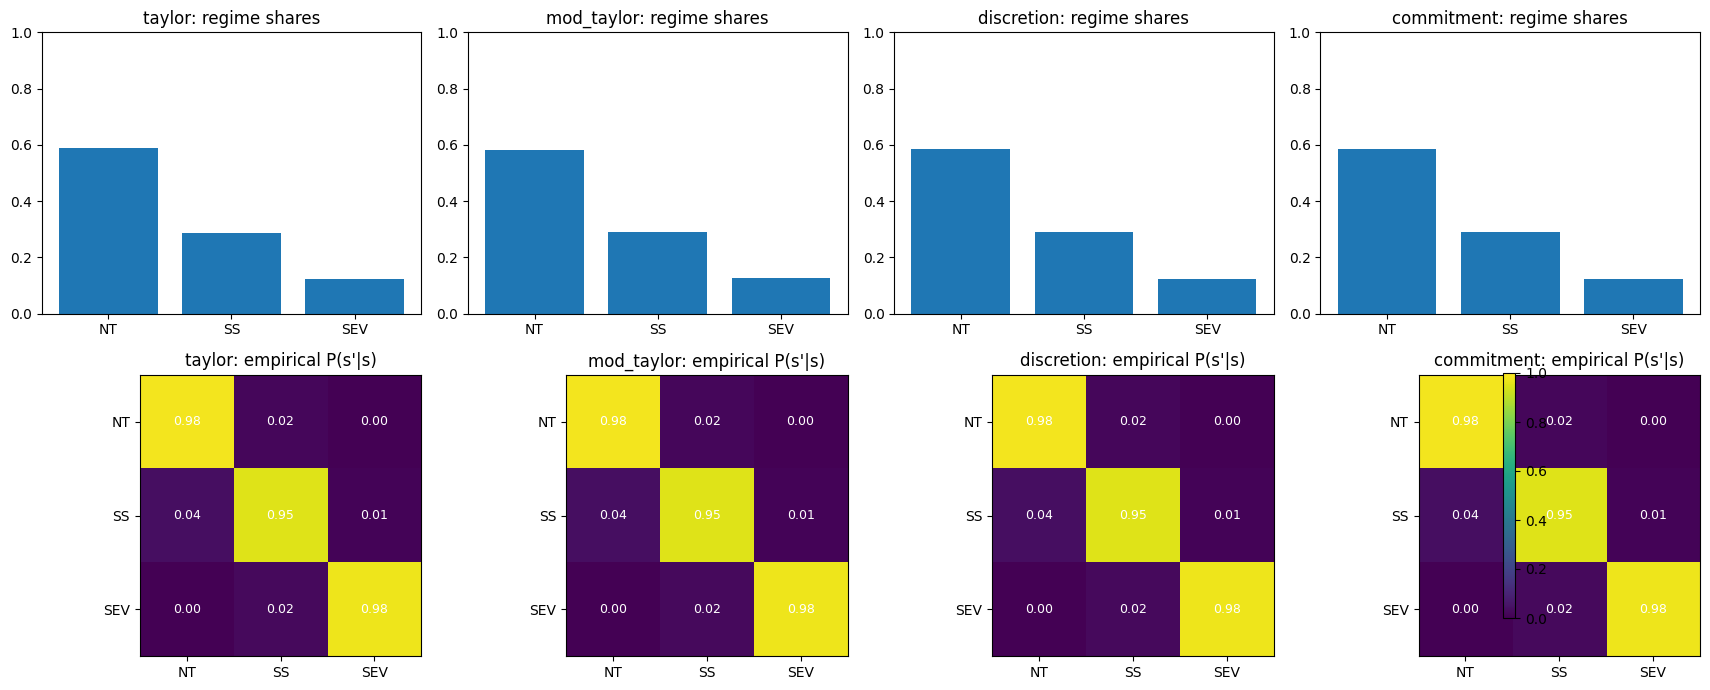

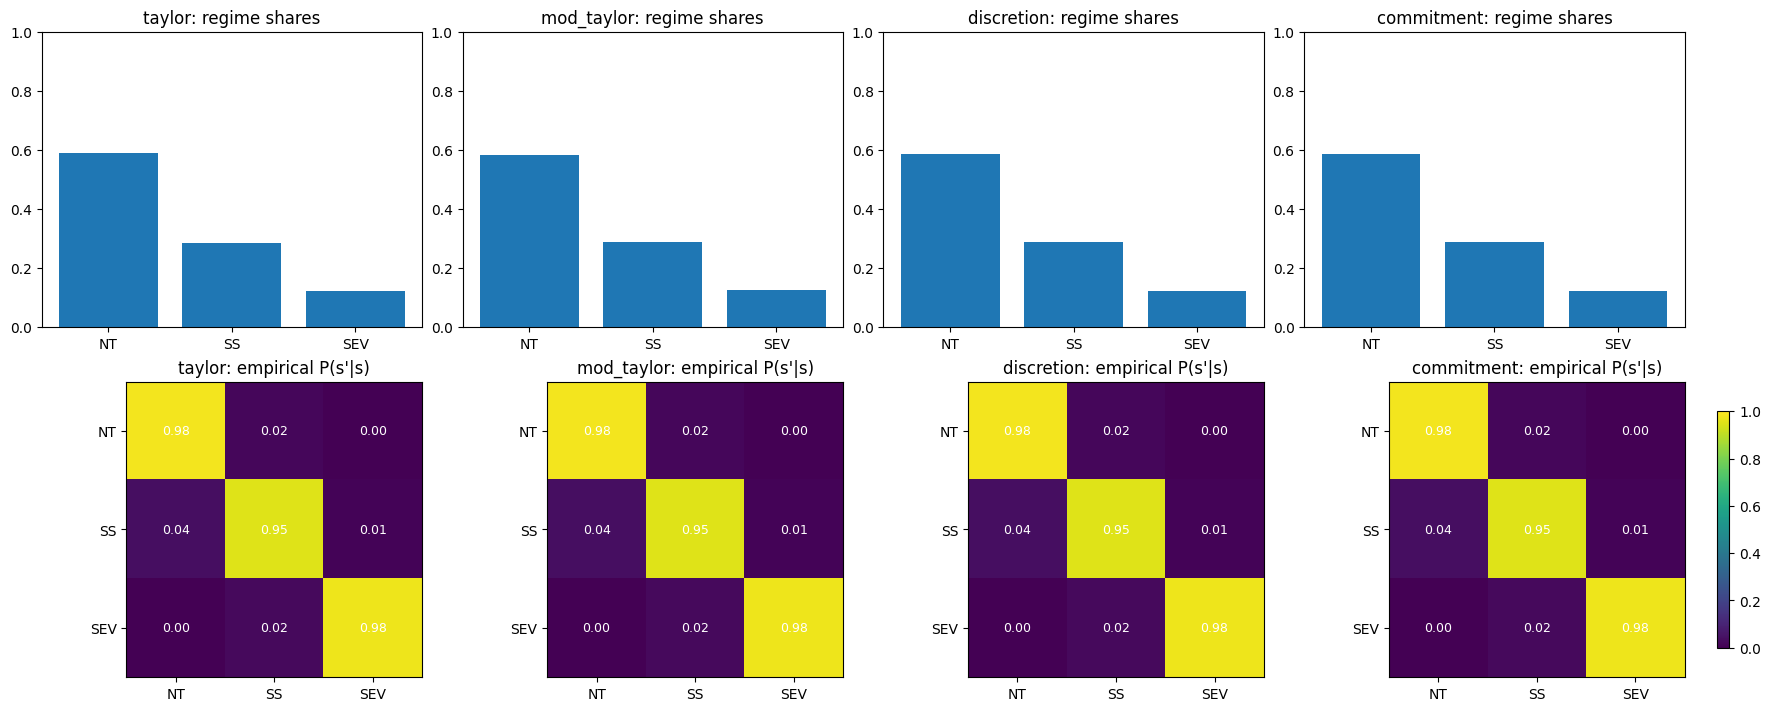

In [65]:
# Cell 5: ключевой график №1 — доли режимов + эмпирическая матрица переходов
def empirical_transition_matrix(s, n_reg=3):
    c = np.zeros((n_reg, n_reg), dtype=np.float64)
    for a, b in zip(s[:-1], s[1:]):
        if 0 <= a < n_reg and 0 <= b < n_reg:
            c[a, b] += 1.0
    row_sum = c.sum(axis=1, keepdims=True)
    P = np.divide(c, row_sum, out=np.zeros_like(c), where=row_sum > 0)
    return P

n_cols = len(POLICIES)
fig, ax = plt.subplots(2, n_cols, figsize=(4.4 * n_cols, 7), constrained_layout=True)
if n_cols == 1:
    ax = np.array(ax).reshape(2, 1)

im = None
for j, p in enumerate(POLICIES):
    if p not in defs:
        ax[0, j].axis("off")
        ax[1, j].axis("off")
        continue

    s = defs[p]["s"]
    shares = [np.mean(s == r) for r in REG_ORDER]
    P = empirical_transition_matrix(s, n_reg=3)

    ax[0, j].bar([REG_NAMES[r] for r in REG_ORDER], shares)
    ax[0, j].set_ylim(0, 1)
    ax[0, j].set_title(f"{p}: regime shares")

    im = ax[1, j].imshow(P, vmin=0, vmax=1, cmap="viridis")
    ax[1, j].set_xticks([0, 1, 2], [REG_NAMES[r] for r in REG_ORDER])
    ax[1, j].set_yticks([0, 1, 2], [REG_NAMES[r] for r in REG_ORDER])
    ax[1, j].set_title(f"{p}: empirical P(s'|s)")
    for r in range(3):
        for c in range(3):
            ax[1, j].text(c, r, f"{P[r, c]:.2f}", ha="center", va="center", color="white", fontsize=9)

if im is not None:
    fig.colorbar(im, ax=ax[1, :], shrink=0.8, pad=0.02)

plt.show()


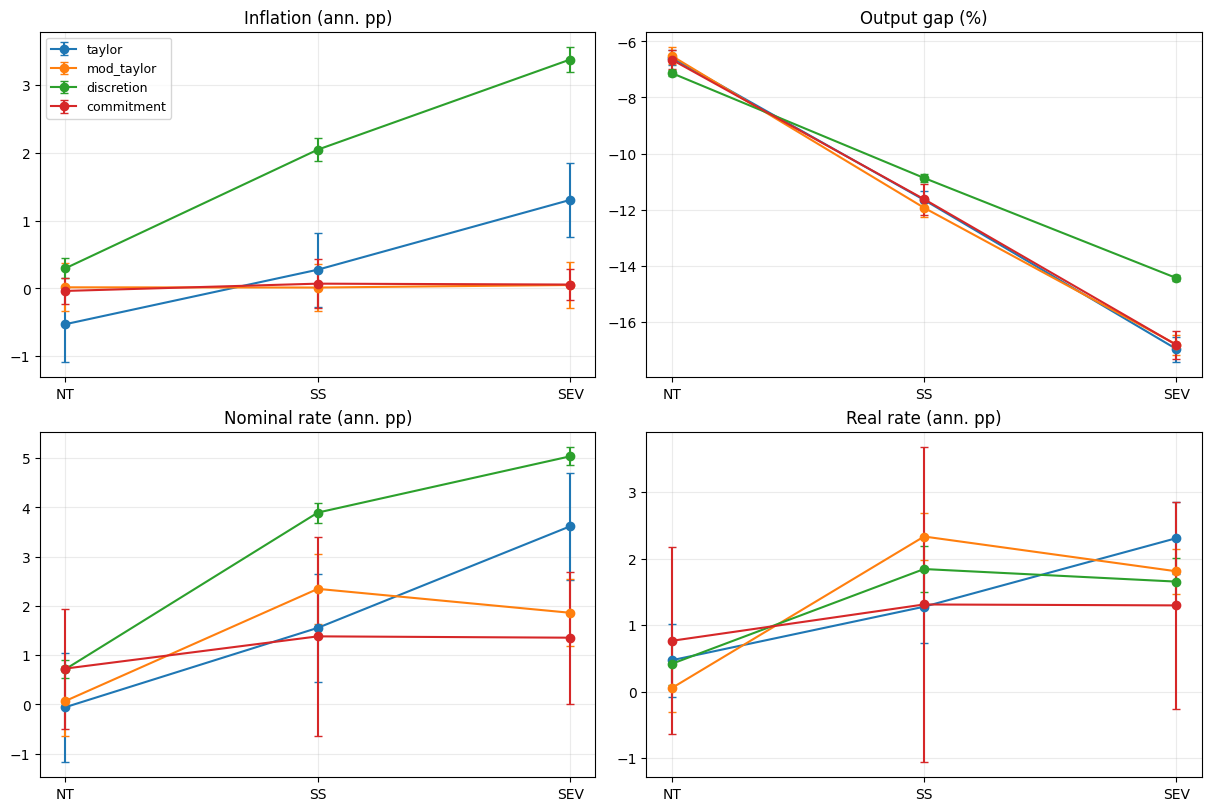

In [66]:
# Cell 6: ключевой график №2 — средние по режимам (pi, x, i, r) для 4 моделей
vars_cfg = [
    ("pi", "Inflation (ann. pp)"),
    ("x", "Output gap (%)"),
    ("i", "Nominal rate (ann. pp)"),
    ("r", "Real rate (ann. pp)"),
]
reg_labels = [REG_NAMES[r] for r in REG_ORDER]

fig, axs = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
axs = axs.ravel()

for k, (var, title) in enumerate(vars_cfg):
    a = axs[k]
    for p in POLICIES:
        if p not in defs:
            continue
        s = defs[p]["s"]
        v = defs[p][var]
        means = [np.mean(v[s == r]) if np.any(s == r) else np.nan for r in REG_ORDER]
        stds  = [np.std(v[s == r]) if np.any(s == r) else np.nan for r in REG_ORDER]
        a.errorbar(reg_labels, means, yerr=stds, marker="o", capsize=3, label=p)
    a.set_title(title)
    a.grid(alpha=0.25)
    if k == 0:
        a.legend(fontsize=9)

plt.show()

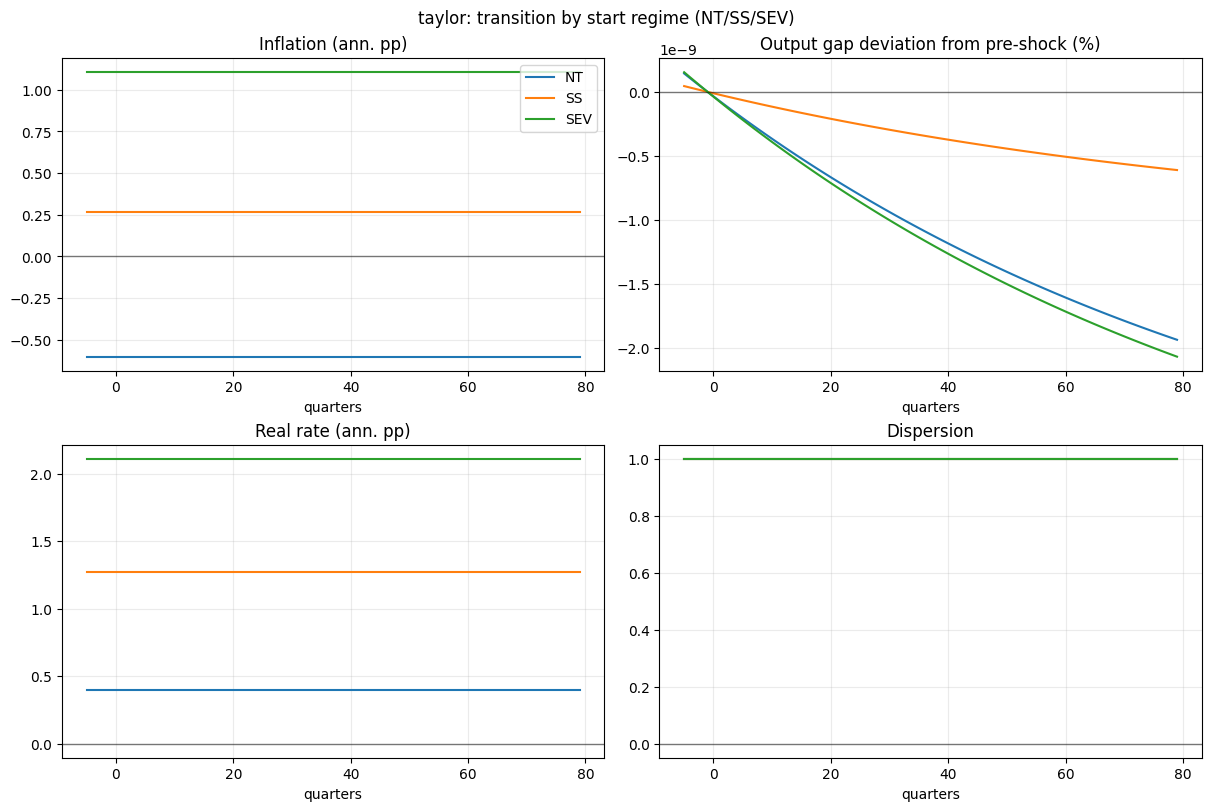

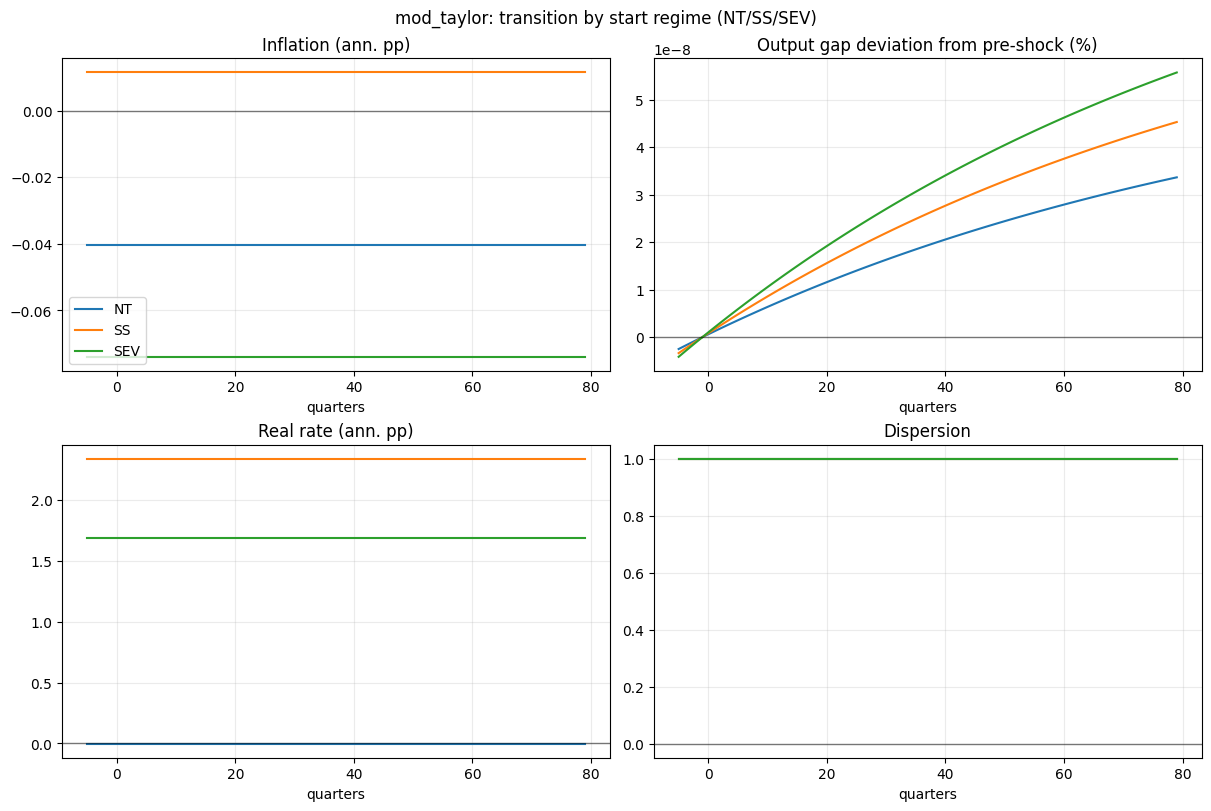

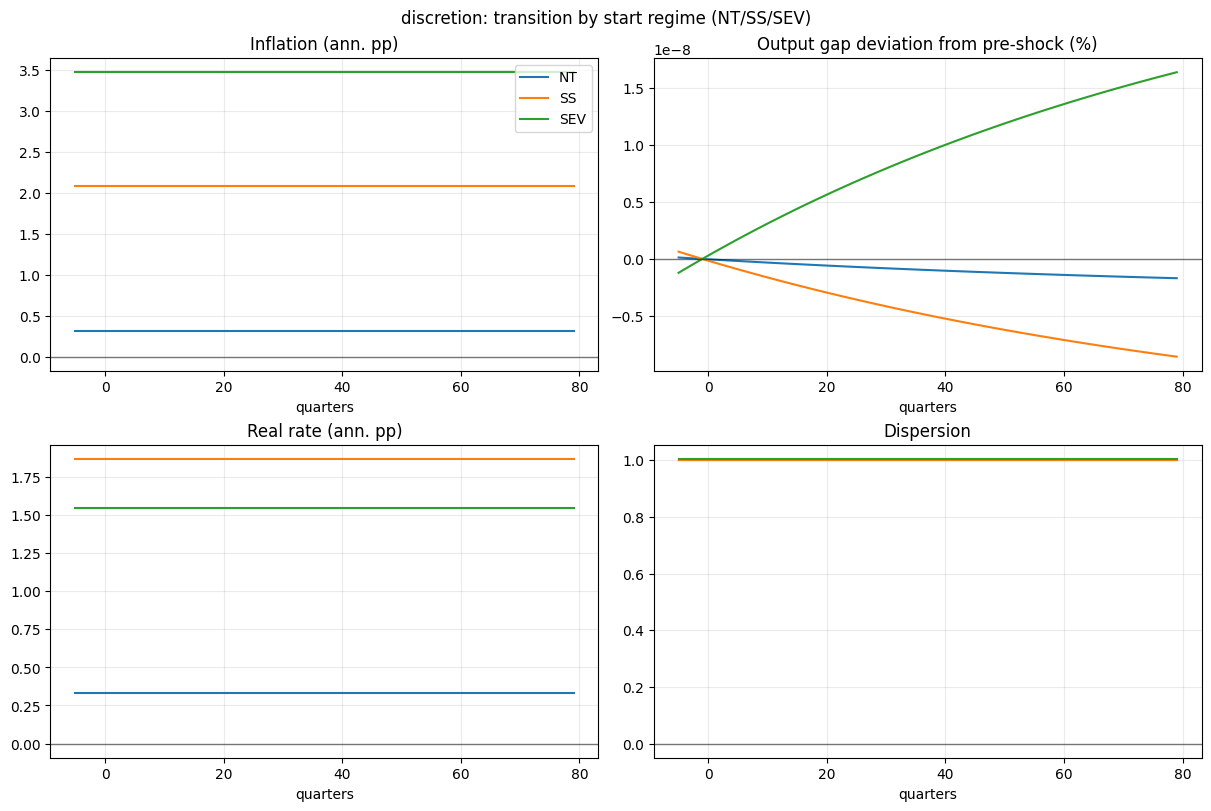

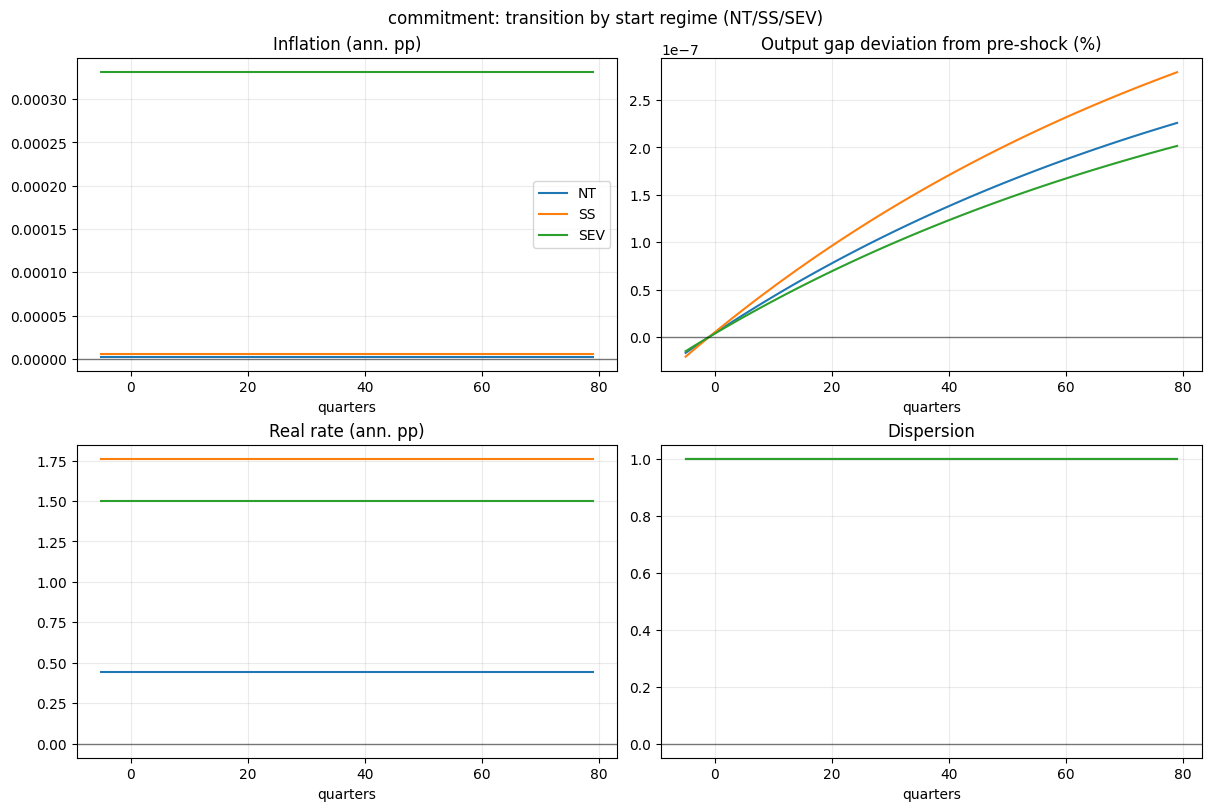

In [67]:

# Cell 7: ключевой график №3 — transition NT/SS/SEV по каждой политике
PRE = 5
H = 80

for p in POLICIES:
    if p not in ir_npz_paths:
        print(f"[skip] {p}: no IR path")
        continue

    curves = {}
    for tag in REG_TAGS:
        d = _load_ir_label(ir_npz_paths[p], tag)
        if d is not None:
            curves[tag] = d

    if not curves:
        print(f"[skip] {p}: no NT/SS/SEV labels in IR_definitions.npz")
        continue

    T = min([len(curves[t]["pi_tot_y"]) for t in curves] + [PRE + H])
    t = np.arange(-PRE, -PRE + T)

    fig, ax = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
    for tag in REG_TAGS:
        if tag not in curves:
            continue
        d = curves[tag]
        pi = _ann(d["pi_tot_y"][:T])
        x  = 100.0 * _x_dev_pre(d["out_gap_y"][:T], pre=PRE)
        r  = _ann(d["r_real_y"][:T])
        D  = d["disp_y"][:T]

        ax[0, 0].plot(t, pi, label=tag)
        ax[0, 1].plot(t, x, label=tag)
        ax[1, 0].plot(t, r, label=tag)
        ax[1, 1].plot(t, D, label=tag)

    ax[0, 0].set_title("Inflation (ann. pp)")
    ax[0, 1].set_title("Output gap deviation from pre-shock (%)")
    ax[1, 0].set_title("Real rate (ann. pp)")
    ax[1, 1].set_title("Dispersion")
    for a in ax.ravel():
        a.axhline(0, color="k", lw=1, alpha=0.5)
        a.set_xlabel("quarters")
        a.grid(alpha=0.25)
    ax[0, 0].legend()
    fig.suptitle(f"{p}: transition by start regime (NT/SS/SEV)")
    plt.show()



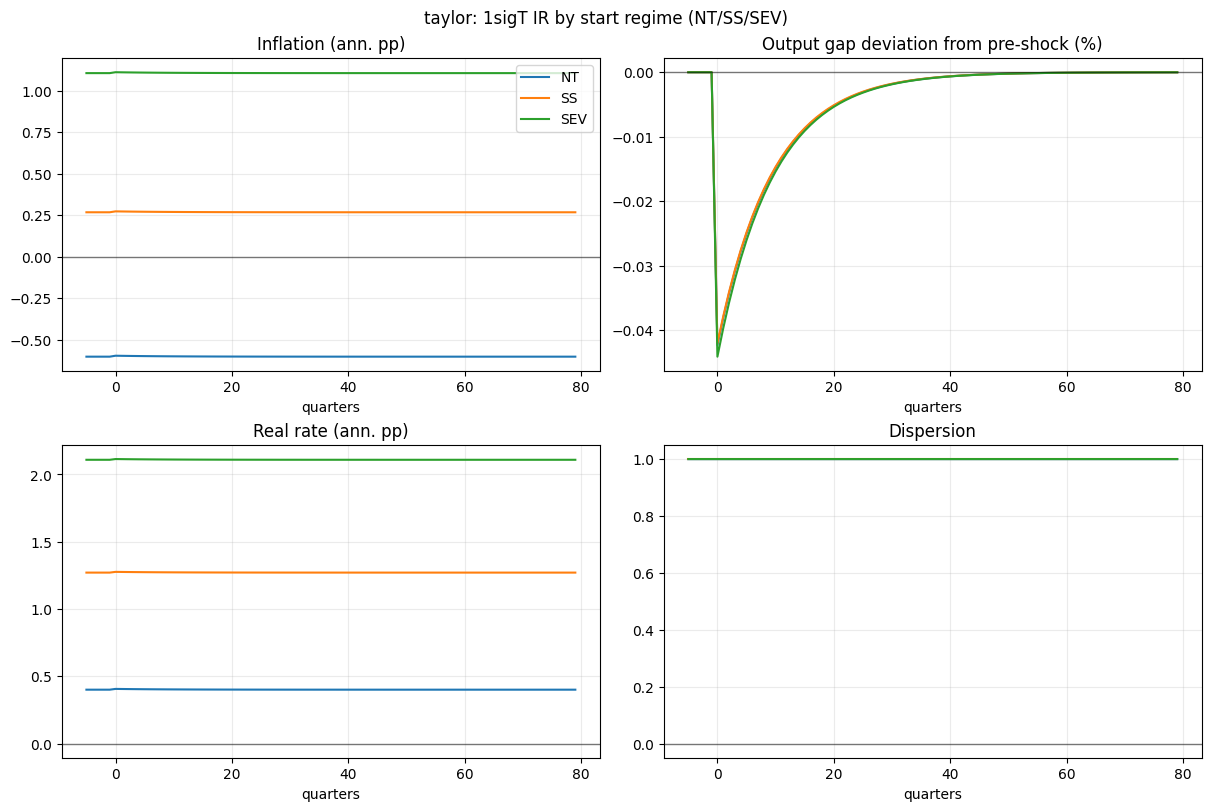

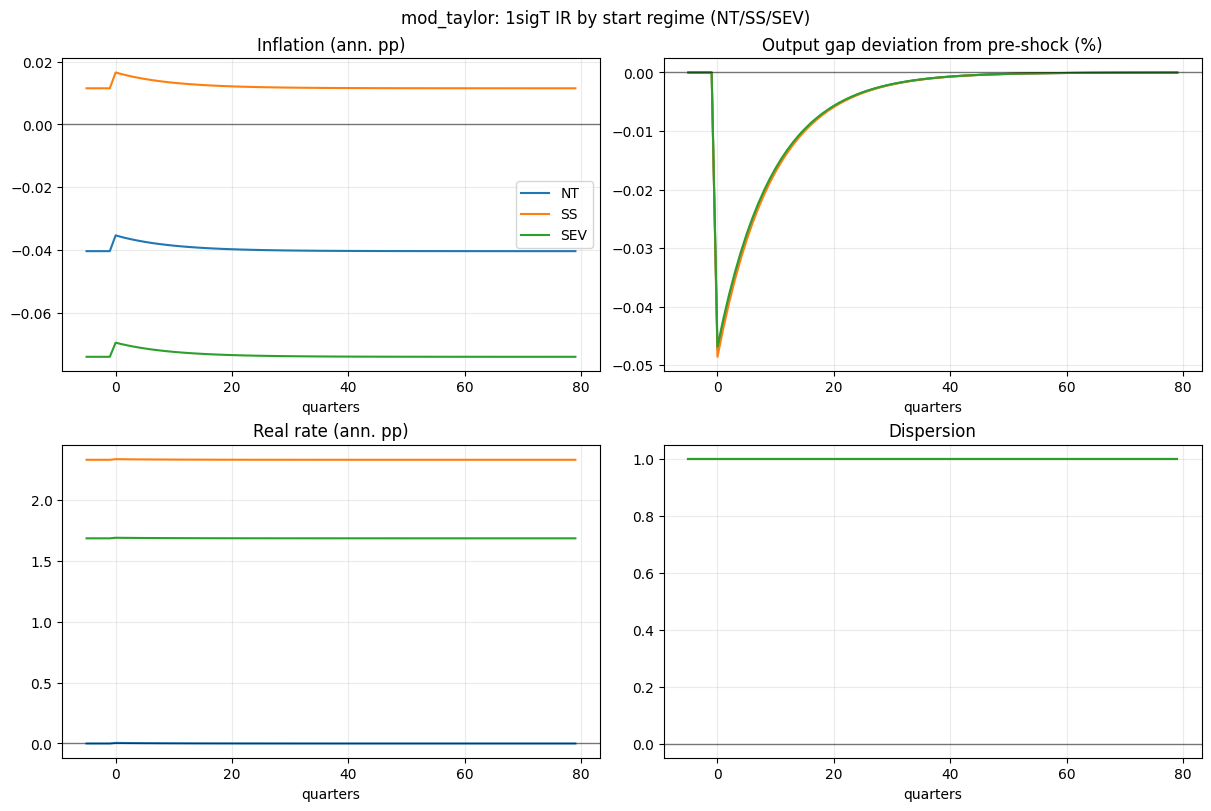

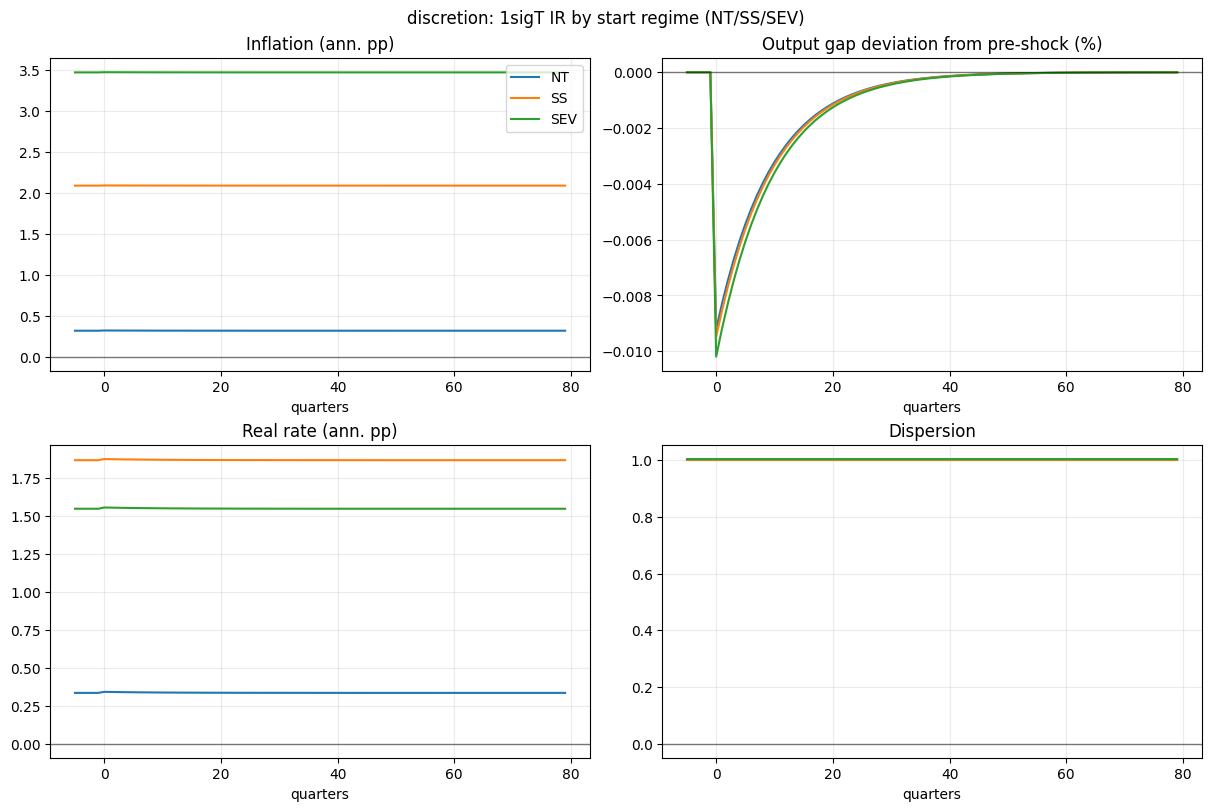

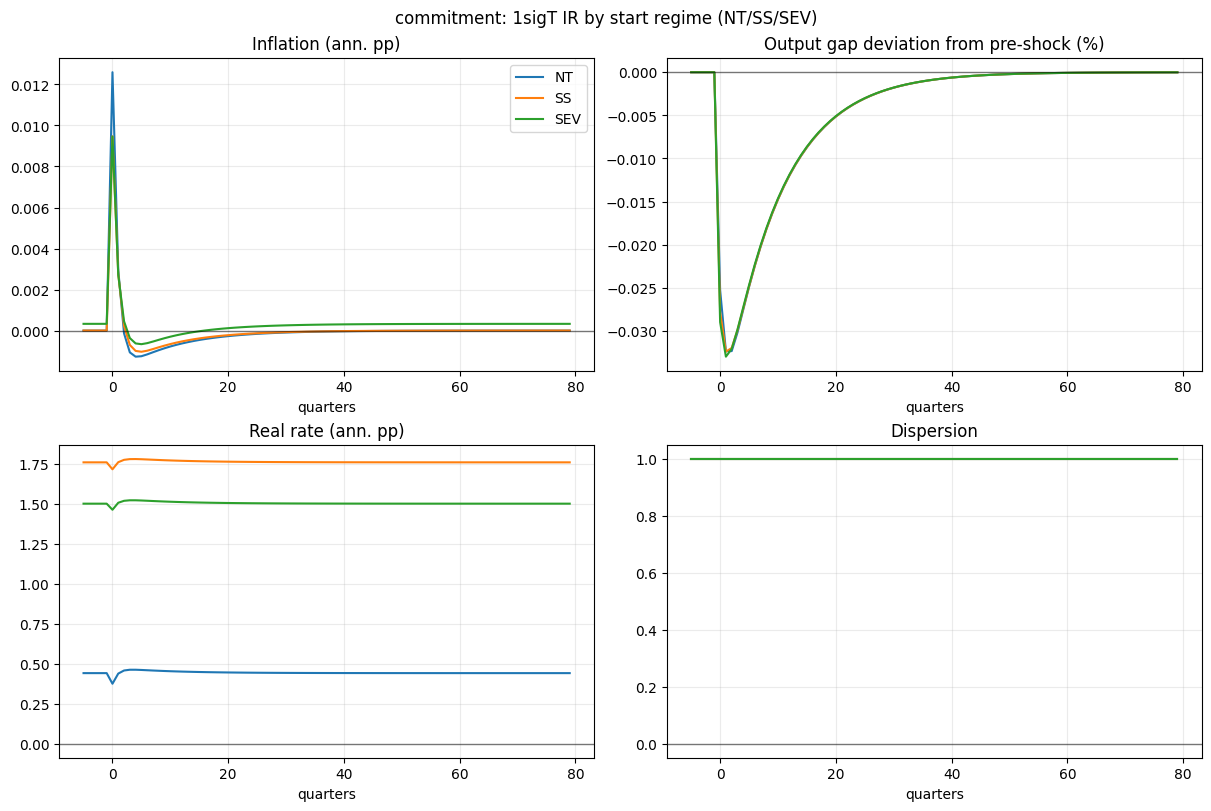

In [68]:
# Cell 8: ключевой график №4 — 1sigT IR по стартовым режимам для каждой политики
PRE = 5
H = 80

for p in POLICIES:
    if p not in ir_npz_paths:
        print(f"[skip] {p}: no IR path")
        continue

    curves = {}
    for tag in REG_TAGS:
        d = _load_ir_label(ir_npz_paths[p], f"1sigT_{tag}")
        if d is not None:
            curves[tag] = d

    if not curves:
        print(f"[skip] {p}: no 1sigT_NT/SS/SEV labels")
        continue

    T = min([len(curves[t]["pi_tot_y"]) for t in curves] + [PRE + H])
    t = np.arange(-PRE, -PRE + T)

    fig, ax = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
    for tag in REG_TAGS:
        if tag not in curves:
            continue
        d = curves[tag]
        pi = _ann(d["pi_tot_y"][:T])
        x  = 100.0 * _x_dev_pre(d["out_gap_y"][:T], pre=PRE)
        r  = _ann(d["r_real_y"][:T])
        D  = d["disp_y"][:T]

        ax[0, 0].plot(t, pi, label=tag)
        ax[0, 1].plot(t, x, label=tag)
        ax[1, 0].plot(t, r, label=tag)
        ax[1, 1].plot(t, D, label=tag)

    ax[0, 0].set_title("Inflation (ann. pp)")
    ax[0, 1].set_title("Output gap deviation from pre-shock (%)")
    ax[1, 0].set_title("Real rate (ann. pp)")
    ax[1, 1].set_title("Dispersion")
    for a in ax.ravel():
        a.axhline(0, color="k", lw=1, alpha=0.5)
        a.set_xlabel("quarters")
        a.grid(alpha=0.25)
    ax[0, 0].legend()
    fig.suptitle(f"{p}: 1sigT IR by start regime (NT/SS/SEV)")
    plt.show()



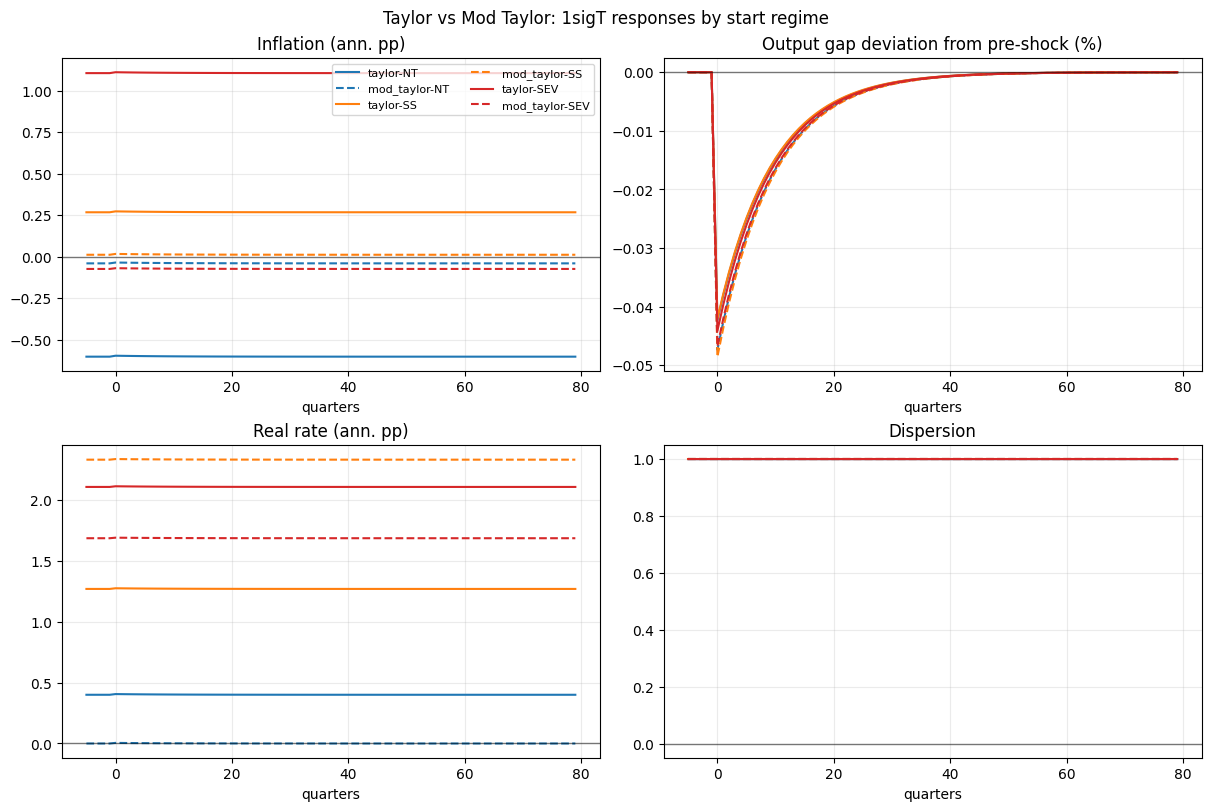

In [69]:
# Cell 9 (доп): прямое сравнение Taylor vs Mod Taylor на одном графике (1sigT, NT/SS/SEV)
pair = ("taylor", "mod_taylor")
PRE, H = 5, 80
colors = {"NT": "tab:blue", "SS": "tab:orange", "SEV": "tab:red"}
styles = {"taylor": "-", "mod_taylor": "--"}

if all(p in ir_npz_paths for p in pair):
    curves = {p: {} for p in pair}
    for p in pair:
        for tag in REG_TAGS:
            curves[p][tag] = _load_ir_label(ir_npz_paths[p], f"1sigT_{tag}")

    valid_tags = [tag for tag in REG_TAGS if all(curves[p][tag] is not None for p in pair)]
    if valid_tags:
        T = min([len(curves[p][tag]["pi_tot_y"]) for p in pair for tag in valid_tags] + [PRE + H])
        t = np.arange(-PRE, -PRE + T)

        fig, ax = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
        for tag in valid_tags:
            col = colors[tag]
            for p in pair:
                d = curves[p][tag]
                ls = styles[p]
                ax[0, 0].plot(t, _ann(d["pi_tot_y"][:T]), ls, color=col, label=f"{p}-{tag}")
                ax[0, 1].plot(t, 100.0 * _x_dev_pre(d["out_gap_y"][:T], pre=PRE), ls, color=col, label=f"{p}-{tag}")
                ax[1, 0].plot(t, _ann(d["r_real_y"][:T]), ls, color=col, label=f"{p}-{tag}")
                ax[1, 1].plot(t, d["disp_y"][:T], ls, color=col, label=f"{p}-{tag}")

        ax[0, 0].set_title("Inflation (ann. pp)")
        ax[0, 1].set_title("Output gap deviation from pre-shock (%)")
        ax[1, 0].set_title("Real rate (ann. pp)")
        ax[1, 1].set_title("Dispersion")
        for a in ax.ravel():
            a.axhline(0, color="k", lw=1, alpha=0.5)
            a.set_xlabel("quarters")
            a.grid(alpha=0.25)
        ax[0, 0].legend(fontsize=8, ncol=2)
        fig.suptitle("Taylor vs Mod Taylor: 1sigT responses by start regime")
        plt.show()
    else:
        print("[skip] no common 1sigT_{NT/SS/SEV} labels")
else:
    print("[skip] missing IR path for taylor/mod_taylor")

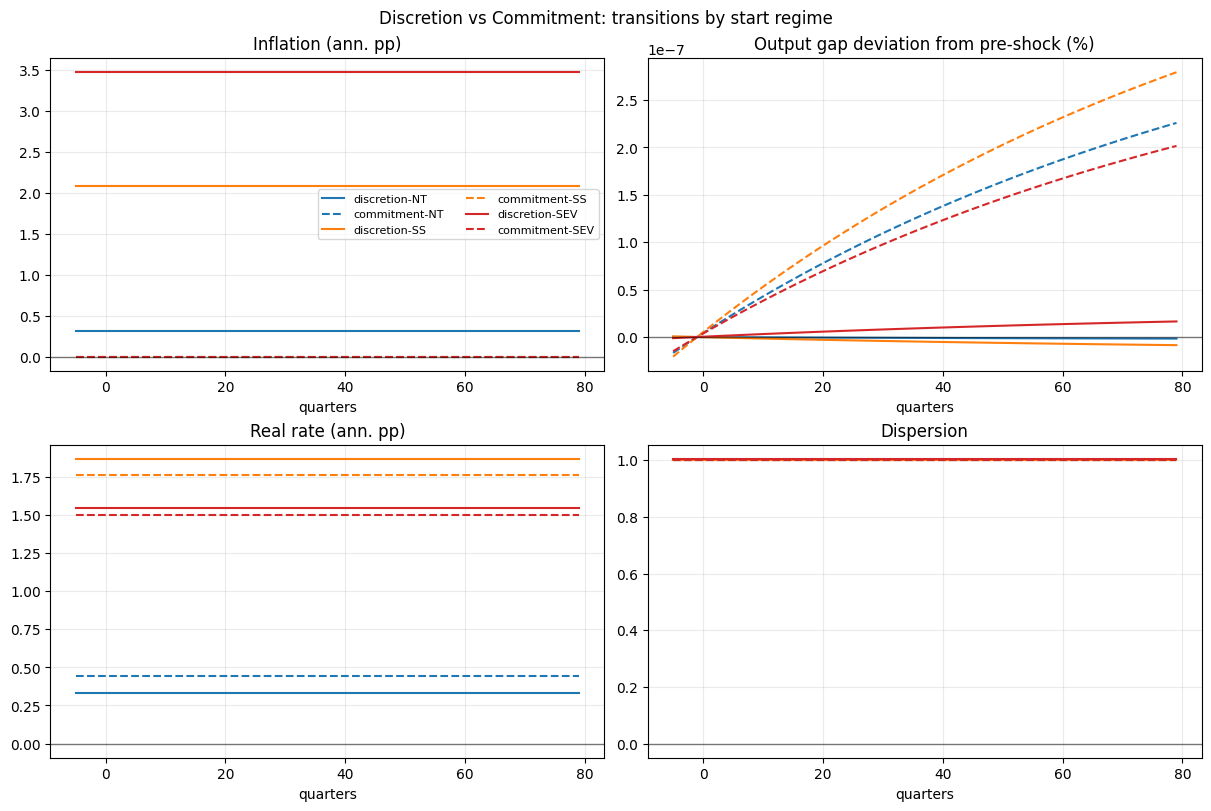

In [70]:
# Cell 10 (доп): прямое сравнение Discretion vs Commitment на одном графике (transition NT/SS/SEV)
pair = ("discretion", "commitment")
PRE, H = 5, 80
colors = {"NT": "tab:blue", "SS": "tab:orange", "SEV": "tab:red"}
styles = {"discretion": "-", "commitment": "--"}

if all(p in ir_npz_paths for p in pair):
    curves = {p: {} for p in pair}
    for p in pair:
        for tag in REG_TAGS:
            curves[p][tag] = _load_ir_label(ir_npz_paths[p], tag)

    valid_tags = [tag for tag in REG_TAGS if all(curves[p][tag] is not None for p in pair)]
    if valid_tags:
        T = min([len(curves[p][tag]["pi_tot_y"]) for p in pair for tag in valid_tags] + [PRE + H])
        t = np.arange(-PRE, -PRE + T)

        fig, ax = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
        for tag in valid_tags:
            col = colors[tag]
            for p in pair:
                d = curves[p][tag]
                ls = styles[p]
                ax[0, 0].plot(t, _ann(d["pi_tot_y"][:T]), ls, color=col, label=f"{p}-{tag}")
                ax[0, 1].plot(t, 100.0 * _x_dev_pre(d["out_gap_y"][:T], pre=PRE), ls, color=col, label=f"{p}-{tag}")
                ax[1, 0].plot(t, _ann(d["r_real_y"][:T]), ls, color=col, label=f"{p}-{tag}")
                ax[1, 1].plot(t, d["disp_y"][:T], ls, color=col, label=f"{p}-{tag}")

        ax[0, 0].set_title("Inflation (ann. pp)")
        ax[0, 1].set_title("Output gap deviation from pre-shock (%)")
        ax[1, 0].set_title("Real rate (ann. pp)")
        ax[1, 1].set_title("Dispersion")
        for a in ax.ravel():
            a.axhline(0, color="k", lw=1, alpha=0.5)
            a.set_xlabel("quarters")
            a.grid(alpha=0.25)
        ax[0, 0].legend(fontsize=8, ncol=2)
        fig.suptitle("Discretion vs Commitment: transitions by start regime")
        plt.show()
    else:
        print("[skip] no common NT/SS/SEV transition labels")
else:
    print("[skip] missing IR path for discretion/commitment")

НОРМАЛЬНЫЕ ГРАФИКИ ПО СТАТЬЕ, АНАЛИЗИРОВАТЬ ОБЯЗАТЕЛЬНО

In [71]:
# Cell 4: helper как в 116 (build + show)
import os, sys, shlex, pathlib, subprocess
from IPython.display import display, Image, Markdown
import torch

if "PROJECT_ROOT" not in globals():
    def _find_project_root() -> pathlib.Path:
        here = pathlib.Path.cwd().resolve()
        for p in [here, *here.parents]:
            if (p / "src").is_dir() and (p / "scripts" / "build_paper_figures_author_strict.py").is_file():
                return p
        cand = pathlib.Path("/content/econml")
        if (cand / "src").is_dir() and (cand / "scripts" / "build_paper_figures_author_strict.py").is_file():
            return cand
        raise RuntimeError("Project root not found")
    PROJECT_ROOT = _find_project_root()

if "ARTIFACTS_ROOT" not in globals():
    ARTIFACTS_ROOT = str(PROJECT_ROOT / "artifacts")
if "DEVICE" not in globals():
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
if "DTYPE" not in globals():
    DTYPE = "float64"
if "USE_SELECTED" not in globals():
    USE_SELECTED = True
if "CONS_MODE" not in globals():
    CONS_MODE = "author"

STRICT_FIG_DIR = str(PROJECT_ROOT / "artifacts" / "paper_figures_nb116_author_strict_4pol")
STRICT_ENSURE_INPUTS = True
_strict_figures_built = False

def build_strict_author_figures(force_rebuild: bool = False):
    global _strict_figures_built
    if _strict_figures_built and not force_rebuild:
        print("Strict-author figures already built in this session.")
        return

    cmd = [
        sys.executable,
        "scripts/build_paper_figures_author_strict.py",
        "--artifacts-root", ARTIFACTS_ROOT,
        "--fig-dir", STRICT_FIG_DIR,
        "--device", DEVICE,
        "--dtype", DTYPE,
        "--use-selected", str(bool(USE_SELECTED)).lower(),
        "--ensure-postprocess", str(bool(STRICT_ENSURE_INPUTS)).lower(),
        "--ensure-ir", str(bool(STRICT_ENSURE_INPUTS)).lower(),
        "--cons-mode", CONS_MODE,
    ]
    if force_rebuild:
        cmd += ["--force-rebuild-postprocess", "true", "--force-rebuild-ir", "true"]

    print("Running:", " ".join(shlex.quote(x) for x in cmd))
    subprocess.run(cmd, cwd=str(PROJECT_ROOT), check=True)
    _strict_figures_built = True
    print("Saved to:", STRICT_FIG_DIR)

def show_png(path, title=None, width=1100):
    p = pathlib.Path(path)
    if not p.exists():
        print(f"[skip] missing: {p.name}")
        return
    if title:
        display(Markdown(f"### {title}"))
    display(Image(filename=str(p), width=width))


In [74]:
# Cell A: setup + helpers (обход Figure 4)
import os, pathlib
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Image, Markdown

from src.io_utils import resolve_analysis_run_dir, _normalize_artifacts_root

plt.switch_backend("module://matplotlib_inline.backend_inline")

if "PROJECT_ROOT" not in globals():
    PROJECT_ROOT = pathlib.Path.cwd()

ARTIFACTS_ROOT = _normalize_artifacts_root(str(PROJECT_ROOT / "artifacts"))
FIG_DIR = str(PROJECT_ROOT / "artifacts" / "paper_figures_nb116_author_strict_4pol")
os.makedirs(FIG_DIR, exist_ok=True)

POL4 = ["taylor", "mod_taylor", "discretion", "commitment"]
run_dirs = {p: resolve_analysis_run_dir(ARTIFACTS_ROOT, p, prefer_selected=True) for p in POL4}
print(run_dirs)

def _ann(x):
    return 400.0 * np.asarray(x, dtype=np.float64)

def _regime_name(r: int) -> str:
    return {0: "normal", 1: "bad", 2: "severe"}.get(int(r), f"regime_{int(r)}")

def _regime_tag(r: int) -> str:
    return {0: "NT", 1: "SS", 2: "SEV"}.get(int(r), f"R{int(r)}")

def _hist_by_regime(ax, values, regimes, *, bins, alpha, colors, label_prefix=None):
    vals = np.asarray(values, dtype=np.float64).reshape(-1)
    regs = np.asarray(regimes, dtype=np.int64).reshape(-1)
    for j, r in enumerate(sorted(set(regs.tolist()))):
        m = regs == int(r)
        if not np.any(m):
            continue
        kw = {}
        if label_prefix is not None:
            kw["label"] = f"{label_prefix} {_regime_name(r)}"
        ax.hist(vals[m], bins=int(bins), alpha=float(alpha), color=colors[j % len(colors)], **kw)

def _load_defs(run_dir: str):
    p = pathlib.Path(run_dir) / "author_postprocess" / "simulated_definitions.npz"
    if not p.exists():
        raise FileNotFoundError(f"Missing {p}")
    z = np.load(p, allow_pickle=True)
    out = {
        "s": np.asarray(z["regime_x"]).reshape(-1).astype(np.int64),
        "s_r": np.asarray(z["regime_x"]).reshape(-1).astype(np.int64),
        "pi": np.asarray(z["pi_tot_y"]).reshape(-1),
        "x": np.asarray(z["out_gap_y"]).reshape(-1),
        "i": np.asarray(z["i_nom_y"]).reshape(-1),
        "r": np.asarray(z["r_real_y"]).reshape(-1),
        "Delta": np.asarray(z["disp_y"]).reshape(-1),
    }
    z.close()
    return out

def _load_ir_label(npz_path: str, label: str):
    z = np.load(npz_path, allow_pickle=True)
    if label not in z.files:
        z.close()
        return None
    raw = z[label]
    z.close()
    if isinstance(raw, dict):
        d = raw
    elif isinstance(raw, np.ndarray) and raw.dtype == object:
        d = raw.item()
    else:
        d = raw.item()
    out = {}
    for k, v in d.items():
        a = np.asarray(v, dtype=np.float64)
        if a.ndim == 2 and a.shape[1] >= 1:
            a = a[:, 0]
        out[k] = a.reshape(-1)
    return out

def _transition_pack(ir, *, pre, n_post):
    h = int(pre) + int(n_post)
    return (
        ir["pi_tot_y"][:h],
        ir["out_gap_y"][:h],
        ir["r_real_y"][:h],
        ir["disp_y"][:h],
    )

def _irf_pack(ir, *, pre, ir_h):
    h = min(int(pre) + int(ir_h), len(ir["pi_tot_y"]))
    pi = ir["pi_tot_y"][:h]
    x = ir["out_gap_y"][:h]
    r = ir["r_real_y"][:h]
    P = np.cumprod(np.clip(1.0 + pi, 1e-12, None))
    idx0 = max(0, int(pre) - 1)
    base = P[idx0] if P.size > 0 else 1.0
    if base != 0:
        P = P / base
    return pi, x, r, P

def _x_dev_pre_shock(x, *, pre):
    xs = np.asarray(x, dtype=np.float64).reshape(-1)
    if xs.size == 0:
        return xs
    idx0 = int(max(0, min(xs.size - 1, int(pre) - 1)))
    return xs - float(xs[idx0])

def _savefig(name: str):
    p = os.path.join(FIG_DIR, f"{name}.png")
    plt.savefig(p, dpi=160, bbox_inches="tight")
    print("[saved]", p)
    return p



{'taylor': '/content/econml/artifacts/runs/taylor/20260309_131741_author_seed151082_799c922b08', 'mod_taylor': '/content/econml/artifacts/runs/mod_taylor/20260309_135611_author_seed151082_899ff83b78', 'discretion': '/content/econml/artifacts/runs/discretion/20260309_145419_author_seed151082_3af7f65cd9', 'commitment': '/content/econml/artifacts/runs/commitment/20260309_154131_author_seed151082_4b5d037844'}


[saved] /content/econml/artifacts/paper_figures_nb116_author_strict_4pol/figure5.png


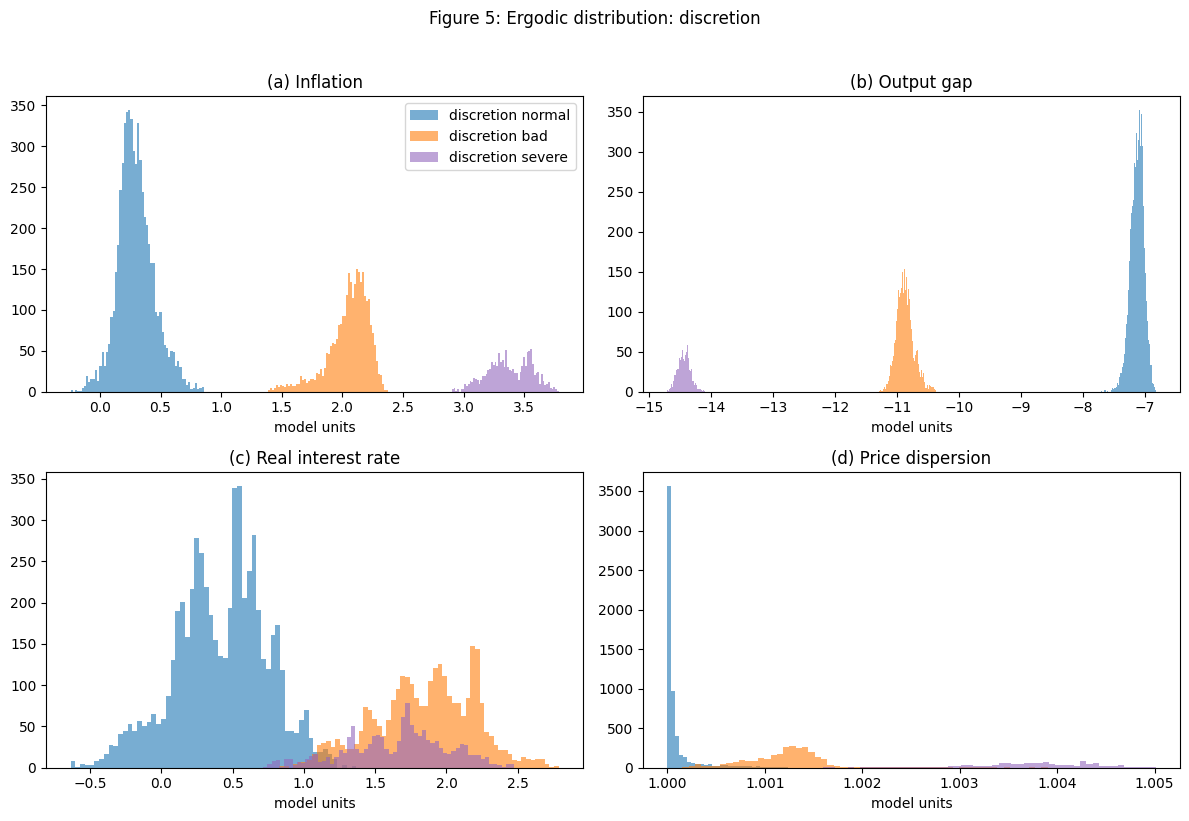

[saved] /content/econml/artifacts/paper_figures_nb116_author_strict_4pol/figure6.png


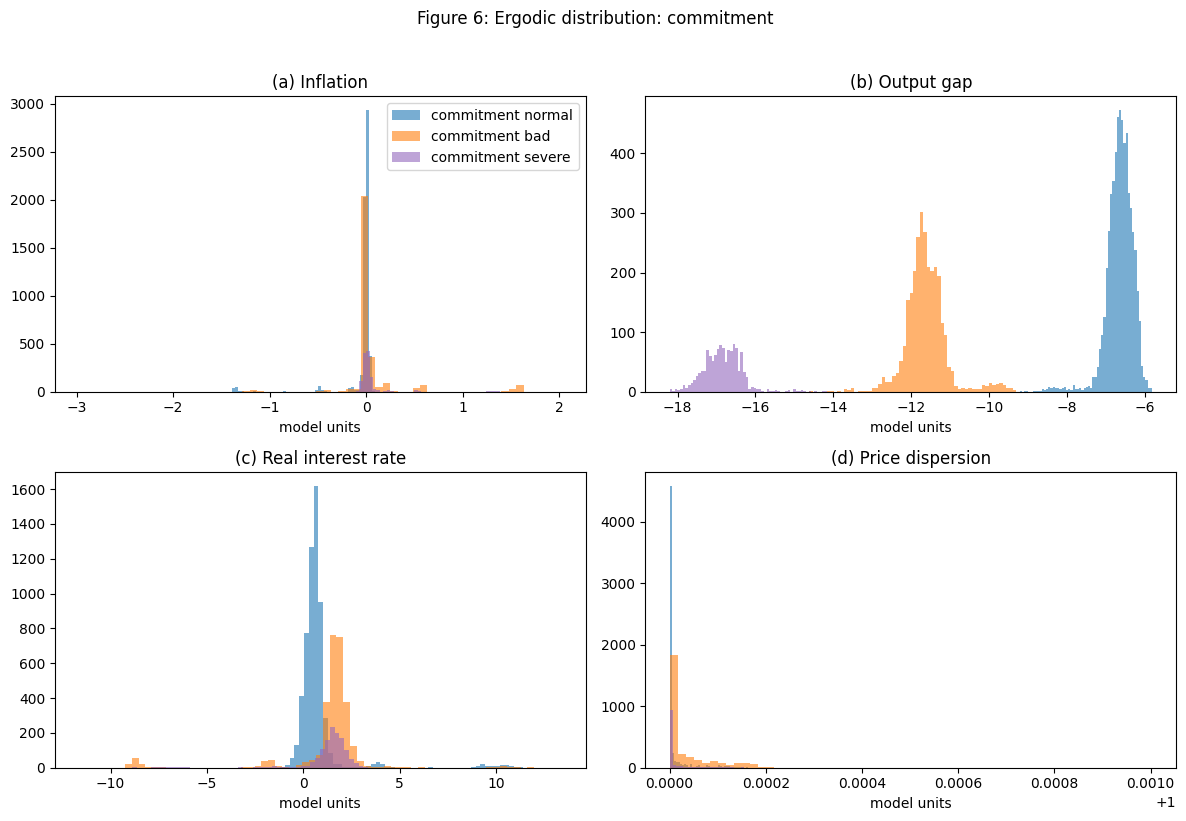

In [75]:
# Cell B: Figure 5 и Figure 6 (эрг. распределения discretion/commitment)
for pol, figname, ttl in [
    ("discretion", "figure5", "Figure 5: Ergodic distribution: discretion"),
    ("commitment", "figure6", "Figure 6: Ergodic distribution: commitment"),
]:
    rd = run_dirs.get(pol)
    if rd is None:
        print(f"[skip] {pol}: run_dir not found")
        continue
    try:
        s = _load_defs(rd)
    except Exception as e:
        print(f"[skip] {pol}: {e}")
        continue

    fig, ax = plt.subplots(2, 2, figsize=(12, 8))
    cols = ["tab:blue", "tab:orange", "tab:purple", "tab:brown", "tab:gray"]
    _hist_by_regime(ax[0, 0], _ann(s["pi"]), s["s"], bins=60, alpha=0.6, colors=cols, label_prefix=pol)
    ax[0, 0].set_title("(a) Inflation")
    ax[0, 0].legend()
    _hist_by_regime(ax[0, 1], 100.0 * s["x"], s["s"], bins=60, alpha=0.6, colors=cols)
    ax[0, 1].set_title("(b) Output gap")
    _hist_by_regime(ax[1, 0], _ann(s["r"]), s["s_r"], bins=60, alpha=0.6, colors=cols)
    ax[1, 0].set_title("(c) Real interest rate")
    _hist_by_regime(ax[1, 1], s["Delta"], s["s"], bins=60, alpha=0.6, colors=cols)
    ax[1, 1].set_title("(d) Price dispersion")
    for a in ax.ravel():
        a.set_xlabel("model units")
    fig.suptitle(ttl, y=1.02)
    plt.tight_layout()
    _savefig(figname)
    plt.show()

[saved] /content/econml/artifacts/paper_figures_nb116_author_strict_4pol/figure7.png


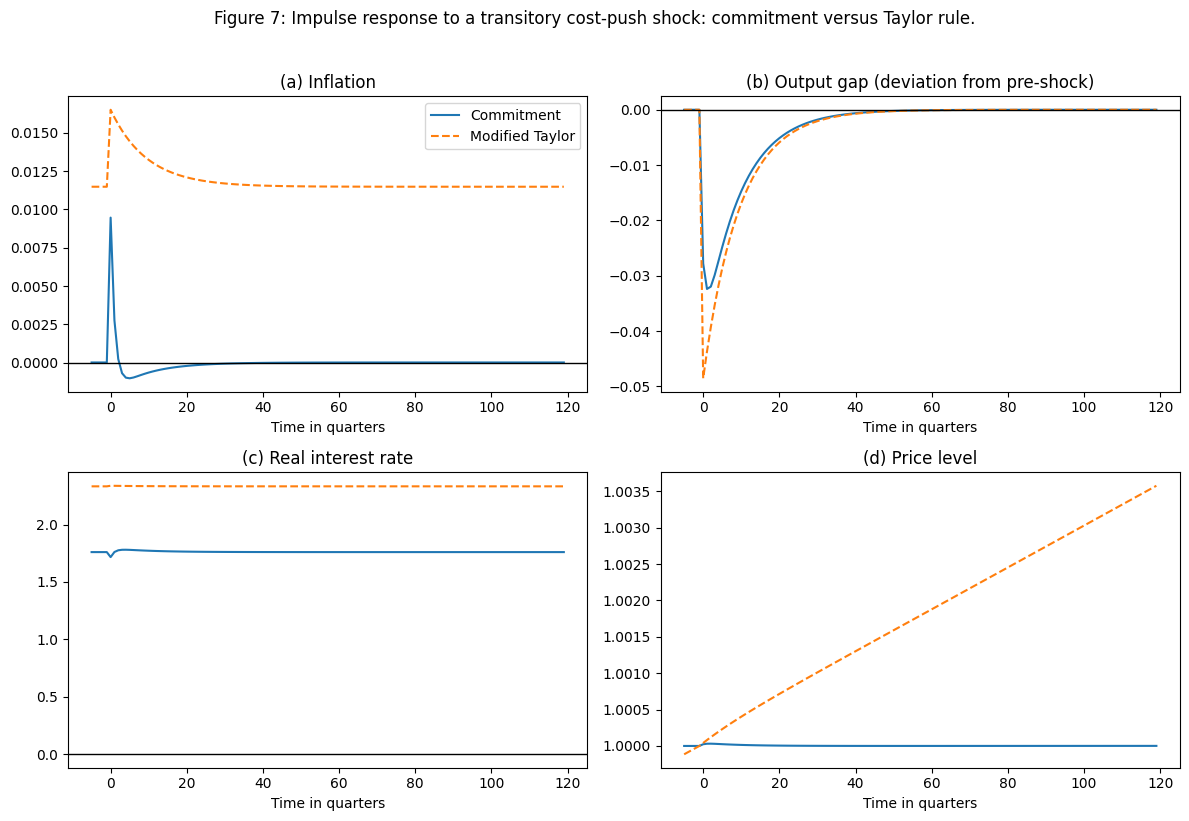

In [76]:
# Cell C: Figure 7 (IR: commitment vs mod_taylor)
pre, ir_h = 5, 120
rd_c = run_dirs.get("commitment")
rd_m = run_dirs.get("mod_taylor")

if rd_c is None or rd_m is None:
    print("[skip] commitment/mod_taylor run_dir not found")
else:
    ir_c_npz = pathlib.Path(rd_c) / "IRS" / "IR_definitions.npz"
    ir_m_npz = pathlib.Path(rd_m) / "IRS" / "IR_definitions.npz"
    ir7_c = _load_ir_label(str(ir_c_npz), "1sigT_SS") if ir_c_npz.exists() else None
    ir7_m = _load_ir_label(str(ir_m_npz), "1sigT_SS") if ir_m_npz.exists() else None

    if ir7_c is None or ir7_m is None:
        print("[skip] Figure 7: need labels 1sigT_SS in commitment/mod_taylor IR_definitions.npz")
    else:
        pi_c7, x_c7, r_c7, P_c7 = _irf_pack(ir7_c, pre=pre, ir_h=ir_h)
        pi_m7, x_m7, r_m7, P_m7 = _irf_pack(ir7_m, pre=pre, ir_h=ir_h)
        x_c7 = _x_dev_pre_shock(x_c7, pre=pre)
        x_m7 = _x_dev_pre_shock(x_m7, pre=pre)
        t7 = np.arange(-pre, -pre + len(pi_c7))

        fig, ax = plt.subplots(2, 2, figsize=(12, 8))
        ax[0, 0].plot(t7, _ann(pi_c7), label="Commitment")
        ax[0, 0].plot(t7, _ann(pi_m7), "--", label="Modified Taylor")
        ax[0, 0].axhline(0, color="k", lw=1)
        ax[0, 0].set_title("(a) Inflation")

        ax[0, 1].plot(t7, 100.0 * x_c7, label="Commitment")
        ax[0, 1].plot(t7, 100.0 * x_m7, "--", label="Modified Taylor")
        ax[0, 1].axhline(0, color="k", lw=1)
        ax[0, 1].set_title("(b) Output gap (deviation from pre-shock)")

        ax[1, 0].plot(t7, _ann(r_c7), label="Commitment")
        ax[1, 0].plot(t7, _ann(r_m7), "--", label="Modified Taylor")
        ax[1, 0].axhline(0, color="k", lw=1)
        ax[1, 0].set_title("(c) Real interest rate")

        ax[1, 1].plot(t7, P_c7, label="Commitment")
        ax[1, 1].plot(t7, P_m7, "--", label="Modified Taylor")
        ax[1, 1].set_title("(d) Price level")

        for a in ax.ravel():
            a.set_xlabel("Time in quarters")
        ax[0, 0].legend()
        fig.suptitle("Figure 7: Impulse response to a transitory cost-push shock: commitment versus Taylor rule.", y=1.02)
        plt.tight_layout()
        _savefig("figure7")
        plt.show()



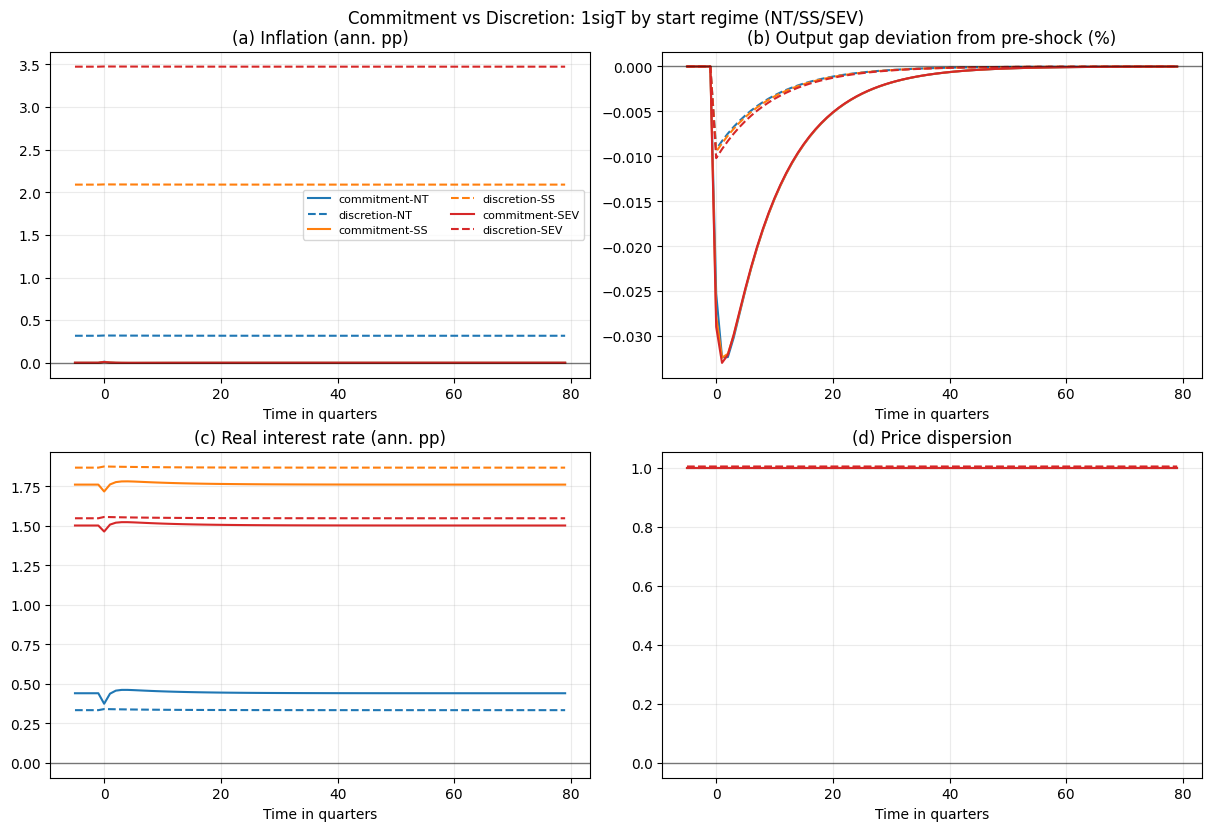

In [78]:
# Corrected: Commitment vs Discretion, IR(1sigT) by start regime NT/SS/SEV
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from src.io_utils import resolve_analysis_run_dir, _normalize_artifacts_root

ART = _normalize_artifacts_root(ARTIFACTS_ROOT if "ARTIFACTS_ROOT" in globals() else str(PROJECT_ROOT / "artifacts"))
USE_SEL = bool(USE_SELECTED) if "USE_SELECTED" in globals() else True

def _load_ir_label(npz_path, label):
    z = np.load(npz_path, allow_pickle=True)
    if label not in z.files:
        z.close()
        return None
    raw = z[label]
    z.close()
    if isinstance(raw, dict):
        d = raw
    elif isinstance(raw, np.ndarray) and raw.dtype == object:
        d = raw.item()
    else:
        d = raw.item()
    out = {}
    for k, v in d.items():
        a = np.asarray(v, dtype=np.float64)
        if a.ndim == 2 and a.shape[1] >= 1:
            a = a[:, 0]
        out[k] = a.reshape(-1)
    return out

def _ann(x): return 400.0 * np.asarray(x, dtype=np.float64)

def _x_dev_pre(x, pre=5):
    x = np.asarray(x, dtype=np.float64).reshape(-1)
    i0 = max(0, min(len(x)-1, pre-1))
    return x - x[i0]

pair = ("commitment", "discretion")
tags = ["NT", "SS", "SEV"]
colors = {"NT":"tab:blue", "SS":"tab:orange", "SEV":"tab:red"}
styles = {"commitment":"-", "discretion":"--"}
PRE, H = 5, 80

npz = {}
for p in pair:
    rd = resolve_analysis_run_dir(ART, p, prefer_selected=USE_SEL)
    if rd is None:
        raise RuntimeError(f"run_dir not found for {p}")
    f = Path(rd) / "IRS" / "IR_definitions.npz"
    if not f.exists():
        raise RuntimeError(f"IR_definitions missing for {p}: {f}")
    npz[p] = str(f)

curves = {p: {t: _load_ir_label(npz[p], f"1sigT_{t}") for t in tags} for p in pair}
valid = [t for t in tags if all(curves[p][t] is not None for p in pair)]
if not valid:
    raise RuntimeError("No common labels among 1sigT_NT / 1sigT_SS / 1sigT_SEV")

T = min([len(curves[p][t]["pi_tot_y"]) for p in pair for t in valid] + [PRE + H])
t = np.arange(-PRE, -PRE + T)

fig, ax = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
for tag in valid:
    col = colors[tag]
    for p in pair:
        d = curves[p][tag]
        ls = styles[p]
        ax[0,0].plot(t, _ann(d["pi_tot_y"][:T]), ls, color=col, label=f"{p}-{tag}")
        ax[0,1].plot(t, 100.0 * _x_dev_pre(d["out_gap_y"][:T], pre=PRE), ls, color=col, label=f"{p}-{tag}")
        ax[1,0].plot(t, _ann(d["r_real_y"][:T]), ls, color=col, label=f"{p}-{tag}")
        ax[1,1].plot(t, d["disp_y"][:T], ls, color=col, label=f"{p}-{tag}")

ax[0,0].set_title("(a) Inflation (ann. pp)")
ax[0,1].set_title("(b) Output gap deviation from pre-shock (%)")
ax[1,0].set_title("(c) Real interest rate (ann. pp)")
ax[1,1].set_title("(d) Price dispersion")
for a in ax.ravel():
    a.axhline(0, color="k", lw=1, alpha=0.5)
    a.set_xlabel("Time in quarters")
    a.grid(alpha=0.25)
ax[0,0].legend(fontsize=8, ncol=2)
fig.suptitle("Commitment vs Discretion: 1sigT by start regime (NT/SS/SEV)", y=1.02)
plt.show()



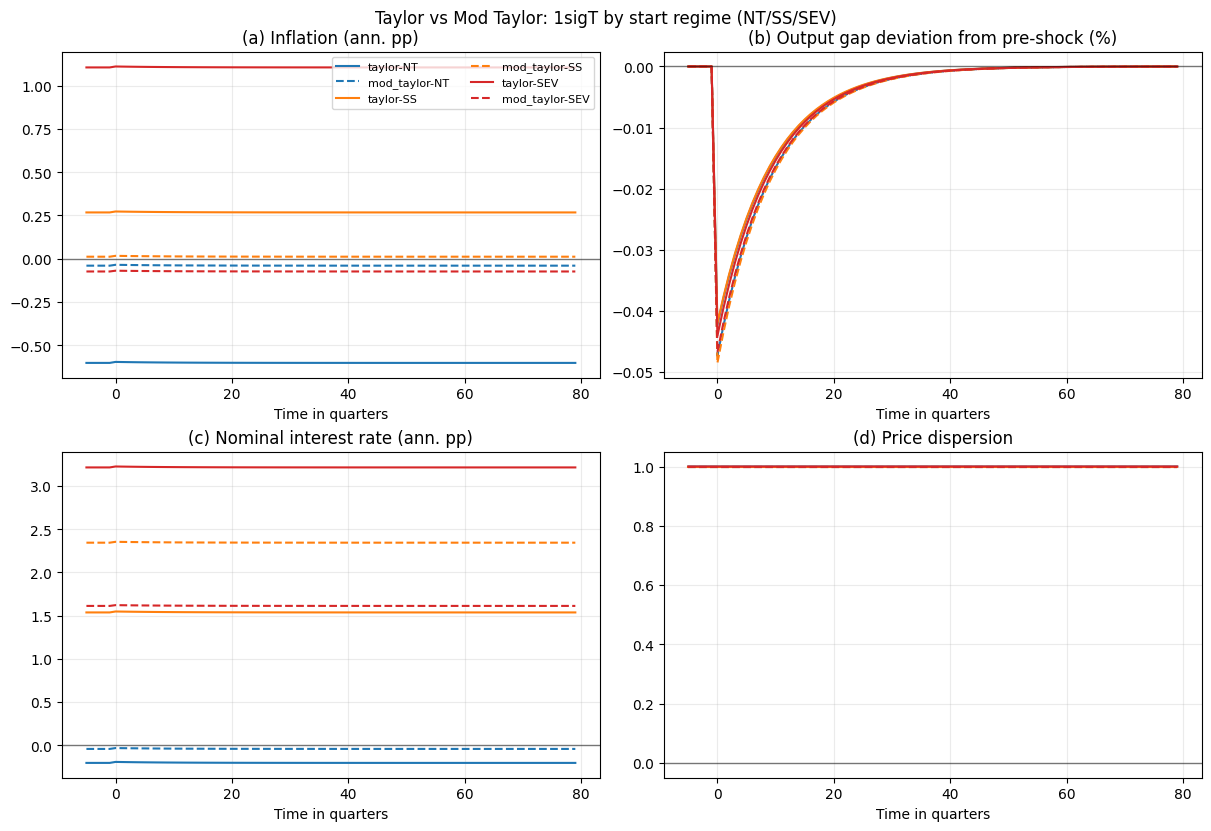

In [79]:
# Taylor vs Mod Taylor, IR(1sigT) by start regime NT/SS/SEV
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from src.io_utils import resolve_analysis_run_dir, _normalize_artifacts_root

ART = _normalize_artifacts_root(ARTIFACTS_ROOT if "ARTIFACTS_ROOT" in globals() else str(PROJECT_ROOT / "artifacts"))
USE_SEL = bool(USE_SELECTED) if "USE_SELECTED" in globals() else True

def _load_ir_label(npz_path, label):
    z = np.load(npz_path, allow_pickle=True)
    if label not in z.files:
        z.close()
        return None
    raw = z[label]
    z.close()
    if isinstance(raw, dict):
        d = raw
    elif isinstance(raw, np.ndarray) and raw.dtype == object:
        d = raw.item()
    else:
        d = raw.item()
    out = {}
    for k, v in d.items():
        a = np.asarray(v, dtype=np.float64)
        if a.ndim == 2 and a.shape[1] >= 1:
            a = a[:, 0]
        out[k] = a.reshape(-1)
    return out

def _ann(x): return 400.0 * np.asarray(x, dtype=np.float64)

def _x_dev_pre(x, pre=5):
    x = np.asarray(x, dtype=np.float64).reshape(-1)
    i0 = max(0, min(len(x)-1, pre-1))
    return x - x[i0]

pair = ("taylor", "mod_taylor")
tags = ["NT", "SS", "SEV"]
colors = {"NT":"tab:blue", "SS":"tab:orange", "SEV":"tab:red"}
styles = {"taylor":"-", "mod_taylor":"--"}
PRE, H = 5, 80

npz = {}
for p in pair:
    rd = resolve_analysis_run_dir(ART, p, prefer_selected=USE_SEL)
    if rd is None:
        raise RuntimeError(f"run_dir not found for {p}")
    f = Path(rd) / "IRS" / "IR_definitions.npz"
    if not f.exists():
        raise RuntimeError(f"IR_definitions missing for {p}: {f}")
    npz[p] = str(f)

curves = {p: {t: _load_ir_label(npz[p], f"1sigT_{t}") for t in tags} for p in pair}
valid = [t for t in tags if all(curves[p][t] is not None for p in pair)]
if not valid:
    raise RuntimeError("No common labels among 1sigT_NT / 1sigT_SS / 1sigT_SEV")

T = min([len(curves[p][t]["pi_tot_y"]) for p in pair for t in valid] + [PRE + H])
t = np.arange(-PRE, -PRE + T)

fig, ax = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
for tag in valid:
    col = colors[tag]
    for p in pair:
        d = curves[p][tag]
        ls = styles[p]
        ax[0,0].plot(t, _ann(d["pi_tot_y"][:T]), ls, color=col, label=f"{p}-{tag}")
        ax[0,1].plot(t, 100.0 * _x_dev_pre(d["out_gap_y"][:T], pre=PRE), ls, color=col, label=f"{p}-{tag}")
        ax[1,0].plot(t, _ann(d["i_nom_y"][:T]), ls, color=col, label=f"{p}-{tag}")
        ax[1,1].plot(t, d["disp_y"][:T], ls, color=col, label=f"{p}-{tag}")

ax[0,0].set_title("(a) Inflation (ann. pp)")
ax[0,1].set_title("(b) Output gap deviation from pre-shock (%)")
ax[1,0].set_title("(c) Nominal interest rate (ann. pp)")
ax[1,1].set_title("(d) Price dispersion")
for a in ax.ravel():
    a.axhline(0, color="k", lw=1, alpha=0.5)
    a.set_xlabel("Time in quarters")
    a.grid(alpha=0.25)
ax[0,0].legend(fontsize=8, ncol=2)
fig.suptitle("Taylor vs Mod Taylor: 1sigT by start regime (NT/SS/SEV)", y=1.02)
plt.show()

In [80]:
# Cell 1: проверить, что подхватываются нужные run_dir и IR файлы
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from src.io_utils import resolve_analysis_run_dir, _normalize_artifacts_root

ART = _normalize_artifacts_root(ARTIFACTS_ROOT if "ARTIFACTS_ROOT" in globals() else str(PROJECT_ROOT / "artifacts"))
USE_SEL = bool(USE_SELECTED) if "USE_SELECTED" in globals() else True

pols = ["taylor", "mod_taylor", "discretion", "commitment"]
ir_npz = {}
for p in pols:
    rd = resolve_analysis_run_dir(ART, p, prefer_selected=USE_SEL)
    print(f"{p:12s} run_dir =", rd)
    if rd is None:
        continue
    f = Path(rd) / "IRS" / "IR_definitions.npz"
    print(f"{p:12s} IR npz  =", f, "exists=", f.exists())
    if f.exists():
        ir_npz[p] = str(f)

taylor       run_dir = /content/econml/artifacts/runs/taylor/20260309_131741_author_seed151082_799c922b08
taylor       IR npz  = /content/econml/artifacts/runs/taylor/20260309_131741_author_seed151082_799c922b08/IRS/IR_definitions.npz exists= True
mod_taylor   run_dir = /content/econml/artifacts/runs/mod_taylor/20260309_135611_author_seed151082_899ff83b78
mod_taylor   IR npz  = /content/econml/artifacts/runs/mod_taylor/20260309_135611_author_seed151082_899ff83b78/IRS/IR_definitions.npz exists= True
discretion   run_dir = /content/econml/artifacts/runs/discretion/20260309_145419_author_seed151082_3af7f65cd9
discretion   IR npz  = /content/econml/artifacts/runs/discretion/20260309_145419_author_seed151082_3af7f65cd9/IRS/IR_definitions.npz exists= True
commitment   run_dir = /content/econml/artifacts/runs/commitment/20260309_154131_author_seed151082_4b5d037844
commitment   IR npz  = /content/econml/artifacts/runs/commitment/20260309_154131_author_seed151082_4b5d037844/IRS/IR_definitions.n

In [81]:
# Cell 2: sanity-check меток (чтобы увидеть, что это реально шоковые ряды, не константа)
def load_ir_label(npz_path, label):
    z = np.load(npz_path, allow_pickle=True)
    if label not in z.files:
        z.close()
        return None
    raw = z[label]
    z.close()
    if isinstance(raw, dict):
        d = raw
    elif isinstance(raw, np.ndarray) and raw.dtype == object:
        d = raw.item()
    else:
        d = raw.item()
    out = {}
    for k, v in d.items():
        a = np.asarray(v, dtype=np.float64)
        if a.ndim == 2 and a.shape[1] >= 1:
            a = a[:, 0]
        out[k] = a.reshape(-1)
    return out

labels = ["NT", "SS", "SEV", "1sigT_NT", "1sigT_SS", "1sigT_SEV"]
for p, f in ir_npz.items():
    print(f"\n=== {p} ===")
    z = np.load(f, allow_pickle=True)
    keys = set(z.files)
    z.close()
    print("has labels:", [lb for lb in labels if lb in keys])

    for lb in ["1sigT_NT", "1sigT_SS", "1sigT_SEV"]:
        d = load_ir_label(f, lb)
        if d is None:
            print(f"  {lb}: missing")
            continue
        pre = 5
        i0 = pre - 1
        pi = d["pi_tot_y"]; x = d["out_gap_y"]; i = d["i_nom_y"]; r = d["r_real_y"]
        print(
            f"  {lb}: std(pi[i0:])={np.std(pi[i0:]):.3e}, "
            f"std(x[i0:])={np.std(x[i0:]):.3e}, "
            f"std(i[i0:])={np.std(i[i0:]):.3e}, "
            f"std(r[i0:])={np.std(r[i0:]):.3e}"
        )




=== taylor ===
has labels: ['NT', 'SS', 'SEV', '1sigT_NT', '1sigT_SS', '1sigT_SEV']
  1sigT_NT: std(pi[i0:])=1.592e-06, std(x[i0:])=4.738e-05, std(i[i0:])=3.185e-06, std(r[i0:])=1.592e-06
  1sigT_SS: std(pi[i0:])=1.519e-06, std(x[i0:])=4.704e-05, std(i[i0:])=3.038e-06, std(r[i0:])=1.519e-06
  1sigT_SEV: std(pi[i0:])=1.514e-06, std(x[i0:])=4.933e-05, std(i[i0:])=3.027e-06, std(r[i0:])=1.514e-06

=== mod_taylor ===
has labels: ['NT', 'SS', 'SEV', '1sigT_NT', '1sigT_SS', '1sigT_SEV']
  1sigT_NT: std(pi[i0:])=1.402e-06, std(x[i0:])=5.295e-05, std(i[i0:])=2.804e-06, std(r[i0:])=1.402e-06
  1sigT_SS: std(pi[i0:])=1.406e-06, std(x[i0:])=5.428e-05, std(i[i0:])=2.812e-06, std(r[i0:])=1.406e-06
  1sigT_SEV: std(pi[i0:])=1.257e-06, std(x[i0:])=5.230e-05, std(i[i0:])=2.514e-06, std(r[i0:])=1.257e-06

=== discretion ===
has labels: ['NT', 'SS', 'SEV', '1sigT_NT', '1sigT_SS', '1sigT_SEV']
  1sigT_NT: std(pi[i0:])=7.757e-07, std(x[i0:])=1.031e-05, std(i[i0:])=2.707e-06, std(r[i0:])=1.931e-06
  1sigT

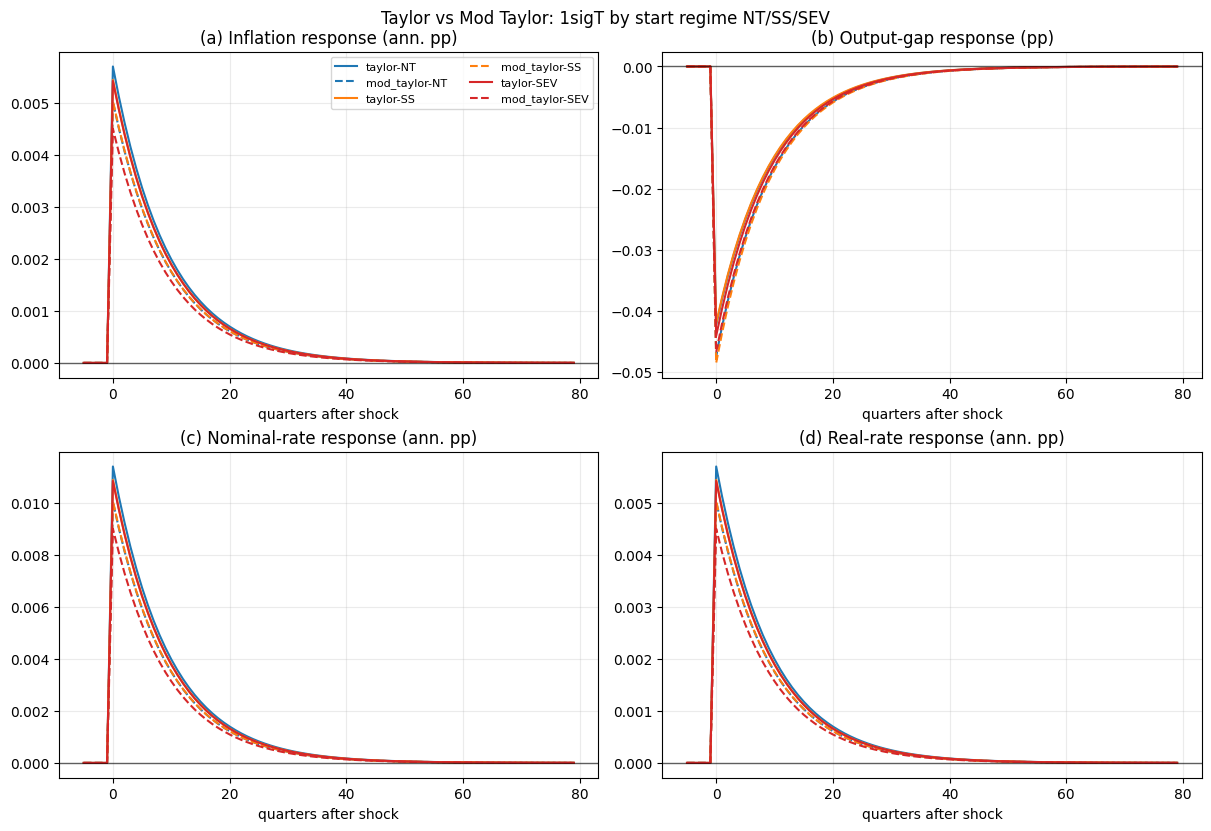

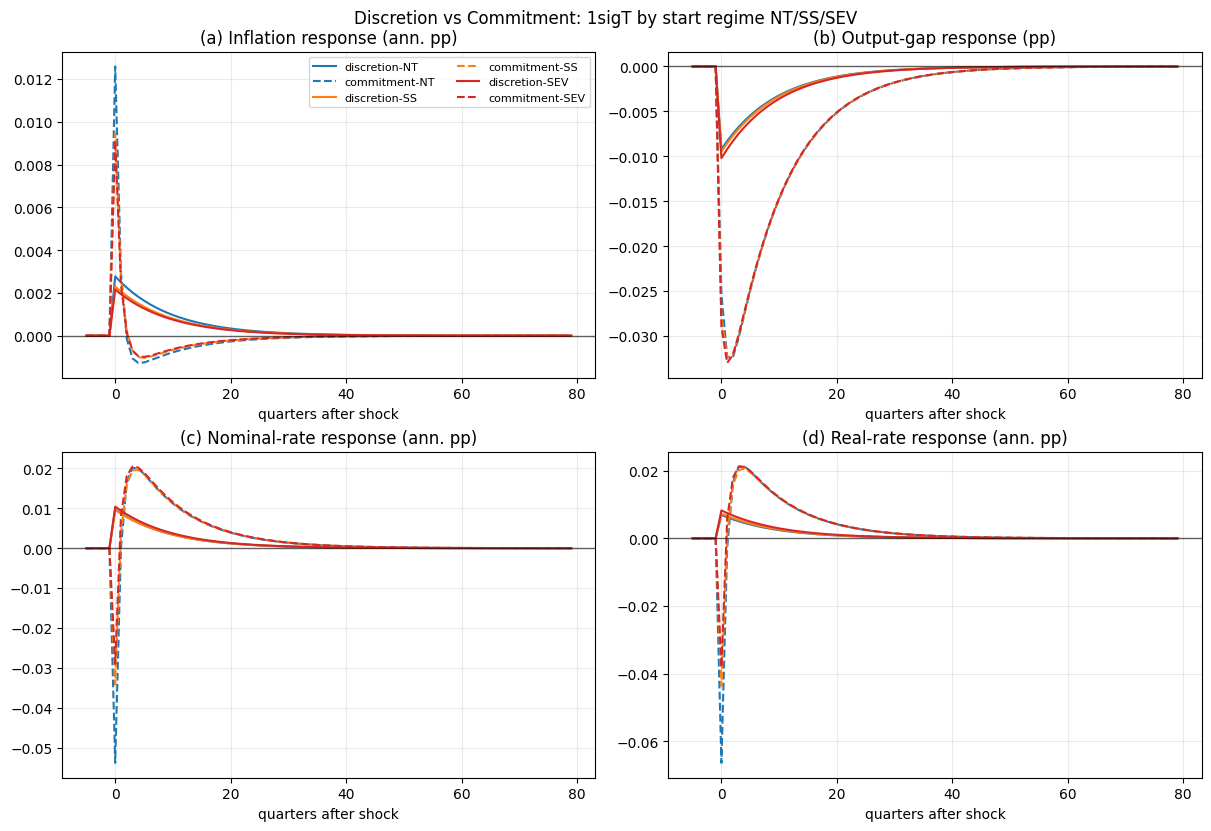

In [82]:
# Cell 3: правильные IRF-графики (как реакции), пары:
# Taylor vs Mod Taylor, Discretion vs Commitment
def plot_pair_1sigT(pair, title, pre=5, h=80):
    tags = ["NT", "SS", "SEV"]
    colors = {"NT": "tab:blue", "SS": "tab:orange", "SEV": "tab:red"}
    styles = {pair[0]: "-", pair[1]: "--"}

    if pair[0] not in ir_npz or pair[1] not in ir_npz:
        print(f"[skip] missing IR for pair {pair}")
        return

    curves = {p: {t: load_ir_label(ir_npz[p], f"1sigT_{t}") for t in tags} for p in pair}
    valid = [t for t in tags if all(curves[p][t] is not None for p in pair)]
    if not valid:
        print(f"[skip] no common 1sigT labels for pair {pair}")
        return

    T = min([len(curves[p][t]["pi_tot_y"]) for p in pair for t in valid] + [pre + h])
    tgrid = np.arange(-pre, -pre + T)
    i0 = max(0, min(T - 1, pre - 1))

    fig, ax = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
    for tag in valid:
        col = colors[tag]
        for p in pair:
            d = curves[p][tag]
            ls = styles[p]

            # реакции = отклонения от pre-shock
            pi_dev = 400.0 * (d["pi_tot_y"][:T] - d["pi_tot_y"][:T][i0])
            x_dev  = 100.0 * (d["out_gap_y"][:T] - d["out_gap_y"][:T][i0])
            i_dev  = 400.0 * (d["i_nom_y"][:T] - d["i_nom_y"][:T][i0])
            r_dev  = 400.0 * (d["r_real_y"][:T] - d["r_real_y"][:T][i0])

            ax[0,0].plot(tgrid, pi_dev, ls, color=col, label=f"{p}-{tag}")
            ax[0,1].plot(tgrid, x_dev,  ls, color=col, label=f"{p}-{tag}")
            ax[1,0].plot(tgrid, i_dev,  ls, color=col, label=f"{p}-{tag}")
            ax[1,1].plot(tgrid, r_dev,  ls, color=col, label=f"{p}-{tag}")

    ax[0,0].set_title("(a) Inflation response (ann. pp)")
    ax[0,1].set_title("(b) Output-gap response (pp)")
    ax[1,0].set_title("(c) Nominal-rate response (ann. pp)")
    ax[1,1].set_title("(d) Real-rate response (ann. pp)")

    for a in ax.ravel():
        a.axhline(0, color="k", lw=1, alpha=0.6)
        a.set_xlabel("quarters after shock")
        a.grid(alpha=0.25)

    ax[0,0].legend(fontsize=8, ncol=2)
    fig.suptitle(title, y=1.02)
    plt.show()

plot_pair_1sigT(("taylor", "mod_taylor"), "Taylor vs Mod Taylor: 1sigT by start regime NT/SS/SEV")
plot_pair_1sigT(("discretion", "commitment"), "Discretion vs Commitment: 1sigT by start regime NT/SS/SEV")



In [83]:

# Cell X1: helper (IRF только из 1sigT_*)
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from src.io_utils import resolve_analysis_run_dir, _normalize_artifacts_root

ART = _normalize_artifacts_root(ARTIFACTS_ROOT if "ARTIFACTS_ROOT" in globals() else str(PROJECT_ROOT / "artifacts"))
USE_SEL = bool(USE_SELECTED) if "USE_SELECTED" in globals() else True
PRE = 5
H = 80

def load_ir_label(npz_path, label):
    z = np.load(npz_path, allow_pickle=True)
    if label not in z.files:
        z.close()
        return None
    raw = z[label]
    z.close()
    if isinstance(raw, dict):
        d = raw
    elif isinstance(raw, np.ndarray) and raw.dtype == object:
        d = raw.item()
    else:
        d = raw.item()
    out = {}
    for k, v in d.items():
        a = np.asarray(v, dtype=np.float64)
        if a.ndim == 2 and a.shape[1] >= 1:
            a = a[:, 0]
        out[k] = a.reshape(-1)
    return out

def ir_npz(policy):
    rd = resolve_analysis_run_dir(ART, policy, prefer_selected=USE_SEL)
    if rd is None:
        return None
    p = Path(rd) / "IRS" / "IR_definitions.npz"
    return str(p) if p.exists() else None

def dev(a, pre=5):
    a = np.asarray(a, dtype=np.float64).reshape(-1)
    i0 = max(0, min(len(a)-1, pre-1))
    return a - a[i0]

def ann(a): return 400.0*np.asarray(a, dtype=np.float64)


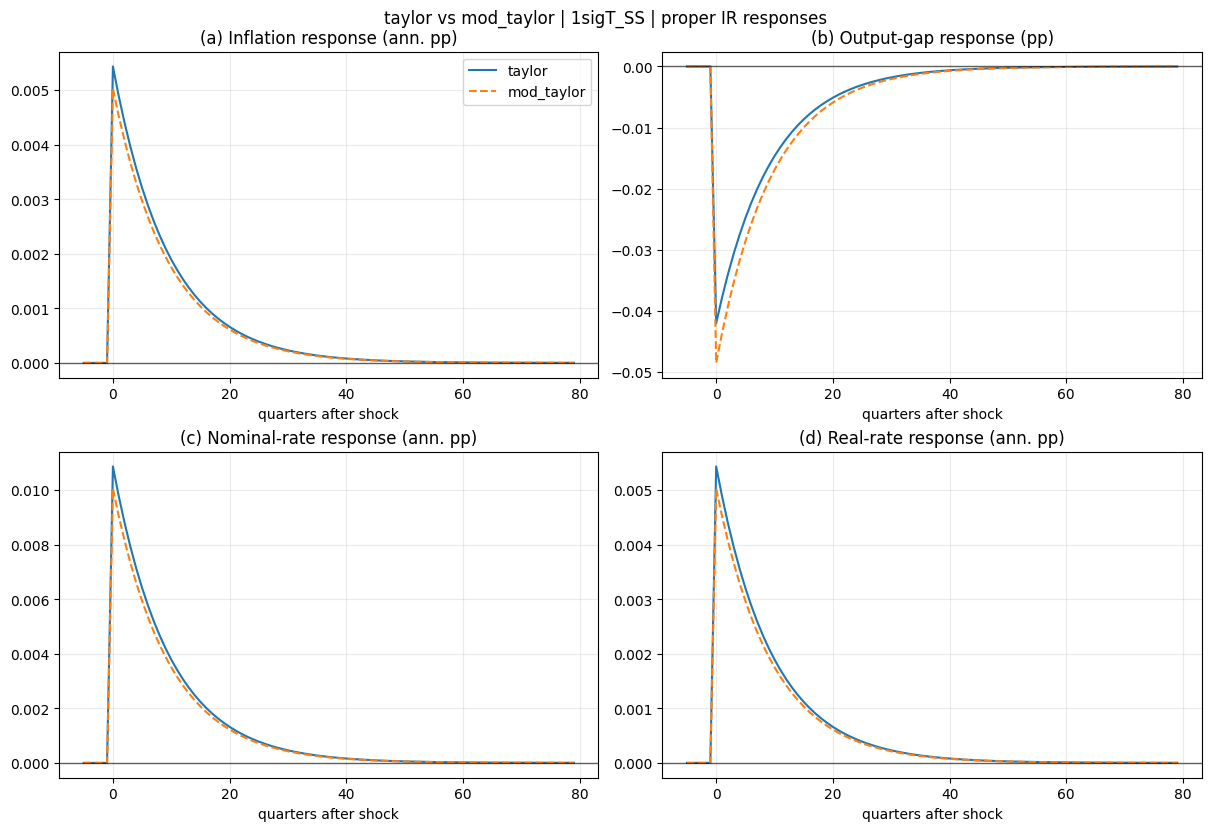

taylor/mod_taylor max abs (pi,x,i,r): 0.005433620851658105 0.042064328382646066 0.01086724170331621 0.005433620851658105 | 0.0050287640785739995 0.048545349550287165 0.010057528157147999 0.0050287640785739995


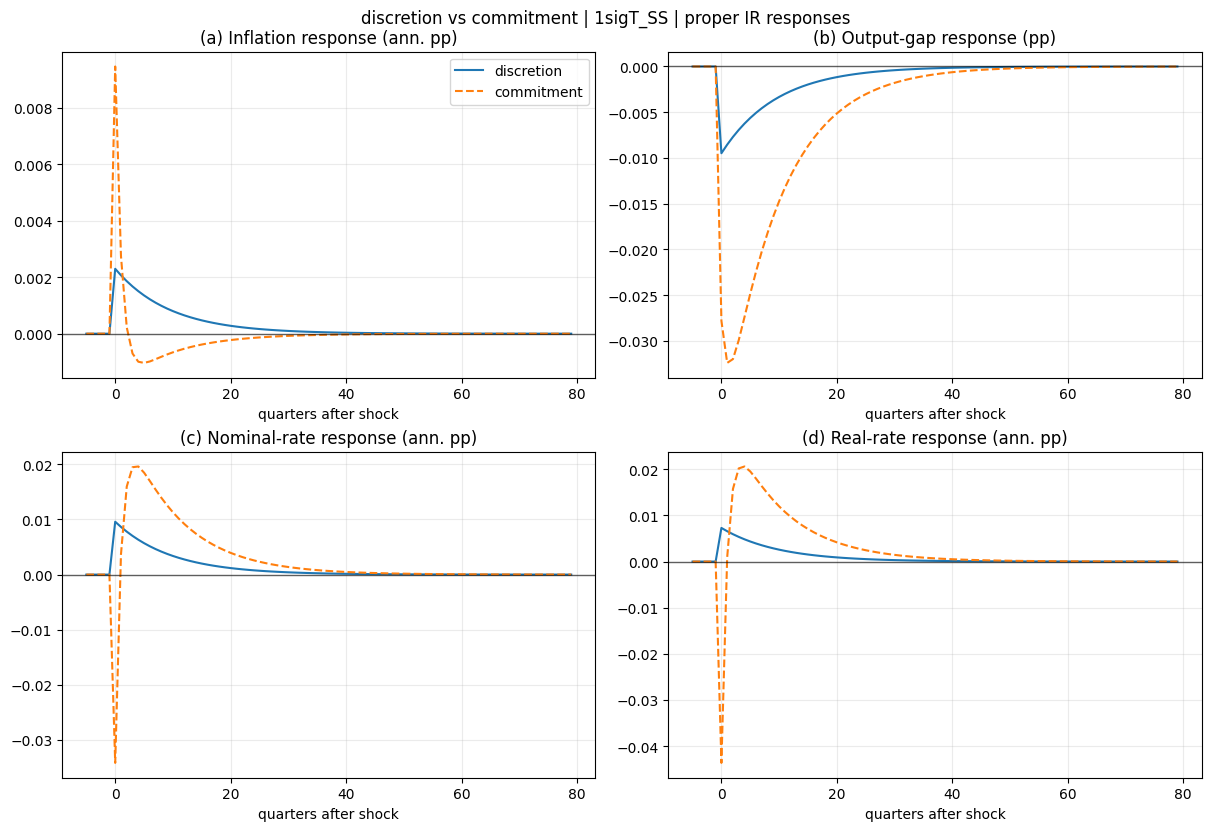

discretion/commitment max abs (pi,x,i,r): 0.0022978743120738443 0.009481235030955881 0.009577247965086855 0.00727937365301301 | 0.009462825093109473 0.032393593562086986 0.03412271230711639 0.04358553740022586


In [84]:
# Cell X2: EXACT 116-style pair plot, но именно IR response (1sigT_SS)
# Пары: Taylor vs Mod Taylor, Discretion vs Commitment
pairs = [("taylor", "mod_taylor"), ("discretion", "commitment")]
label = "1sigT_SS"   # как в Figure 7 (start=SS)

for p1, p2 in pairs:
    f1, f2 = ir_npz(p1), ir_npz(p2)
    if f1 is None or f2 is None:
        print(f"[skip] missing IR file for {p1}/{p2}")
        continue

    d1 = load_ir_label(f1, label)
    d2 = load_ir_label(f2, label)
    if d1 is None or d2 is None:
        print(f"[skip] missing {label} for {p1}/{p2}")
        continue

    T = min(len(d1["pi_tot_y"]), len(d2["pi_tot_y"]), PRE + H)
    t = np.arange(-PRE, -PRE + T)

    pi1 = ann(dev(d1["pi_tot_y"][:T], PRE))
    pi2 = ann(dev(d2["pi_tot_y"][:T], PRE))
    x1  = 100.0*dev(d1["out_gap_y"][:T], PRE)
    x2  = 100.0*dev(d2["out_gap_y"][:T], PRE)
    i1  = ann(dev(d1["i_nom_y"][:T], PRE))
    i2  = ann(dev(d2["i_nom_y"][:T], PRE))
    r1  = ann(dev(d1["r_real_y"][:T], PRE))
    r2  = ann(dev(d2["r_real_y"][:T], PRE))

    fig, ax = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

    ax[0,0].plot(t, pi1, label=p1)
    ax[0,0].plot(t, pi2, "--", label=p2)
    ax[0,0].set_title("(a) Inflation response (ann. pp)")

    ax[0,1].plot(t, x1, label=p1)
    ax[0,1].plot(t, x2, "--", label=p2)
    ax[0,1].set_title("(b) Output-gap response (pp)")

    ax[1,0].plot(t, i1, label=p1)
    ax[1,0].plot(t, i2, "--", label=p2)
    ax[1,0].set_title("(c) Nominal-rate response (ann. pp)")

    ax[1,1].plot(t, r1, label=p1)
    ax[1,1].plot(t, r2, "--", label=p2)
    ax[1,1].set_title("(d) Real-rate response (ann. pp)")

    for a in ax.ravel():
        a.axhline(0, color="k", lw=1, alpha=0.6)
        a.set_xlabel("quarters after shock")
        a.grid(alpha=0.25)

    ax[0,0].legend()
    fig.suptitle(f"{p1} vs {p2} | {label} | proper IR responses", y=1.02)
    plt.show()

    print(f"{p1}/{p2} max abs (pi,x,i,r):",
          np.max(np.abs(pi1)), np.max(np.abs(x1)), np.max(np.abs(i1)), np.max(np.abs(r1)),
          "|",
          np.max(np.abs(pi2)), np.max(np.abs(x2)), np.max(np.abs(i2)), np.max(np.abs(r2)))


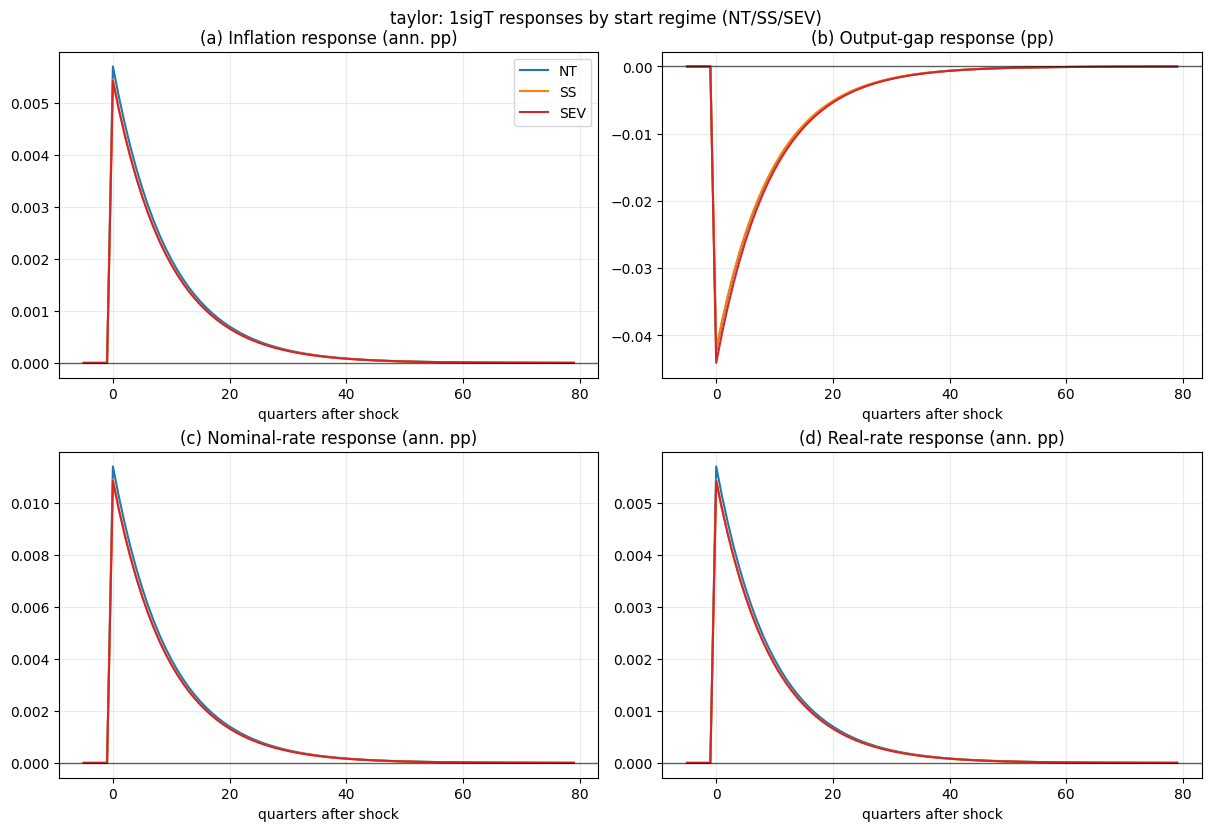

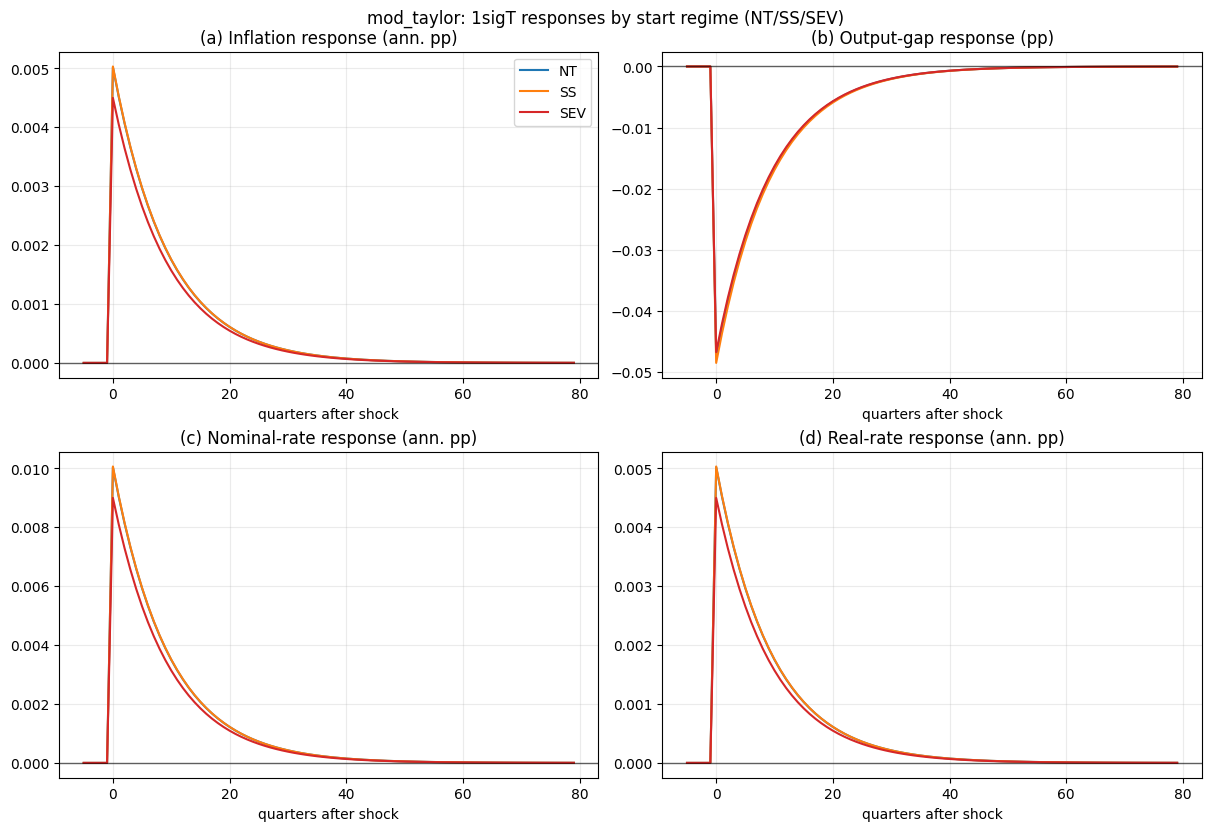

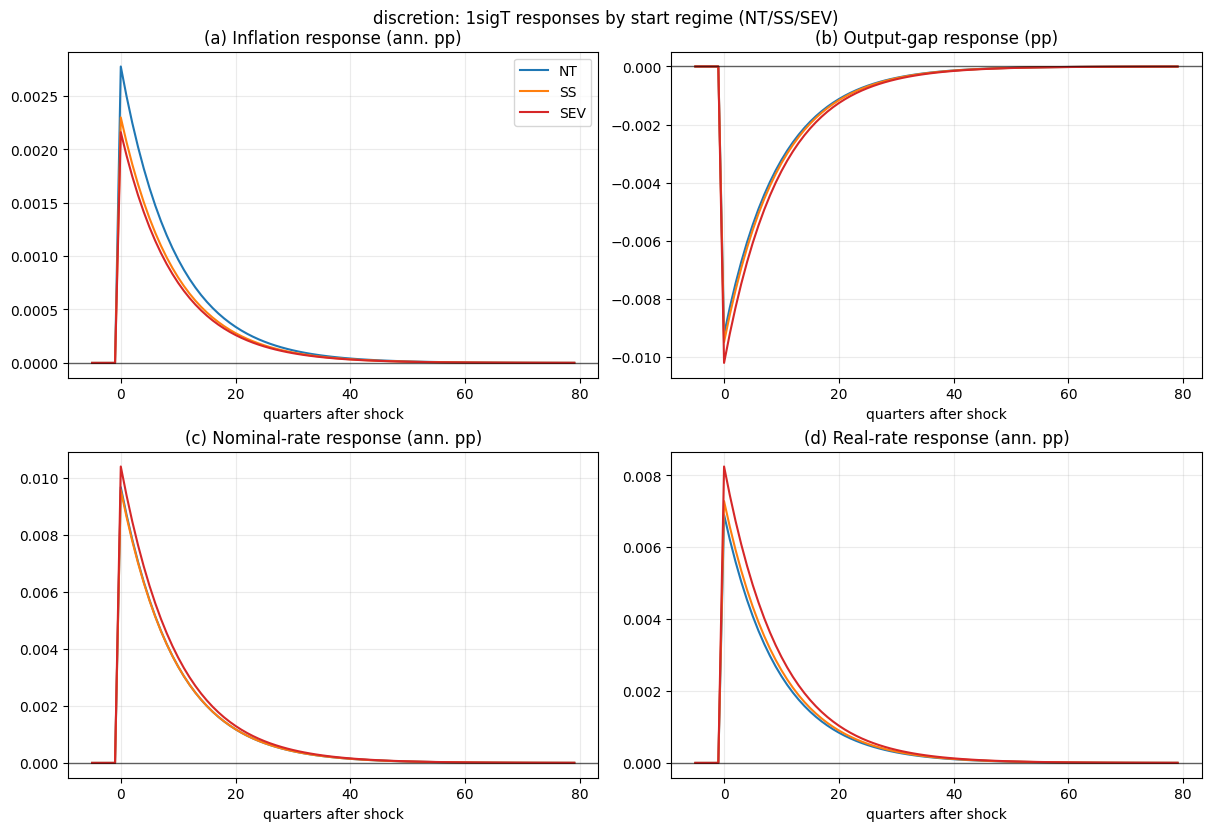

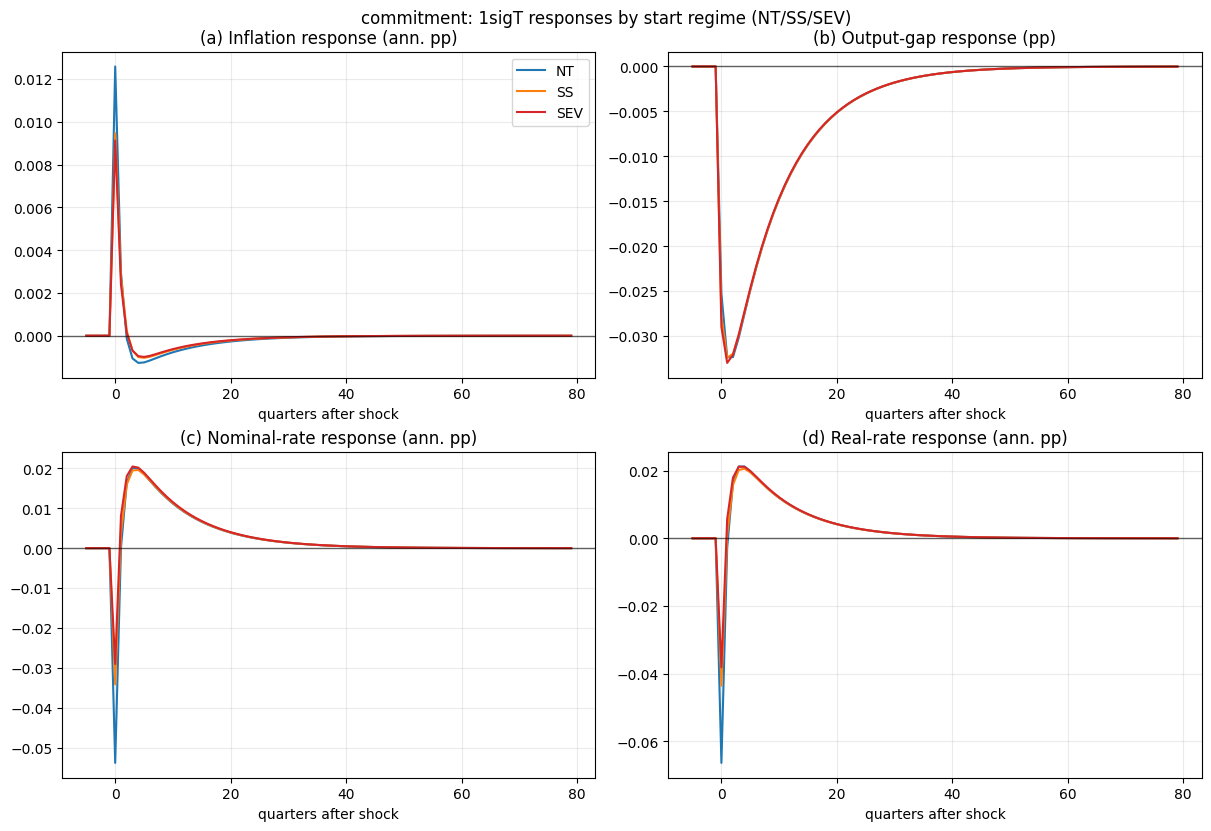

In [85]:
# Cell X3: по стартам NT/SS/SEV для КАЖДОЙ модели (тоже IR responses)
policies = ["taylor", "mod_taylor", "discretion", "commitment"]
tags = ["NT", "SS", "SEV"]
colors = {"NT":"tab:blue", "SS":"tab:orange", "SEV":"tab:red"}

for pol in policies:
    f = ir_npz(pol)
    if f is None:
        print(f"[skip] {pol}: no IR file")
        continue

    curves = {tag: load_ir_label(f, f"1sigT_{tag}") for tag in tags}
    valid = [tag for tag in tags if curves[tag] is not None]
    if not valid:
        print(f"[skip] {pol}: no 1sigT_NT/SS/SEV labels")
        continue

    T = min([len(curves[tag]["pi_tot_y"]) for tag in valid] + [PRE + H])
    t = np.arange(-PRE, -PRE + T)

    fig, ax = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
    for tag in valid:
        d = curves[tag]
        col = colors[tag]
        ax[0,0].plot(t, ann(dev(d["pi_tot_y"][:T], PRE)), color=col, label=tag)
        ax[0,1].plot(t, 100.0*dev(d["out_gap_y"][:T], PRE), color=col, label=tag)
        ax[1,0].plot(t, ann(dev(d["i_nom_y"][:T], PRE)), color=col, label=tag)
        ax[1,1].plot(t, ann(dev(d["r_real_y"][:T], PRE)), color=col, label=tag)

    ax[0,0].set_title("(a) Inflation response (ann. pp)")
    ax[0,1].set_title("(b) Output-gap response (pp)")
    ax[1,0].set_title("(c) Nominal-rate response (ann. pp)")
    ax[1,1].set_title("(d) Real-rate response (ann. pp)")
    for a in ax.ravel():
        a.axhline(0, color="k", lw=1, alpha=0.6)
        a.set_xlabel("quarters after shock")
        a.grid(alpha=0.25)
    ax[0,0].legend()
    fig.suptitle(f"{pol}: 1sigT responses by start regime (NT/SS/SEV)", y=1.02)
    plt.show()
